<a href="https://colab.research.google.com/github/tousifo/ml_notebooks/blob/main/MVQAN_MR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVQAN Final Colab Implementation: Exact Advisor 3-Dataset ALS/BCI Experiment

This notebook is configured for the exact advisor-requested dataset scope:

1. **BNCI-P300** loaded through MOABB when available.
2. **UCL ALS-EEG** from UCL Research Data Repository / Figshare article `28156016`.
3. **EEGET-ALS** from Kaggle dataset `patrickiitmz/eeget-als-dataset`.

The experiment is designed for small-sample ALS/BCI decoding with patient/subject-level LOSO evaluation, parameter-efficiency reporting, overfitting-gap analysis, MVQAN ablations, and paper-quality PDF figures.

Important: Kaggle public-dataset download may require a Kaggle token in Colab. If KaggleHub downloads the dataset without credentials, no token is needed; otherwise upload `kaggle.json` as instructed in the dataset-loading cell.


# 1. Install required packages

This cell installs the packages needed for EEG loading, classical BCI baselines, quantum neural networks, and visualization.

Runtime notes:
- Use **GPU runtime** in Colab if available.
- Quantum simulation is still CPU-heavy, so start with `RUN_MODE = "quick"` and later switch to `RUN_MODE = "paper"`.

In [ ]:
!pip -q install moabb mne pyriemann pennylane scikit-learn seaborn umap-learn pandas numpy scipy tqdm kaggle kagglehub h5py mat73 requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.7/837.7 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.6/153.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.8/189.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0

# 2. Imports and global configuration

The configuration is intentionally centralized. For a fast smoke test, keep `RUN_MODE="quick"`. For paper-style runs, switch it to `"paper"` and increase the number of subjects/seeds/epochs.

In [ ]:
import os, gc, math, random, warnings, time, json, re
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import scipy.signal as sps
from scipy.linalg import eigh

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, roc_auc_score, average_precision_score,
    accuracy_score, confusion_matrix
)
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm.auto import tqdm

import pennylane as qml

warnings.filterwarnings("ignore")

@dataclass
class CFG:
    # ---------------- RUN CONTROL ----------------
    RUN_MODE: str = "quick"
    SEED: int = 42

    # ---------------- DATASET ----------------
    DATASET_CANDIDATES: Tuple[str, ...] = (
        "BNCI2014_009", "BNCI2014_008", "bi2013a", "BI2013a", "bi2012", "BrainInvaders2013a"
    )

    FMIN: float = 0.1
    FMAX: float = 30.0
    TMIN: float = 0.0
    TMAX: float = 0.8
    RESAMPLE: int = 128

    MAX_SUBJECTS_QUICK: int = 6
    MAX_SUBJECTS_TUNE: Optional[int] = 12
    MAX_SUBJECTS_PAPER: Optional[int] = None
    MAX_OUTER_FOLDS_QUICK: int = 3
    MAX_OUTER_FOLDS_TUNE: int = 5
    # GENUINE FIX 1: Cap folds to 5. 10 folds takes twice as long for minimal paper benefit.
    MAX_OUTER_FOLDS_PAPER: Optional[int] = 5

    # ---------------- TRAINING ----------------
    EPOCHS_QUICK: int = 12
    EPOCHS_TUNE: int = 30
    # GENUINE FIX 2: 40 epochs is plenty for 4 qubits. 80 just drags out the plateau.
    EPOCHS_PAPER: int = 40
    PATIENCE_QUICK: int = 4
    PATIENCE_TUNE: int = 8
    PATIENCE_PAPER: int = 12

    BATCH_SIZE: int = 64
    BATCH_SIZE_CPU: int = 32
    BATCH_SIZE_GPU: int = 128
    AUTO_BATCH_BY_DEVICE: bool = True

    TORCH_NUM_THREADS_CPU: int = 4

    FORCE_QML_CPU: bool = True
    QML_BATCH_SIZE_CPU: int = 32
    LR: float = 1e-3
    WEIGHT_DECAY: float = 1e-4

    USE_BALANCED_SAMPLER: bool = True
    LOSS_TYPE: str = "focal"
    FOCAL_GAMMA: float = 2.0
    TARGET_CLASS_WEIGHT_MULTIPLIER: float = 1.25
    TUNE_THRESHOLD: bool = True

    # ---------------- MVQAN DESIGN ----------------
    N_QUBITS_QUICK: int = 4
    N_QUBITS_TUNE: int = 4
    N_QUBITS_PAPER: int = 6

    VQC_DEPTH_QUICK: int = 1
    VQC_DEPTH_TUNE: int = 2
    VQC_DEPTH_PAPER: int = 2

    QUANTUM_ENCODING: str = "RY_RZ"
    ENTANGLEMENT: str = "ring"

    DROPOUT: float = 0.20
    ATTENTION_TEMPERATURE: float = 0.75

    USE_CLASSICAL_RESIDUAL: bool = True
    RESIDUAL_DIM: int = 16

    ENABLE_VIEW_PCA_CAP: bool = True
    VIEW_PCA_DIM_QUICK: int = 16
    VIEW_PCA_DIM_TUNE: int = 24
    VIEW_PCA_DIM_PAPER: int = 32
    ADD_SUPERVISED_SPATIAL_VIEW: bool = True
    SUPERVISED_VIEW_PCA_DIM: int = 16
    RUN_COMPACT_MVQAN: bool = True
    COMPACT_N_QUBITS: int = 4
    COMPACT_VQC_DEPTH: int = 1
    COMPACT_RESIDUAL_DIM: int = 4
    COMPACT_DROPOUT: float = 0.25
    USE_BALANCED_SUBJECT_FOLDS: bool = True
    STRICT_BINARY_TEST_FOLDS: bool = True
    MIN_TEST_PER_CLASS: int = 5
    MIN_VAL_PER_CLASS: int = 2

    # GENUINE FIX 4: Add "p300" to this list. This forces the loader to downsample the 11,520 negative trials
    # to match the 2,304 positive trials. That's a 66% instant reduction in math overhead per epoch.
    BALANCE_TRAIN_INDICES_FOR_TASKS: Tuple[str, ...] = ("als_control", "p300")
    MAX_TRAIN_CLASS_RATIO: float = 1.0

    ALIGNMENT: str = "coral"
    ALIGN_LAMBDA: float = 0.005
    CLASS_SEPARATION_LAMBDA: float = 0.015
    CLASS_MARGIN: float = 0.75
    MMD_SIGMAS: Tuple[float, ...] = (0.5, 1.0, 2.0, 4.0)

    RUN_SKLEARN_BASELINES: bool = True
    RUN_EEGNET_BASELINE: bool = True
    RUN_QML_BASELINES: bool = True
    RUN_MVQAN: bool = True

    RESULTS_DIR: str = "mvqan_results"
    SAVE_PDF_FIGURES: bool = True
    PAPER_DPI: int = 300
    MAIN_MODEL_NAME: str = "MVQAN_CORAL"

cfg = CFG()

if not torch.cuda.is_available():
    try:
        torch.set_num_threads(cfg.TORCH_NUM_THREADS_CPU)
    except Exception:
        pass

if cfg.RUN_MODE == "quick":
    cfg.MAX_SUBJECTS = cfg.MAX_SUBJECTS_QUICK
    cfg.MAX_OUTER_FOLDS = cfg.MAX_OUTER_FOLDS_QUICK
    cfg.EPOCHS = cfg.EPOCHS_QUICK
    cfg.PATIENCE = cfg.PATIENCE_QUICK
    cfg.VQC_DEPTH = cfg.VQC_DEPTH_QUICK
    cfg.N_QUBITS = cfg.N_QUBITS_QUICK
    cfg.VIEW_PCA_DIM = cfg.VIEW_PCA_DIM_QUICK
    cfg.SEEDS = (cfg.SEED,)
elif cfg.RUN_MODE == "tune":
    cfg.MAX_SUBJECTS = cfg.MAX_SUBJECTS_TUNE
    cfg.MAX_OUTER_FOLDS = cfg.MAX_OUTER_FOLDS_TUNE
    cfg.EPOCHS = cfg.EPOCHS_TUNE
    cfg.PATIENCE = cfg.PATIENCE_TUNE
    cfg.VQC_DEPTH = cfg.VQC_DEPTH_TUNE
    cfg.N_QUBITS = cfg.N_QUBITS_TUNE
    cfg.VIEW_PCA_DIM = cfg.VIEW_PCA_DIM_TUNE
    cfg.SEEDS = (11, 22)
else:
    cfg.MAX_SUBJECTS = cfg.MAX_SUBJECTS_PAPER
    cfg.MAX_OUTER_FOLDS = cfg.MAX_OUTER_FOLDS_PAPER
    cfg.EPOCHS = cfg.EPOCHS_PAPER
    cfg.PATIENCE = cfg.PATIENCE_PAPER
    cfg.VQC_DEPTH = cfg.VQC_DEPTH_PAPER
    cfg.N_QUBITS = cfg.N_QUBITS_PAPER
    cfg.VIEW_PCA_DIM = cfg.VIEW_PCA_DIM_PAPER
    cfg.SEEDS = (11, 22, 33)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if cfg.AUTO_BATCH_BY_DEVICE:
    cfg.BATCH_SIZE = cfg.BATCH_SIZE_GPU if DEVICE == "cuda" else cfg.BATCH_SIZE_CPU
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)

print("Global PyTorch device:", DEVICE)
print("Quantum/PennyLane models forced to CPU:", cfg.FORCE_QML_CPU)
print("Batch size:", cfg.BATCH_SIZE, "| QML CPU batch size:", cfg.QML_BATCH_SIZE_CPU)
print(json.dumps(asdict(cfg), indent=2, default=str))

Global PyTorch device: cpu
Quantum/PennyLane models forced to CPU: True
Batch size: 32 | QML CPU batch size: 32
{
  "RUN_MODE": "quick",
  "SEED": 42,
  "DATASET_CANDIDATES": [
    "BNCI2014_009",
    "BNCI2014_008",
    "bi2013a",
    "BI2013a",
    "bi2012",
    "BrainInvaders2013a"
  ],
  "FMIN": 0.1,
  "FMAX": 30.0,
  "TMIN": 0.0,
  "TMAX": 0.8,
  "RESAMPLE": 128,
  "MAX_SUBJECTS_QUICK": 6,
  "MAX_SUBJECTS_TUNE": 12,
  "MAX_SUBJECTS_PAPER": null,
  "MAX_OUTER_FOLDS_QUICK": 3,
  "MAX_OUTER_FOLDS_TUNE": 5,
  "MAX_OUTER_FOLDS_PAPER": 5,
  "EPOCHS_QUICK": 12,
  "EPOCHS_TUNE": 30,
  "EPOCHS_PAPER": 40,
  "PATIENCE_QUICK": 4,
  "PATIENCE_TUNE": 8,
  "PATIENCE_PAPER": 12,
  "BATCH_SIZE": 32,
  "BATCH_SIZE_CPU": 32,
  "BATCH_SIZE_GPU": 128,
  "AUTO_BATCH_BY_DEVICE": true,
  "TORCH_NUM_THREADS_CPU": 4,
  "FORCE_QML_CPU": true,
  "QML_BATCH_SIZE_CPU": 32,
  "LR": 0.001,
  "WEIGHT_DECAY": 0.0001,
  "USE_BALANCED_SAMPLER": true,
  "LOSS_TYPE": "focal",
  "FOCAL_GAMMA": 2.0,
  "TARGET_CLASS_WEI

# 2A. Exact advisor dataset registry

Your advisor asked us to prioritize exactly three datasets for the current submission:

1. **BNCI-P300**
2. **UCL ALS-EEG**
3. **EEGET-ALS**

This cell now uses the public links you provided:

- UCL ALS-EEG: `https://rdr.ucl.ac.uk/articles/dataset/Longitudinal_ALS_EEG_Dataset_for_Motor_Imagery_Studies/28156016`
- EEGET-ALS Kaggle: `https://www.kaggle.com/datasets/patrickiitmz/eeget-als-dataset`

The UCL dataset is a motor-imagery ALS dataset. The default task uses **left-vs-right motor imagery** and excludes rest trials so that all three datasets can be evaluated with a consistent binary macro-F1/ROC-AUC/PR-AUC protocol. If you later want a 3-class UCL experiment including rest, the model/metric cells need to be switched to multiclass mode.


In [ ]:
# ---------------- Exact advisor dataset mode ----------------
# This notebook uses the exact three datasets requested by the advisor.
DATASET_MODE = "advisor_exact"
REQUIRE_ALL_ADVISOR_DATASETS = True
ALLOW_NON_ALS_FALLBACK = False

# UCL/Figshare article information.
# Human-readable page:
# https://rdr.ucl.ac.uk/articles/dataset/Longitudinal_ALS_EEG_Dataset_for_Motor_Imagery_Studies/28156016
UCL_ALS_FIGSHARE_ARTICLE_ID = "28156016"
UCL_ALS_FIGSHARE_DOWNLOAD_URL = "https://rdr.ucl.ac.uk/ndownloader/articles/28156016/versions/1"

# Kaggle slug from the provided URL:
# https://www.kaggle.com/datasets/patrickiitmz/eeget-als-dataset
EEGET_ALS_KAGGLE_SLUG = "patrickiitmz/eeget-als-dataset"

# EEGET has a nested subject/time/scenario folder structure. The fixed loader infers subject and label
# from the folder path and uses EEG-like CSVs first. If no EEG-like CSV is found, it can use ET.csv as
# a runnable fallback, but this fallback must be reported as eye-tracking/multimodal, not EEG-only.
EEGET_ALLOW_ET_FALLBACK = True      # set False for strict EEG-only final run
EEGET_WINDOW_SECONDS = 2.0
EEGET_STRIDE_SECONDS = 2.0
EEGET_MAX_WINDOWS_PER_SUBJECT = 160 # keeps runtime manageable; fold-level balancing fixes class imbalance

ADVISOR_DATASETS = [
    {
        "name": "BNCI-P300",
        "task_type": "p300",
        "source_type": "moabb",
        "moabb_candidates": (
            "BNCI2014_009", "BNCI2014_008", "BNCI2015_003", "EPFLP300",
            "BI2012", "BI2013a", "BI2013b", "BrainInvaders2013"
        ),
        "include_keywords": ("bnci", "p300", "epfl"),
        "description": "Advisor-prioritized BNCI/clinical P300 dataset loaded through MOABB when available.",
    },
    {
        "name": "UCL-ALS-EEG",
        "task_type": "mi",
        "source_type": "ucl_figshare_als_mi",
        "figshare_article_id": UCL_ALS_FIGSHARE_ARTICLE_ID,
        "direct_url": UCL_ALS_FIGSHARE_DOWNLOAD_URL,
        "mi_task": "left_right",  # L vs R; excludes Re/rest for binary MI classification
        "sfreq": 128,             # fallback only; exact metadata is used if the MAT exposes it
        "subject_grouping": "file_patient",  # critical: group all L/R trials from one patient file as one subject
        "description": "Longitudinal ALS EEG motor-imagery dataset; left-vs-right MI binary task by default.",
    },
    {
        "name": "EEGET-ALS",
        "task_type": "als_control",  # path-inferred ALS vs non-ALS subject classification
        "source_type": "kaggle_or_url_or_local",
        "kaggle_slug": EEGET_ALS_KAGGLE_SLUG,
        "direct_url": "",
        "local_path": "",
        "auto_make_binary": True,
        "allow_et_fallback": EEGET_ALLOW_ET_FALLBACK,
        "window_seconds": EEGET_WINDOW_SECONDS,
        "stride_seconds": EEGET_STRIDE_SECONDS,
        "max_windows_per_subject": EEGET_MAX_WINDOWS_PER_SUBJECT,
        "sfreq": 128,
        "description": "Kaggle EEGET-ALS. Loader infers subject/ALS-control label from folders and windows EEG-like CSVs; ET fallback is explicit if used.",
    },
]

print(f"DATASET_MODE = {DATASET_MODE}")
print("Datasets scheduled for loading:")
for d in ADVISOR_DATASETS:
    print(" -", d["name"], "|", d["source_type"], "|", d.get("description", ""))


DATASET_MODE = advisor_exact
Datasets scheduled for loading:
 - BNCI-P300 | moabb | Advisor-prioritized BNCI/clinical P300 dataset loaded through MOABB when available.
 - UCL-ALS-EEG | ucl_figshare_als_mi | Longitudinal ALS EEG motor-imagery dataset; left-vs-right MI binary task by default.
 - EEGET-ALS | kaggle_or_url_or_local | Kaggle EEGET-ALS. Loader infers subject/ALS-control label from folders and windows EEG-like CSVs; ET fallback is explicit if used.


# 3. Reproducibility utilities

The following function fixes random seeds for NumPy, Python, and PyTorch. Exact determinism is difficult with GPU kernels, but this makes runs much more stable.

In [ ]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(cfg.SEED)

# 4. Load an online public P300 dataset using MOABB

This loader returns:

```python
X        : [n_trials, n_channels, n_times]
y        : [n_trials] binary labels, 1 = target/P300, 0 = non-target
subjects : [n_trials] subject IDs for LOSO
sfreq    : sampling frequency after MOABB resampling
```

The loader tries multiple MOABB P300 datasets, so it is robust to minor MOABB version differences.

In [ ]:
def label_to_binary(labels):
    """Robustly map P300/ERP labels to 0/1. Positive class is Target/P300 if detectable; otherwise minority class."""
    labels_arr = np.asarray(labels)
    labels_str = labels_arr.astype(str)
    low = np.char.lower(labels_str)
    is_target = np.array([
        ("target" in s and "non" not in s) or (s in ["1", "true", "p300", "positive", "target"])
        for s in low
    ])
    if is_target.sum() > 0 and is_target.sum() < len(is_target):
        return is_target.astype(np.int64)
    vals, counts = np.unique(labels_str, return_counts=True)
    pos_val = vals[np.argmin(counts)]
    print(f"[label_to_binary] Could not infer Target/P300. Using minority label as positive: {pos_val}")
    return (labels_str == pos_val).astype(np.int64)


def normalize_label_ids(y):
    """Map arbitrary labels to 0..K-1."""
    vals = sorted(np.unique(y).tolist())
    mapping = {v: i for i, v in enumerate(vals)}
    return np.asarray([mapping[v] for v in y], dtype=np.int64), mapping


def ensure_trial_tensor(X):
    """Ensure EEG/features tensor has shape [N, C, T]."""
    X = np.asarray(X, dtype=np.float32)
    if X.ndim == 2:
        X = X[:, None, :]  # feature-table fallback: channels=1, time/features=T
    if X.ndim != 3:
        raise ValueError(f"Expected X with 2 or 3 dims; got shape {X.shape}")
    return X


USED_MOABB_CLASSES = set()


def _dataset_matches_keywords(name, ds, include_keywords=None):
    """Heuristic scanner for public-auto mode only. It helps select different public P300 datasets."""
    if not include_keywords:
        return True
    text_parts = [name]
    for attr in ["code", "paradigm", "doi", "event_id"]:
        try:
            text_parts.append(str(getattr(ds, attr, "")))
        except Exception:
            pass
    text = " ".join(text_parts).lower()
    return any(k.lower() in text for k in include_keywords)


def _is_p300_like_dataset(ds):
    event_id = getattr(ds, "event_id", {}) or {}
    keys = " ".join([str(k).lower() for k in event_id.keys()])
    vals = " ".join([str(v).lower() for v in event_id.values()])
    paradigm = str(getattr(ds, "paradigm", "")).lower()
    return (("target" in keys and "non" in keys) or ("p300" in keys) or ("p300" in paradigm) or ("target" in vals))


def instantiate_moabb_dataset(spec):
    """Instantiate a MOABB dataset from explicit candidates; in public_auto mode scan for P300-like alternatives.

    This function avoids reusing the same MOABB class for multiple public-auto datasets.
    """
    import inspect
    import moabb.datasets as mds
    candidates = spec.get("moabb_candidates", cfg.DATASET_CANDIDATES)
    include_keywords = spec.get("include_keywords", None)
    last_error = None

    # 1) Try explicit candidates in order.
    for name in candidates:
        if name in USED_MOABB_CLASSES:
            continue
        if hasattr(mds, name):
            cls = getattr(mds, name)
            try:
                ds = cls()
                if _is_p300_like_dataset(ds) or spec.get("task_type") != "p300":
                    USED_MOABB_CLASSES.add(name)
                    print(f"Using MOABB dataset class for {spec['name']}: {name}")
                    return name, ds
            except Exception as e:
                last_error = e
                print(f"Candidate {name} exists but failed to instantiate: {repr(e)}")

    # 2) Public-auto fallback scan. This is intentionally disabled in exact ALS mode.
    if ALLOW_NON_ALS_FALLBACK:
        print(f"Explicit candidates failed for {spec['name']}. Scanning MOABB for a distinct P300-like public dataset...")
        scored = []
        for name in dir(mds):
            if name.startswith("_") or name in USED_MOABB_CLASSES:
                continue
            obj = getattr(mds, name)
            if not inspect.isclass(obj):
                continue
            try:
                ds = obj()
                if not _is_p300_like_dataset(ds):
                    continue
                if not _dataset_matches_keywords(name, ds, include_keywords):
                    # keep as lower priority if no keyword match
                    score = 1
                else:
                    score = 0
                nsub = len(getattr(ds, "subject_list", []) or [])
                scored.append((score, -nsub, name, ds))
            except Exception:
                continue
        if scored:
            scored.sort(key=lambda x: (x[0], x[1], x[2]))
            _, _, name, ds = scored[0]
            USED_MOABB_CLASSES.add(name)
            print(f"Using scanned public P300 dataset for {spec['name']}: {name}; event_id={getattr(ds, 'event_id', {})}")
            return name, ds

    available = [n for n in dir(mds) if not n.startswith("_")]
    raise RuntimeError(
        f"Could not instantiate MOABB dataset for {spec['name']}. "
        f"Tried: {candidates}. Last error: {last_error}. "
        f"Available moabb.datasets symbols include: {available[:120]}"
    )


def make_p300_paradigm(cfg):
    from moabb.paradigms import P300
    attempts = [
        dict(fmin=cfg.FMIN, fmax=cfg.FMAX, tmin=cfg.TMIN, tmax=cfg.TMAX, resample=cfg.RESAMPLE),
        dict(fmin=cfg.FMIN, fmax=cfg.FMAX, tmin=cfg.TMIN, tmax=cfg.TMAX),
        dict(resample=cfg.RESAMPLE),
        dict(),
    ]
    last_error = None
    for kwargs in attempts:
        try:
            print("Trying P300 paradigm kwargs:", kwargs)
            return P300(**kwargs)
        except Exception as e:
            last_error = e
    raise RuntimeError(f"Could not create MOABB P300 paradigm. Last error: {repr(last_error)}")


def load_moabb_p300_dataset(spec, cfg):
    import moabb
    moabb.set_log_level("WARNING")
    candidates = spec.get("moabb_candidates", cfg.DATASET_CANDIDATES)
    name, dataset = instantiate_moabb_dataset(spec)
    paradigm = make_p300_paradigm(cfg)
    subjects = list(getattr(dataset, "subject_list", []))
    if len(subjects) == 0:
        raise RuntimeError("Dataset has empty subject_list.")
    if cfg.MAX_SUBJECTS is not None:
        subjects = subjects[:cfg.MAX_SUBJECTS]
    print(f"Loading {spec['name']} via MOABB class {name}; subjects: {subjects}")
    X, labels, metadata = paradigm.get_data(dataset=dataset, subjects=subjects)
    y = label_to_binary(labels)
    subjects_arr = metadata["subject"].values if "subject" in metadata.columns else np.repeat(subjects, len(y)//len(subjects))
    X = ensure_trial_tensor(X)
    duration = max(cfg.TMAX - cfg.TMIN, 1e-6)
    sfreq = getattr(paradigm, "resample", None) or cfg.RESAMPLE or int(round(X.shape[-1] / duration))
    return {
        "name": spec["name"],
        "source_name": name,
        "task_type": spec.get("task_type", "p300"),
        "X": X.astype(np.float32),
        "y": np.asarray(y, dtype=np.int64),
        "subjects": np.asarray(subjects_arr),
        "sfreq": int(sfreq),
        "meta": {"moabb_class": name, "description": spec.get("description", "")},
    }


def _download_direct_url(url, out_dir, preferred_name="downloaded_dataset.zip"):
    """Download a direct URL and extract it when it is an archive.

    Figshare/UCL ndownloader URLs often end with `/versions/1`, so the URL basename has no
    useful extension. We therefore save those responses as a ZIP by default and extract them.
    """
    import zipfile, tarfile, shutil, requests
    os.makedirs(out_dir, exist_ok=True)
    basename = os.path.basename(url.split("?")[0]).strip()
    if not basename or "." not in basename or basename.isdigit():
        basename = preferred_name
    local = os.path.join(out_dir, basename)
    if not os.path.exists(local):
        print("Downloading:", url)
        with requests.get(url, stream=True, allow_redirects=True, timeout=120) as r:
            r.raise_for_status()
            with open(local, "wb") as f:
                for chunk in r.iter_content(chunk_size=1024*1024):
                    if chunk:
                        f.write(chunk)
    else:
        print("Using existing download:", local)

    # Try archive extraction. If not an archive, leave the file in place.
    try:
        if zipfile.is_zipfile(local):
            with zipfile.ZipFile(local, 'r') as zf:
                zf.extractall(out_dir)
        elif local.endswith(('.tar.gz', '.tgz', '.tar')):
            with tarfile.open(local, 'r:*') as tf:
                tf.extractall(out_dir)
    except Exception as e:
        print("Archive extraction warning:", repr(e))
    return out_dir


def _download_kaggle(slug, out_dir):
    """Download a Kaggle dataset.

    First tries kagglehub, which is convenient in Colab for public datasets. If that fails,
    it falls back to the Kaggle CLI, which requires ~/.kaggle/kaggle.json or env vars.
    """
    import subprocess, os, zipfile, glob, shutil
    os.makedirs(out_dir, exist_ok=True)

    # 1) KaggleHub path-first download.
    try:
        import kagglehub
        print("Trying KaggleHub download:", slug)
        kh_path = kagglehub.dataset_download(slug)
        print("KaggleHub dataset path:", kh_path)
        return kh_path
    except Exception as e:
        print("KaggleHub failed; falling back to Kaggle CLI:", repr(e))

    # 2) Kaggle CLI fallback.
    kaggle_json = os.path.expanduser("~/.kaggle/kaggle.json")
    if not os.path.exists(kaggle_json):
        if os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"):
            os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
            with open(kaggle_json, "w") as f:
                json.dump({"username": os.environ["KAGGLE_USERNAME"], "key": os.environ["KAGGLE_KEY"]}, f)
            os.chmod(kaggle_json, 0o600)
        else:
            raise RuntimeError(
                "Kaggle credentials not found. In Colab, upload kaggle.json to ~/.kaggle/ "
                "or set KAGGLE_USERNAME and KAGGLE_KEY. KaggleHub also failed."
            )
    cmd = ["kaggle", "datasets", "download", "-d", slug, "-p", out_dir, "--unzip"]
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)
    return out_dir


def _load_npz(path):
    data = np.load(path, allow_pickle=True)
    keys = set(data.files)
    def first(*names):
        for n in names:
            if n in keys:
                return data[n]
        return None
    X = first("X", "x", "data", "trials", "epochs")
    y = first("y", "labels", "label", "target", "targets")
    subjects = first("subjects", "subject", "subj", "patient", "patients", "s")
    sfreq = first("sfreq", "fs", "sampling_rate")
    if X is None or y is None:
        raise ValueError(f"NPZ {path} must contain X and y-like arrays. Keys={keys}")
    if subjects is None:
        raise ValueError(f"NPZ {path} must contain subject/patient IDs for LOSO. Keys={keys}")
    sfreq = int(np.asarray(sfreq).item()) if sfreq is not None else int(getattr(cfg, "RESAMPLE", 128))
    y, _ = normalize_label_ids(np.asarray(y).ravel())
    return ensure_trial_tensor(X), y, np.asarray(subjects).ravel(), sfreq


def _load_mat(path):
    import scipy.io
    try:
        mat = scipy.io.loadmat(path)
    except NotImplementedError:
        import mat73
        mat = mat73.loadmat(path)
    # flatten top-level keys only; robust enough for common exported datasets.
    candidates_X = ["X", "x", "data", "trials", "epochs", "EEG", "signals"]
    candidates_y = ["y", "labels", "label", "target", "targets", "class", "classes"]
    candidates_s = ["subjects", "subject", "subj", "patient", "patients", "s"]
    def find(cands):
        for k in cands:
            if k in mat:
                return mat[k]
        return None
    X = find(candidates_X); y = find(candidates_y); subjects = find(candidates_s)
    if X is None or y is None or subjects is None:
        raise ValueError(f"Could not auto-detect X/y/subjects in MAT {path}. Keys={list(mat.keys())[:50]}")
    X = ensure_trial_tensor(np.asarray(X))
    # Heuristic transpose if saved as C x T x N
    if X.shape[0] < X.shape[-1] and X.shape[0] < 256 and X.shape[-1] > 256:
        pass
    y, _ = normalize_label_ids(np.asarray(y).ravel())
    subjects = np.asarray(subjects).ravel()
    sfreq = int(np.asarray(mat.get("sfreq", mat.get("fs", cfg.RESAMPLE))).item()) if ("sfreq" in mat or "fs" in mat) else cfg.RESAMPLE
    return X, y, subjects, sfreq


def _load_csv(path):
    df = pd.read_csv(path)
    label_cols = [c for c in df.columns if c.lower() in ["y", "label", "labels", "target", "class"]]
    subj_cols = [c for c in df.columns if c.lower() in ["subject", "subjects", "subj", "patient", "patients", "s"]]
    if not label_cols or not subj_cols:
        raise ValueError(f"CSV {path} needs subject and label columns. Columns={df.columns.tolist()[:40]}")
    y_raw = df[label_cols[0]].values
    y, _ = normalize_label_ids(y_raw)
    subjects = df[subj_cols[0]].values
    feature_cols = [c for c in df.columns if c not in label_cols + subj_cols]
    X = df[feature_cols].values.astype(np.float32)
    return ensure_trial_tensor(X), y, subjects, cfg.RESAMPLE


def load_generic_folder(folder, spec, cfg):
    import glob
    if not folder or not os.path.exists(folder):
        raise FileNotFoundError(f"Folder/path does not exist: {folder}")
    if os.path.isfile(folder):
        files = [folder]
        base_folder = os.path.dirname(folder)
    else:
        files = []
        for ext in ["*.npz", "*.mat", "*.csv"]:
            files.extend(glob.glob(os.path.join(folder, "**", ext), recursive=True))
        base_folder = folder
    if not files:
        raise FileNotFoundError(
            f"No .npz/.mat/.csv files found in {folder}. "
            "For EDF/GDF/SET datasets, first convert to a standardized NPZ with X,y,subjects,sfreq."
        )
    # Prefer standardized NPZ if present.
    files = sorted(files, key=lambda p: (0 if p.endswith('.npz') else 1 if p.endswith('.mat') else 2, len(p)))
    last_err = None
    for path in files:
        try:
            print(f"Trying to load {spec['name']} from {path}")
            if path.endswith('.npz'):
                X, y, subjects, sfreq = _load_npz(path)
            elif path.endswith('.mat'):
                X, y, subjects, sfreq = _load_mat(path)
            elif path.endswith('.csv'):
                X, y, subjects, sfreq = _load_csv(path)
            else:
                continue
            if len(np.unique(subjects)) < 2:
                raise ValueError("Need at least two subjects/patients for LOSO.")
            return {"name": spec["name"], "source_name": path, "task_type": spec.get("task_type", "mi"),
                    "X": X.astype(np.float32), "y": y.astype(np.int64), "subjects": np.asarray(subjects),
                    "sfreq": int(sfreq), "meta": {"file": path, "description": spec.get("description", "")}}
        except Exception as e:
            last_err = e
            print("  failed:", repr(e))
    raise RuntimeError(f"Could not load {spec['name']} from {folder}. Last error: {last_err}")




def _get_struct_field(obj, name):
    """Get a MATLAB struct field from dict, scipy mat_struct, numpy void, or object."""
    if obj is None:
        return None
    if isinstance(obj, dict):
        return obj.get(name, None)
    if hasattr(obj, name):
        return getattr(obj, name)
    if isinstance(obj, np.void) and obj.dtype.names and name in obj.dtype.names:
        return obj[name]
    if isinstance(obj, np.ndarray) and obj.dtype.names and name in obj.dtype.names:
        return obj[name]
    return None


def _has_lrre_fields(obj):
    return (_get_struct_field(obj, "L") is not None) and (_get_struct_field(obj, "R") is not None) and (_get_struct_field(obj, "Re") is not None)


def _find_lrre_subject_structs(obj, max_depth=8):
    """Recursively find UCL subject structs containing fields L, R, and Re."""
    found, seen = [], set()
    def rec(x, depth):
        if depth > max_depth or x is None:
            return
        xid = id(x)
        if xid in seen:
            return
        seen.add(xid)
        if _has_lrre_fields(x):
            found.append(x)
            return
        if isinstance(x, dict):
            for k, v in x.items():
                if not str(k).startswith("__"):
                    rec(v, depth+1)
            return
        if isinstance(x, (list, tuple)):
            for v in x:
                rec(v, depth+1)
            return
        if isinstance(x, np.ndarray):
            if x.dtype == object or x.dtype.names is not None:
                for v in x.ravel():
                    rec(v, depth+1)
            return
    rec(obj, 0)
    return found


def _trial_matrix_to_channels_time(mat):
    arr = np.asarray(mat, dtype=np.float32).squeeze()
    if arr.ndim != 2:
        return None
    # UCL page says each trial matrix has rows=timestamps and columns=channels.
    if arr.shape[0] >= arr.shape[1]:
        arr = arr.T  # [channels, time]
    # Remove obviously empty rows/columns if any.
    if arr.shape[0] < 1 or arr.shape[1] < 2:
        return None
    return arr.astype(np.float32)


def _iter_trials_from_ucl_field(field):
    """Yield [channels, time] trial matrices from a MATLAB cell/object/numeric trial field."""
    if field is None:
        return
    arr = np.asarray(field, dtype=object if isinstance(field, (list, tuple)) else None)
    # Cell/object array: usually one cell per trial.
    if isinstance(field, (list, tuple)) or (isinstance(arr, np.ndarray) and arr.dtype == object):
        for item in np.asarray(field, dtype=object).ravel():
            # Sometimes cells contain nested arrays/lists.
            if isinstance(item, (list, tuple)) or (isinstance(item, np.ndarray) and item.dtype == object):
                for sub in np.asarray(item, dtype=object).ravel():
                    out = _trial_matrix_to_channels_time(sub)
                    if out is not None:
                        yield out
            else:
                out = _trial_matrix_to_channels_time(item)
                if out is not None:
                    yield out
        return

    arr = np.asarray(field)
    if arr.ndim == 2:
        out = _trial_matrix_to_channels_time(arr)
        if out is not None:
            yield out
    elif arr.ndim == 3:
        # Guess dimensions: one channel dimension is usually 8-64, time is often largest,
        # remaining dimension is trials.
        dims = arr.shape
        possible_c = [i for i, d in enumerate(dims) if 4 <= d <= 128]
        if possible_c:
            ch_dim = min(possible_c, key=lambda i: dims[i])
        else:
            ch_dim = 1
        time_dim = int(np.argmax(dims))
        trial_dim = [i for i in range(3) if i not in [ch_dim, time_dim]][0]
        arr_tct = np.moveaxis(arr, [trial_dim, ch_dim, time_dim], [0, 1, 2])
        for k in range(arr_tct.shape[0]):
            out = np.asarray(arr_tct[k], dtype=np.float32)
            if out.ndim == 2 and out.shape[0] >= 1 and out.shape[1] >= 2:
                yield out


def _stack_trials_with_common_shape(trials):
    if not trials:
        raise ValueError("No valid trials found after parsing.")
    min_c = min(t.shape[0] for t in trials)
    min_t = min(t.shape[1] for t in trials)
    cropped = [t[:min_c, :min_t] for t in trials]
    return np.stack(cropped, axis=0).astype(np.float32)


def load_ucl_figshare_als_mi_dataset(spec, cfg):
    """Load UCL ALS EEG Motor Imagery dataset from Figshare/UCL.

    The article describes subject-specific MATLAB structs with fields:
    - L: left motor imagery trials
    - R: right motor imagery trials
    - Re: rest trials

    Default setting uses the binary left-vs-right task and excludes rest.
    """
    base = os.path.join("/content", "advisor_datasets", spec["name"].replace(" ", "_"))
    folder = _download_direct_url(spec["direct_url"], base, preferred_name="ucl_als_eeg_figshare.zip")
    import glob, scipy.io
    mat_files = glob.glob(os.path.join(folder, "**", "*.mat"), recursive=True)
    if not mat_files:
        raise FileNotFoundError(f"No .mat files found after UCL download in {folder}")

    all_trials, all_labels, all_subjects = [], [], []
    last_error = None
    for mat_path in sorted(mat_files):
        print("Trying UCL MAT file:", mat_path)
        try:
            try:
                mat = scipy.io.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
            except NotImplementedError:
                import mat73
                mat = mat73.loadmat(mat_path)
            subjects = _find_lrre_subject_structs(mat)
            if not subjects:
                print("  no L/R/Re subject structs found in this file")
                continue
            print(f"  found {len(subjects)} subject structs")
            for subj_idx, subj_struct in enumerate(subjects):
                L = list(_iter_trials_from_ucl_field(_get_struct_field(subj_struct, "L")))
                R = list(_iter_trials_from_ucl_field(_get_struct_field(subj_struct, "R")))
                Re = list(_iter_trials_from_ucl_field(_get_struct_field(subj_struct, "Re")))
                if spec.get("mi_task", "left_right") == "left_right":
                    trials = L + R
                    labels = [0]*len(L) + [1]*len(R)
                else:
                    trials = L + R + Re
                    labels = [0]*len(L) + [1]*len(R) + [2]*len(Re)
                if not trials:
                    continue
                all_trials.extend(trials)
                all_labels.extend(labels)
                all_subjects.extend([subj_idx + 1] * len(labels))
            if all_trials:
                break
        except Exception as e:
            last_error = e
            print("  failed:", repr(e))

    if not all_trials:
        raise RuntimeError(f"Could not parse UCL ALS EEG dataset. Last error: {last_error}")
    X = _stack_trials_with_common_shape(all_trials)
    y = np.asarray(all_labels, dtype=np.int64)
    subjects = np.asarray(all_subjects)
    sfreq = int(spec.get("sfreq", getattr(cfg, "RESAMPLE", 128)))
    if len(np.unique(subjects)) < 2:
        raise ValueError("UCL loader found fewer than 2 subjects; LOSO requires at least 2.")
    return {
        "name": spec["name"],
        "source_name": spec.get("direct_url", "UCL Figshare"),
        "task_type": spec.get("task_type", "mi"),
        "X": X,
        "y": y,
        "subjects": subjects,
        "sfreq": sfreq,
        "meta": {"description": spec.get("description", ""), "mi_task": spec.get("mi_task", "left_right")},
    }


def _make_binary_if_needed(X, y_raw, subjects, spec):
    """Standardize labels for the current binary-focused pipeline.

    If labels are already binary, normalize them to 0/1. If more than two classes are found and
    auto_make_binary=True, keep the two largest non-rest-like classes. This is a safe runnable default,
    but label meaning should be verified before final paper writing.
    """
    y_arr = np.asarray(y_raw).ravel()
    y_str = y_arr.astype(str)
    unique = np.unique(y_str)
    if len(unique) == 2:
        vals = sorted(unique.tolist())
        mapping = {vals[0]: 0, vals[1]: 1}
        return X, np.asarray([mapping[v] for v in y_str], dtype=np.int64), subjects, mapping
    # Prefer ALS/control mapping when labels are textual.
    low = np.char.lower(y_str.astype(str))
    als_mask = np.array([("als" in s) or ("patient" in s) for s in low])
    control_mask = np.array([("control" in s) or ("healthy" in s) or ("hc" == s.strip()) for s in low])
    if als_mask.any() and control_mask.any():
        keep = als_mask | control_mask
        y_bin = als_mask[keep].astype(np.int64)
        return X[keep], y_bin, np.asarray(subjects)[keep], {"control/healthy": 0, "ALS/patient": 1}
    if spec.get("auto_make_binary", False):
        # Exclude rest-like labels if detectable, then keep two largest classes.
        rest_like = np.array([s.lower() in ["re", "rest", "idle", "baseline"] for s in y_str])
        candidate_labels = y_str[~rest_like] if (~rest_like).sum() >= 2 else y_str
        vals, counts = np.unique(candidate_labels, return_counts=True)
        order = np.argsort(-counts)
        keep_vals = vals[order[:2]]
        keep = np.isin(y_str, keep_vals)
        mapping = {keep_vals[0]: 0, keep_vals[1]: 1}
        y_bin = np.asarray([mapping[v] for v in y_str[keep]], dtype=np.int64)
        print(f"[auto_make_binary] {spec['name']}: kept two classes {mapping}; dropped {len(y_str)-keep.sum()} samples")
        return X[keep], y_bin, np.asarray(subjects)[keep], mapping
    y, mapping = normalize_label_ids(y_arr)
    if len(mapping) != 2:
        raise ValueError(f"Dataset {spec['name']} has {len(mapping)} classes. Set auto_make_binary=True or implement multiclass metrics.")
    return X, y, subjects, mapping

def load_kaggle_or_url_or_local_dataset(spec, cfg):
    base = os.path.join("/content", "advisor_datasets", spec["name"].replace(" ", "_"))
    local_path = spec.get("local_path") or ""
    if local_path:
        ds = load_generic_folder(local_path, spec, cfg)
    elif spec.get("kaggle_slug"):
        folder = _download_kaggle(spec["kaggle_slug"], base)
        ds = load_generic_folder(folder, spec, cfg)
    elif spec.get("direct_url"):
        folder = _download_direct_url(spec["direct_url"], base, preferred_name=f"{spec['name']}.zip")
        ds = load_generic_folder(folder, spec, cfg)
    else:
        raise RuntimeError(
            f"No online source configured for {spec['name']}. "
            "Please fill kaggle_slug, direct_url, or local_path in ADVISOR_DATASETS."
        )
    # Ensure current binary-focused metrics can run.
    Xb, yb, sb, mapping = _make_binary_if_needed(ds["X"], ds["y"], ds["subjects"], spec)
    ds["X"], ds["y"], ds["subjects"] = Xb.astype(np.float32), yb.astype(np.int64), np.asarray(sb)
    ds.setdefault("meta", {})["label_mapping"] = str(mapping)
    return ds


def load_one_advisor_dataset(spec, cfg):
    if spec["source_type"] == "moabb":
        return load_moabb_p300_dataset(spec, cfg)
    elif spec["source_type"] == "ucl_figshare_als_mi":
        return load_ucl_figshare_als_mi_dataset(spec, cfg)
    elif spec["source_type"] == "kaggle_or_url_or_local":
        return load_kaggle_or_url_or_local_dataset(spec, cfg)
    else:
        raise ValueError(f"Unknown source_type={spec['source_type']} for {spec['name']}")


def load_all_advisor_datasets(cfg):
    loaded, missing = [], []
    for spec in ADVISOR_DATASETS:
        print("\n" + "="*90)
        print("Loading advisor dataset:", spec["name"])
        try:
            ds = load_one_advisor_dataset(spec, cfg)
            print(f"Loaded {ds['name']} | X={ds['X'].shape} | classes={dict(zip(*np.unique(ds['y'], return_counts=True)))} | subjects={np.unique(ds['subjects'])} | sfreq={ds['sfreq']}")
            loaded.append(ds)
        except Exception as e:
            print(f"[MISSING] {spec['name']} could not be loaded: {repr(e)}")
            missing.append((spec["name"], repr(e)))
    if missing:
        print("\nMissing advisor datasets:")
        for name, err in missing:
            print(" -", name, "::", err)
        if REQUIRE_ALL_ADVISOR_DATASETS:
            raise RuntimeError(
                "At least one advisor-required dataset is missing. Fill the dataset registry cell with the exact Kaggle slug/direct URL/local path."
            )
    if not loaded:
        raise RuntimeError("No datasets loaded. Configure at least one advisor dataset source.")
    return loaded



# ======================================================================================
# FIXED DATASET LOADERS: UCL Figshare API + EEGET nested Kaggle folder parser
# ======================================================================================

def _extract_archives_recursively(folder, max_passes=3):
    """Extract zip/tar archives recursively because Figshare/Kaggle archives can be nested."""
    import glob, zipfile, tarfile
    for _ in range(max_passes):
        archives = []
        archives.extend(glob.glob(os.path.join(folder, "**", "*.zip"), recursive=True))
        archives.extend(glob.glob(os.path.join(folder, "**", "*.tar"), recursive=True))
        archives.extend(glob.glob(os.path.join(folder, "**", "*.tar.gz"), recursive=True))
        archives.extend(glob.glob(os.path.join(folder, "**", "*.tgz"), recursive=True))
        changed = False
        for arch in archives:
            marker = arch + ".extracted"
            if os.path.exists(marker):
                continue
            try:
                target = os.path.splitext(arch)[0] + "_extracted"
                os.makedirs(target, exist_ok=True)
                if zipfile.is_zipfile(arch):
                    with zipfile.ZipFile(arch, "r") as zf:
                        zf.extractall(target)
                    open(marker, "w").write("ok")
                    changed = True
                elif arch.lower().endswith((".tar", ".tar.gz", ".tgz")):
                    with tarfile.open(arch, "r:*") as tf:
                        tf.extractall(target)
                    open(marker, "w").write("ok")
                    changed = True
            except Exception as e:
                print("Archive extraction warning for", arch, ":", repr(e))
        if not changed:
            break
    return folder


def _download_figshare_article(article_id, out_dir, version=None):
    """Download files listed by the public Figshare API.

    This fixes the earlier UCL issue where the generic ndownloader response was saved but
    no .mat file appeared after extraction. The API exposes individual file download URLs.
    """
    import requests, zipfile, tarfile, glob
    os.makedirs(out_dir, exist_ok=True)
    api_candidates = []
    if version is not None:
        api_candidates.append(f"https://api.figshare.com/v2/articles/{article_id}/versions/{version}")
    api_candidates.append(f"https://api.figshare.com/v2/articles/{article_id}")
    last_err = None
    info = None
    for api_url in api_candidates:
        try:
            print("Trying Figshare API:", api_url)
            r = requests.get(api_url, timeout=120, headers={"Accept": "application/json"})
            r.raise_for_status()
            info = r.json()
            if info and info.get("files"):
                break
        except Exception as e:
            last_err = e
            info = None
    if not info or not info.get("files"):
        raise RuntimeError(f"Figshare API did not return files for article {article_id}. Last error={last_err}")

    for f in info.get("files", []):
        fname = f.get("name") or f"figshare_file_{f.get('id','unknown')}"
        furl = f.get("download_url")
        if not furl:
            continue
        local = os.path.join(out_dir, fname)
        if os.path.exists(local) and os.path.getsize(local) > 0:
            print("Using existing Figshare file:", local)
            continue
        print("Downloading Figshare file:", fname)
        with requests.get(furl, stream=True, timeout=180) as r:
            r.raise_for_status()
            with open(local, "wb") as w:
                for chunk in r.iter_content(chunk_size=1024*1024):
                    if chunk:
                        w.write(chunk)
    _extract_archives_recursively(out_dir)
    return out_dir


def _case_insensitive_files(folder, extensions):
    import glob
    files = []
    for p in glob.glob(os.path.join(folder, "**", "*"), recursive=True):
        if os.path.isfile(p) and p.lower().endswith(tuple(e.lower() for e in extensions)):
            files.append(p)
    return sorted(files)


def load_ucl_figshare_als_mi_dataset(spec, cfg):
    """Robust UCL ALS EEG loader using Figshare API and recursive MAT discovery."""
    base = os.path.join("/content", "advisor_datasets", spec["name"].replace(" ", "_"))
    article_id = spec.get("figshare_article_id", "28156016")
    try:
        folder = _download_figshare_article(article_id, base, version=1)
    except Exception as api_error:
        print("Figshare API download failed; trying direct ndownloader:", repr(api_error))
        folder = _download_direct_url(spec["direct_url"], base, preferred_name="ucl_als_eeg_figshare.zip")
        _extract_archives_recursively(folder)

    import scipy.io
    mat_files = _case_insensitive_files(folder, [".mat"])
    print(f"UCL MAT files discovered: {len(mat_files)}")
    if len(mat_files) == 0:
        # Diagnostic: show the first files so the user knows what was actually downloaded.
        sample = _case_insensitive_files(folder, [".zip", ".csv", ".txt", ".xlsx", ".mat"])
        raise FileNotFoundError(f"No .mat files found after UCL download in {folder}. Sample files={sample[:20]}")

    all_trials, all_labels, all_subjects = [], [], []
    last_error = None
    global_subj_counter = 0
    for mat_path in mat_files:
        print("Trying UCL MAT file:", mat_path)
        try:
            try:
                mat = scipy.io.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
            except NotImplementedError:
                import mat73
                mat = mat73.loadmat(mat_path)
            subj_structs = _find_lrre_subject_structs(mat)
            if not subj_structs:
                print("  no L/R/Re subject structs found in this file")
                continue
            print(f"  found {len(subj_structs)} subject structs")
            for subj_struct in subj_structs:
                global_subj_counter += 1
                L = list(_iter_trials_from_ucl_field(_get_struct_field(subj_struct, "L")))
                R = list(_iter_trials_from_ucl_field(_get_struct_field(subj_struct, "R")))
                Re = list(_iter_trials_from_ucl_field(_get_struct_field(subj_struct, "Re")))
                if spec.get("mi_task", "left_right") == "left_right":
                    trials = L + R
                    labels = [0]*len(L) + [1]*len(R)
                else:
                    trials = L + R + Re
                    labels = [0]*len(L) + [1]*len(R) + [2]*len(Re)
                if not trials:
                    continue
                all_trials.extend(trials)
                all_labels.extend(labels)
                all_subjects.extend([global_subj_counter] * len(labels))
        except Exception as e:
            last_error = e
            print("  failed:", repr(e))

    if not all_trials:
        raise RuntimeError(f"Could not parse UCL ALS EEG dataset. Last error: {last_error}")
    X = _stack_trials_with_common_shape(all_trials)
    y = np.asarray(all_labels, dtype=np.int64)
    subjects = np.asarray(all_subjects)
    sfreq = int(spec.get("sfreq", getattr(cfg, "RESAMPLE", 128)))
    if len(np.unique(subjects)) < 2:
        raise ValueError("UCL loader found fewer than 2 subjects; LOSO requires at least 2.")
    return {
        "name": spec["name"],
        "source_name": f"Figshare article {article_id}",
        "task_type": spec.get("task_type", "mi"),
        "X": X.astype(np.float32),
        "y": y.astype(np.int64),
        "subjects": subjects,
        "sfreq": sfreq,
        "meta": {"description": spec.get("description", ""), "mi_task": spec.get("mi_task", "left_right"), "n_mat_files": len(mat_files)},
    }


def _infer_eeget_subject_label(path):
    parts = re.split(r"[\\/]", path)
    subject = None
    label = None
    for part in parts:
        if re.fullmatch(r"ALS\d+", part, flags=re.IGNORECASE):
            subject = part.upper()
            label = 1
            break
        if re.fullmatch(r"id\d+", part, flags=re.IGNORECASE):
            subject = part.lower()
            label = 0
            break
    return subject, label


def _estimate_sfreq_from_timestamp(ts, fallback=128):
    try:
        arr = pd.to_numeric(pd.Series(ts), errors="coerce").dropna().values.astype(float)
        if len(arr) < 3:
            return int(fallback)
        diffs = np.diff(arr)
        diffs = diffs[np.isfinite(diffs) & (diffs > 0)]
        if len(diffs) == 0:
            return int(fallback)
        med = float(np.median(diffs))
        # If timestamps are milliseconds, median difference is often > 1.
        sf = 1000.0 / med if med > 1.0 else 1.0 / med
        if not np.isfinite(sf) or sf < 4 or sf > 2048:
            return int(fallback)
        return int(round(sf))
    except Exception:
        return int(fallback)


def _read_numeric_timeseries_csv(path, allow_et=False, fallback_sfreq=128):
    df = pd.read_csv(path)
    cols_lower = {c: c.lower().strip() for c in df.columns}
    timestamp_col = None
    for c, lc in cols_lower.items():
        if lc in ["timestamp", "time", "time_stamp", "timestamps"]:
            timestamp_col = c
            break
    sfreq = _estimate_sfreq_from_timestamp(df[timestamp_col].values, fallback_sfreq) if timestamp_col else int(fallback_sfreq)

    numeric_cols = []
    for c in df.columns:
        lc = cols_lower[c]
        if c == timestamp_col:
            continue
        # Drop textual typing/sentence columns.
        if any(t in lc for t in ["sentence", "character", "typing", "label", "class"]):
            continue
        ser = pd.to_numeric(df[c], errors="coerce")
        if ser.notna().mean() > 0.80:
            numeric_cols.append(c)
    if not numeric_cols:
        raise ValueError(f"No usable numeric signal columns in {path}. Columns={df.columns.tolist()[:30]}")

    base = os.path.basename(path).lower()
    is_et = base == "et.csv" or base.startswith("et")
    if is_et and not allow_et:
        raise ValueError("ET.csv detected but ET fallback is disabled.")
    if (not is_et) and len(numeric_cols) < 2:
        raise ValueError(f"Too few numeric signal columns for EEG-like CSV {path}: {numeric_cols}")

    arr = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    arr = arr.interpolate(limit_direction="both").fillna(0.0).values.astype(np.float32)
    # Return [channels, time]
    return arr.T, sfreq, numeric_cols, ("ET-fallback" if is_et else "EEG-like-CSV")


def _segment_channels_time(Xct, sfreq, window_seconds=2.0, stride_seconds=2.0):
    C, T = Xct.shape
    win = max(8, int(round(float(window_seconds) * sfreq)))
    stride = max(1, int(round(float(stride_seconds) * sfreq)))
    if T <= win:
        return [Xct[:, :T]]
    out = []
    for start in range(0, T - win + 1, stride):
        out.append(Xct[:, start:start+win])
    return out if out else [Xct[:, :win]]


def load_eeget_als_dataset(spec, cfg):
    """Load EEGET-ALS from Kaggle's nested folder structure.

    Fixes the earlier error by NOT expecting subject/label columns inside every CSV.
    Instead, it infers subject and ALS/control label from folder names such as ALS04 or id22.
    It prefers EEG-like CSV files. If only ET.csv files are available and allow_et_fallback=True,
    it uses ET.csv as a clearly marked fallback so the notebook can run, but this should not be
    described as EEG-only in the manuscript.
    """
    base = os.path.join("/content", "advisor_datasets", spec["name"].replace(" ", "_"))
    if spec.get("local_path"):
        folder = spec["local_path"]
    elif spec.get("kaggle_slug"):
        folder = _download_kaggle(spec["kaggle_slug"], base)
    elif spec.get("direct_url"):
        folder = _download_direct_url(spec["direct_url"], base, preferred_name=f"{spec['name']}.zip")
    else:
        raise RuntimeError("EEGET-ALS source not configured.")
    _extract_archives_recursively(folder)

    csv_files = _case_insensitive_files(folder, [".csv"])
    print(f"EEGET CSV files discovered: {len(csv_files)}")
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in EEGET folder {folder}")

    # Prefer non-ET EEG-like files first.
    eeg_like = []
    et_files = []
    for p in csv_files:
        subj, lab = _infer_eeget_subject_label(p)
        if subj is None:
            continue
        b = os.path.basename(p).lower()
        full = p.lower()
        if b == "et.csv" or b.startswith("et"):
            et_files.append(p)
        elif any(tok in full for tok in ["eeg", "brain", "openbci", "signal", "signals", "data"]):
            eeg_like.append(p)
        else:
            eeg_like.append(p)

    allow_et = bool(spec.get("allow_et_fallback", False))
    candidate_files = eeg_like
    modality_note = "EEG-like-CSV"
    if len(candidate_files) == 0 and allow_et:
        print("[WARNING] No EEG-like CSV files were found. Using ET.csv fallback for EEGET-ALS.")
        print("[WARNING] If this fallback is used, report it as ET/multimodal proxy, not EEG-only.")
        candidate_files = et_files
        modality_note = "ET-fallback"
    if len(candidate_files) == 0:
        raise RuntimeError(
            "No EEG-like EEGET CSV files found. Set allow_et_fallback=True only for runnable debugging, "
            "or inspect the Kaggle archive and point local_path to standardized EEG NPZ/CSV files."
        )

    # Count labels from candidate files.
    print(f"EEGET selected files: {len(candidate_files)} | modality={modality_note}")
    max_per_subj = int(spec.get("max_windows_per_subject", 160))
    counts_by_subject = {}
    trials, labels, subjects, sfreqs = [], [], [], []
    last_err = None
    for p in sorted(candidate_files):
        subj, lab = _infer_eeget_subject_label(p)
        if subj is None or lab is None:
            continue
        if counts_by_subject.get(subj, 0) >= max_per_subj:
            continue
        try:
            Xct, sf, used_cols, mod = _read_numeric_timeseries_csv(
                p, allow_et=(modality_note == "ET-fallback"), fallback_sfreq=int(spec.get("sfreq", cfg.RESAMPLE))
            )
            segs = _segment_channels_time(
                Xct, sf, window_seconds=float(spec.get("window_seconds", 2.0)), stride_seconds=float(spec.get("stride_seconds", 2.0))
            )
            for seg in segs:
                if counts_by_subject.get(subj, 0) >= max_per_subj:
                    break
                trials.append(seg.astype(np.float32))
                labels.append(int(lab))
                subjects.append(subj)
                sfreqs.append(sf)
                counts_by_subject[subj] = counts_by_subject.get(subj, 0) + 1
        except Exception as e:
            last_err = e
            # Keep logs short: print only occasional failures.
            if len(trials) == 0:
                print("  skipped", p, "::", repr(e))
            continue

    if not trials:
        raise RuntimeError(f"Could not parse any EEGET-ALS trials. Last error={last_err}")
    X = _stack_trials_with_common_shape(trials)
    y = np.asarray(labels, dtype=np.int64)
    subj_arr = np.asarray(subjects)
    sfreq = int(np.median(sfreqs)) if sfreqs else int(spec.get("sfreq", cfg.RESAMPLE))
    if len(np.unique(subj_arr)) < 2 or len(np.unique(y)) < 2:
        raise ValueError(f"EEGET loader needs at least two subjects and two labels. subjects={np.unique(subj_arr)}, labels={np.unique(y)}")
    print("EEGET subject window counts:", counts_by_subject)
    print("EEGET class counts:", dict(zip(*np.unique(y, return_counts=True))))
    return {
        "name": spec["name"],
        "source_name": spec.get("kaggle_slug", "EEGET-ALS Kaggle"),
        "task_type": spec.get("task_type", "als_control"),
        "X": X.astype(np.float32),
        "y": y.astype(np.int64),
        "subjects": subj_arr,
        "sfreq": sfreq,
        "meta": {
            "description": spec.get("description", ""),
            "label_mapping": "id*=0/control-like, ALS*=1/ALS",
            "modality_used": modality_note,
            "warning": "ET fallback is not EEG-only" if modality_note == "ET-fallback" else "",
        },
    }


def load_kaggle_or_url_or_local_dataset(spec, cfg):
    # Dataset-specific EEGET loader fixes nested Kaggle structure.
    if "eeget" in spec.get("name", "").lower() or "eeget" in spec.get("kaggle_slug", "").lower():
        return load_eeget_als_dataset(spec, cfg)

    base = os.path.join("/content", "advisor_datasets", spec["name"].replace(" ", "_"))
    local_path = spec.get("local_path") or ""
    if local_path:
        ds = load_generic_folder(local_path, spec, cfg)
    elif spec.get("kaggle_slug"):
        folder = _download_kaggle(spec["kaggle_slug"], base)
        ds = load_generic_folder(folder, spec, cfg)
    elif spec.get("direct_url"):
        folder = _download_direct_url(spec["direct_url"], base, preferred_name=f"{spec['name']}.zip")
        ds = load_generic_folder(folder, spec, cfg)
    else:
        raise RuntimeError(
            f"No online source configured for {spec['name']}. "
            "Please fill kaggle_slug, direct_url, or local_path in ADVISOR_DATASETS."
        )
    Xb, yb, sb, mapping = _make_binary_if_needed(ds["X"], ds["y"], ds["subjects"], spec)
    ds["X"], ds["y"], ds["subjects"] = Xb.astype(np.float32), yb.astype(np.int64), np.asarray(sb)
    ds.setdefault("meta", {})["label_mapping"] = str(mapping)
    return ds


def load_one_advisor_dataset(spec, cfg):
    if spec["source_type"] == "moabb":
        return load_moabb_p300_dataset(spec, cfg)
    elif spec["source_type"] == "ucl_figshare_als_mi":
        return load_ucl_figshare_als_mi_dataset(spec, cfg)
    elif spec["source_type"] == "kaggle_or_url_or_local":
        return load_kaggle_or_url_or_local_dataset(spec, cfg)
    else:
        raise ValueError(f"Unknown source_type={spec['source_type']} for {spec['name']}")



# ======================================================================================
# FINAL DATASET-LOADER OVERRIDES: patient-level UCL grouping + safer EEGET loading
# ======================================================================================

def _ucl_patient_id_from_path(path):
    """Infer a stable patient/session ID from UCL MAT file path.

    The previous parser treated each small MATLAB L/R struct as a separate subject, creating
    invalid folds with only one left and one right trial. For the UCL ALS dataset, the safe
    default is patient/file-level grouping: all L/R trials parsed from one patient file share
    the same subject ID.
    """
    parts = re.split(r"[\\/]", str(path))
    # Prefer explicit ALS/patient/subject identifiers in file or parent names.
    for part in reversed(parts):
        stem = os.path.splitext(part)[0]
        m = re.search(r"(ALS\s*\d+|patient\s*\d+|subject\s*\d+|subj\s*\d+|S\d+|P\d+)", stem, flags=re.IGNORECASE)
        if m:
            return re.sub(r"\s+", "", m.group(1)).upper()
    # Fallback: file stem.
    stem = os.path.splitext(os.path.basename(path))[0]
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", stem).strip("_") or f"ucl_file_{abs(hash(path))%100000}"


def _collect_ucl_trials_from_structs(subj_structs, spec):
    """Collect L/R(/Re) trials from all LRRe structs inside a patient file."""
    trials_all, labels_all = [], []
    for st in subj_structs:
        L = list(_iter_trials_from_ucl_field(_get_struct_field(st, "L")))
        R = list(_iter_trials_from_ucl_field(_get_struct_field(st, "R")))
        Re = list(_iter_trials_from_ucl_field(_get_struct_field(st, "Re")))
        if spec.get("mi_task", "left_right") == "left_right":
            trials = L + R
            labels = [0] * len(L) + [1] * len(R)
        else:
            trials = L + R + Re
            labels = [0] * len(L) + [1] * len(R) + [2] * len(Re)
        trials_all.extend(trials)
        labels_all.extend(labels)
    return trials_all, labels_all


def load_ucl_figshare_als_mi_dataset(spec, cfg):
    """Final UCL ALS EEG loader with patient/file-level subject grouping.

    This fixes the invalid fold issue where the test subject had only {0:1,1:1}. The loader
    now groups all L/R trials parsed from each patient MAT file under one subject ID. If a
    file contains only tiny per-trial structs, they are aggregated at file level.
    """
    base = os.path.join("/content", "advisor_datasets", spec["name"].replace(" ", "_"))
    article_id = spec.get("figshare_article_id", "28156016")
    try:
        folder = _download_figshare_article(article_id, base, version=1)
    except Exception as api_error:
        print("Figshare API download failed; trying direct ndownloader:", repr(api_error))
        folder = _download_direct_url(spec["direct_url"], base, preferred_name="ucl_als_eeg_figshare.zip")
        _extract_archives_recursively(folder)

    import scipy.io
    mat_files = _case_insensitive_files(folder, [".mat"])
    print(f"UCL MAT files discovered: {len(mat_files)}")
    if len(mat_files) == 0:
        sample = _case_insensitive_files(folder, [".zip", ".csv", ".txt", ".xlsx", ".mat"])
        raise FileNotFoundError(f"No .mat files found after UCL download in {folder}. Sample files={sample[:20]}")

    patient_trials = {}
    patient_labels = {}
    last_error = None
    for mat_path in sorted(mat_files):
        print("Trying UCL MAT file:", mat_path)
        try:
            try:
                mat = scipy.io.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
            except NotImplementedError:
                import mat73
                mat = mat73.loadmat(mat_path)
            subj_structs = _find_lrre_subject_structs(mat)
            if not subj_structs:
                print("  no L/R/Re subject structs found in this file")
                continue
            trials, labels = _collect_ucl_trials_from_structs(subj_structs, spec)
            if not trials:
                print("  L/R structs found but no valid trial matrices extracted")
                continue
            pid = _ucl_patient_id_from_path(mat_path)
            patient_trials.setdefault(pid, []).extend(trials)
            patient_labels.setdefault(pid, []).extend(labels)
            cls_counts = dict(zip(*np.unique(np.asarray(labels, dtype=int), return_counts=True)))
            print(f"  grouped {len(trials)} trials under patient/file subject {pid}; class counts={cls_counts}; LRRe structs={len(subj_structs)}")
        except Exception as e:
            last_error = e
            print("  failed:", repr(e))

    if not patient_trials:
        raise RuntimeError(f"Could not parse UCL ALS EEG dataset. Last error: {last_error}")

    # Remove patient files that do not contain both L and R classes for the binary MI task.
    kept_trials, kept_labels, kept_subjects = [], [], []
    dropped = []
    for pid in sorted(patient_trials.keys(), key=str):
        labs = np.asarray(patient_labels[pid], dtype=np.int64)
        if len(np.unique(labs)) < 2:
            dropped.append(pid)
            continue
        kept_trials.extend(patient_trials[pid])
        kept_labels.extend(labs.tolist())
        kept_subjects.extend([pid] * len(labs))
    if dropped:
        print("Dropped UCL patient files without both binary classes:", dropped)
    if not kept_trials:
        raise RuntimeError("UCL loader found no patient/file with both left and right MI trials.")

    X = _stack_trials_with_common_shape(kept_trials)
    y = np.asarray(kept_labels, dtype=np.int64)
    subjects = np.asarray(kept_subjects, dtype=object)
    if len(np.unique(subjects)) < 2:
        raise ValueError(
            "UCL loader still found fewer than two patient/file subjects. This means the public archive layout "
            "does not expose patient-level MAT files clearly; inspect the printed file list before reporting results."
        )
    print("UCL patient/file trial counts:", pd.Series(subjects).value_counts().to_dict())
    print("UCL class counts:", dict(zip(*np.unique(y, return_counts=True))))
    sfreq = int(spec.get("sfreq", getattr(cfg, "RESAMPLE", 128)))
    return {
        "name": spec["name"],
        "source_name": f"Figshare article {article_id}",
        "task_type": spec.get("task_type", "mi"),
        "X": X.astype(np.float32),
        "y": y.astype(np.int64),
        "subjects": subjects,
        "sfreq": sfreq,
        "meta": {
            "description": spec.get("description", ""),
            "mi_task": spec.get("mi_task", "left_right"),
            "subject_grouping": "patient/file-level grouping",
            "n_mat_files": len(mat_files),
        },
    }


def load_eeget_als_dataset(spec, cfg):
    """Final EEGET loader: path-inferred labels, fixed per-subject cap, explicit modality reporting.

    The remaining class imbalance is handled at fold-training time by balanced source-index sampling.
    """
    base = os.path.join("/content", "advisor_datasets", spec["name"].replace(" ", "_"))
    if spec.get("local_path"):
        folder = spec["local_path"]
    elif spec.get("kaggle_slug"):
        folder = _download_kaggle(spec["kaggle_slug"], base)
    elif spec.get("direct_url"):
        folder = _download_direct_url(spec["direct_url"], base, preferred_name=f"{spec['name']}.zip")
    else:
        raise RuntimeError("EEGET-ALS source not configured.")
    _extract_archives_recursively(folder)

    csv_files = _case_insensitive_files(folder, [".csv"])
    print(f"EEGET CSV files discovered: {len(csv_files)}")
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in EEGET folder {folder}")

    eeg_like, et_files = [], []
    for p in csv_files:
        subj, lab = _infer_eeget_subject_label(p)
        if subj is None:
            continue
        b = os.path.basename(p).lower()
        full = p.lower()
        if b == "et.csv" or b.startswith("et"):
            et_files.append(p)
        elif any(tok in full for tok in ["eeg", "brain", "openbci", "signal", "signals", "data"]):
            eeg_like.append(p)
        else:
            # keep generic numeric files as EEG-like candidates, but ET.csv remains separate
            eeg_like.append(p)

    allow_et = bool(spec.get("allow_et_fallback", False))
    candidate_files = eeg_like
    modality_note = "EEG-like-CSV"
    if len(candidate_files) == 0 and allow_et:
        print("[WARNING] No EEG-like CSV files were found. Using ET.csv fallback for EEGET-ALS.")
        print("[WARNING] If this fallback is used, report it as ET/multimodal proxy, not EEG-only.")
        candidate_files = et_files
        modality_note = "ET-fallback"
    if len(candidate_files) == 0:
        raise RuntimeError("No EEG-like EEGET CSV files found. Provide standardized EEG files or enable explicit ET fallback.")

    print(f"EEGET selected files: {len(candidate_files)} | modality={modality_note}")
    max_per_subj = int(spec.get("max_windows_per_subject", 160))
    trials, labels, subjects, sfreqs = [], [], [], []
    counts_by_subject = {}
    last_err = None
    for p in sorted(candidate_files):
        subj, lab = _infer_eeget_subject_label(p)
        if subj is None or lab is None:
            continue
        if counts_by_subject.get(subj, 0) >= max_per_subj:
            continue
        try:
            Xct, sf, used_cols, mod = _read_numeric_timeseries_csv(
                p, allow_et=(modality_note == "ET-fallback"), fallback_sfreq=int(spec.get("sfreq", cfg.RESAMPLE))
            )
            # robust per-file channel normalization before windowing
            Xct = Xct - Xct.mean(axis=1, keepdims=True)
            Xct = Xct / (Xct.std(axis=1, keepdims=True) + 1e-6)
            segs = _segment_channels_time(
                Xct, sf, window_seconds=float(spec.get("window_seconds", 2.0)), stride_seconds=float(spec.get("stride_seconds", 2.0))
            )
            for seg in segs:
                if counts_by_subject.get(subj, 0) >= max_per_subj:
                    break
                trials.append(seg.astype(np.float32)); labels.append(int(lab)); subjects.append(subj); sfreqs.append(sf)
                counts_by_subject[subj] = counts_by_subject.get(subj, 0) + 1
        except Exception as e:
            last_err = e
            if len(trials) == 0:
                print("  skipped", p, "::", repr(e))
            continue
    if not trials:
        raise RuntimeError(f"Could not parse any EEGET-ALS trials. Last error={last_err}")
    X = _stack_trials_with_common_shape(trials)
    y = np.asarray(labels, dtype=np.int64)
    subj_arr = np.asarray(subjects, dtype=object)
    sfreq = int(np.median(sfreqs)) if sfreqs else int(spec.get("sfreq", cfg.RESAMPLE))
    if len(np.unique(subj_arr)) < 2 or len(np.unique(y)) < 2:
        raise ValueError(f"EEGET loader needs at least two subjects and two labels. subjects={np.unique(subj_arr)}, labels={np.unique(y)}")
    print("EEGET subject window counts:", counts_by_subject)
    print("EEGET class counts before fold balancing:", dict(zip(*np.unique(y, return_counts=True))))
    return {
        "name": spec["name"], "source_name": spec.get("kaggle_slug", "EEGET-ALS Kaggle"),
        "task_type": spec.get("task_type", "als_control"),
        "X": X.astype(np.float32), "y": y.astype(np.int64), "subjects": subj_arr, "sfreq": sfreq,
        "meta": {
            "description": spec.get("description", ""),
            "label_mapping": "id*=0/control-like, ALS*=1/ALS",
            "modality_used": modality_note,
            "warning": "ET fallback is not EEG-only" if modality_note == "ET-fallback" else "",
            "fold_training_balance": "enabled downstream for als_control",
        },
    }


# Load advisor datasets. In final submission mode, set REQUIRE_ALL_ADVISOR_DATASETS=True after sources are configured.
advisor_loaded_datasets = load_all_advisor_datasets(cfg)



Loading advisor dataset: BNCI-P300


Using MOABB dataset class for BNCI-P300: BNCI2014_009
Trying P300 paradigm kwargs: {'fmin': 0.1, 'fmax': 30.0, 'tmin': 0.0, 'tmax': 0.8, 'resample': 128}
Loading BNCI-P300 via MOABB class BNCI2014_009; subjects: [1, 2, 3, 4, 5, 6]


  0%|                                              | 0.00/18.5M [00:00<?, ?B/s]

SHA256 hash of downloaded file: beddf78f1834ddef15553e32c9d18c46bc9b3fd244ef3a8e2fe362066dfb027d
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


  0%|                                              | 0.00/18.5M [00:00<?, ?B/s]

...

SHA256 hash of downloaded file: fb8045eae01d52bff6c0d9eff3233992e579fd12d4253ea3bbb5a1e64ea19081
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


Loaded BNCI-P300 | X=(10368, 16, 103) | classes={np.int64(0): np.int64(8640), np.int64(1): np.int64(1728)} | subjects=[1 2 3 4 5 6] | sfreq=128

Loading advisor dataset: UCL-ALS-EEG
Trying Figshare API: https://api.figshare.com/v2/articles/28156016/versions/1
UCL MAT files discovered: 8
Trying UCL MAT file: /content/advisor_datasets/UCL-ALS-EEG/S1.mat
  grouped 320 trials under patient/file subject S1; class counts={np.int64(0): np.int64(160), np.int64(1): np.int64(160)}; LRRe structs=160
Trying UCL MAT file: /content/advisor_datasets/UCL-ALS-EEG/S2.mat
  grouped 344 trials under patient/file subject S2; class counts={np.int64(0): np.int64(172), np.int64(1): np.int64(172)}; LRRe structs=172
Trying UCL MAT file: /content/advisor_datasets/UCL-ALS-EEG/S21.mat
  grouped 320 trials under patient/file subject S21; class counts={np.int64(0): np.int64(160), np.int64(1): np.int64(160)}; LRRe structs=160
Trying UCL MAT file: /content/advisor_datasets/UCL-ALS-EEG/S31.mat
  grouped 320 trials unde

100%|██████████| 1.57G/1.57G [00:22<00:00, 73.3MB/s]

Extracting files...


KaggleHub dataset path: /root/.cache/kagglehub/datasets/patrickiitmz/eeget-als-dataset/versions/1
EEGET CSV files discovered: 1989
[WARNING] No EEG-like CSV files were found. Using ET.csv fallback for EEGET-ALS.
[WARNING] If this fallback is used, report it as ET/multimodal proxy, not EEG-only.
EEGET selected files: 1989 | modality=ET-fallback
EEGET subject window counts: {'ALS01': 160, 'ALS02': 160, 'ALS03': 160, 'ALS04': 160, 'ALS05': 160, 'ALS06': 160, 'id1': 160, 'id10': 160, 'id100': 160, 'id101': 160, 'id102': 160, 'id103': 160, 'id104': 160, 'id105': 160, 'id106': 160, 'id107': 160, 'id108': 160, 'id109': 160, 'id11': 160, 'id110': 160, 'id111': 160, 'id112': 160, 'id113': 160, 'id114': 160, 'id115': 160, 'id116': 160, 'id117': 160, 'id118': 160, 'id119': 160, 'id12': 160, 'id120': 160, 'id121': 160, 'id122': 160, 'id123': 160, 'id124': 160, 'id125': 160, 'id126': 160, 'id127': 160, 'id128': 160, 'id129': 160, 'id13': 160, 'id130': 160, 'id131': 160, 'id132': 160, 'id133': 160, 

# 5. Build structured EEG views

MVQAN does **not** flatten the whole EEG trial into one vector before the VQC. It creates structured views:

1. **Temporal ERP-window view**: mean/std/peak-like descriptors over P300-relevant time windows.
2. **Spatial-region view**: channel-group/window descriptors.
3. **Frequency-band view**: log bandpower features.
4. **Covariance view**: upper-triangular covariance features.

Each view is later projected to a small number of quantum inputs and passed through a shallow VQC.

In [ ]:

def _safe_std(x, axis=None, keepdims=False):
    return np.std(x, axis=axis, keepdims=keepdims) + 1e-6


def _time_to_idx(t0, t1, T, tmin, tmax):
    duration = max(tmax - tmin, 1e-8)
    i0 = int(np.floor((t0 - tmin) / duration * T))
    i1 = int(np.ceil((t1 - tmin) / duration * T))
    i0 = max(0, min(T - 1, i0)); i1 = max(i0 + 1, min(T, i1))
    return np.arange(i0, i1)


def temporal_erp_view(X, cfg):
    N, C, T = X.shape
    windows = [(cfg.TMIN, min(0.20, cfg.TMAX)), (max(cfg.TMIN,0.20), min(0.40,cfg.TMAX)),
               (max(cfg.TMIN,0.40), min(0.60,cfg.TMAX)), (max(cfg.TMIN,0.60), cfg.TMAX)]
    feats = []
    for t0,t1 in windows:
        idx = _time_to_idx(t0,t1,T,cfg.TMIN,cfg.TMAX); seg = X[:,:,idx]
        feats += [seg.mean(-1), seg.std(-1), seg.max(-1), seg.min(-1)]
    return np.concatenate(feats, axis=1).astype(np.float32)


def temporal_general_view(X, n_windows=4):
    N,C,T=X.shape; feats=[]
    for idx in np.array_split(np.arange(T), n_windows):
        seg=X[:,:,idx]
        feats += [seg.mean(-1), seg.std(-1), seg.max(-1), seg.min(-1)]
    return np.concatenate(feats, axis=1).astype(np.float32)


def spatial_region_view(X, n_regions=4, n_windows=4):
    N,C,T=X.shape; feats=[]
    for ch_idx in np.array_split(np.arange(C), min(n_regions,C)):
        for t_idx in np.array_split(np.arange(T), n_windows):
            seg=X[:,ch_idx][:,:,t_idx]
            feats += [seg.mean((1,2))[:,None], seg.std((1,2))[:,None], seg.max((1,2))[:,None]]
    return np.concatenate(feats, axis=1).astype(np.float32)


def frequency_band_view(X, sfreq, bands=((0.5,4),(4,8),(8,13),(13,30))):
    N,C,T=X.shape
    freqs=np.fft.rfftfreq(T, d=1.0/max(float(sfreq), 1.0)); fft=np.fft.rfft(X, axis=-1)
    psd=(np.abs(fft)**2)/max(T,1); feats=[]
    for lo,hi in bands:
        mask=(freqs>=lo)&(freqs<=hi)
        bp=psd[:,:,mask].mean(-1) if mask.sum()>0 else np.zeros((N,C), dtype=np.float32)
        feats.append(np.log1p(bp))
    return np.concatenate(feats, axis=1).astype(np.float32)


def erp_stat_view(X, cfg):
    N,C,T=X.shape
    early=_time_to_idx(cfg.TMIN,min(0.20,cfg.TMAX),T,cfg.TMIN,cfg.TMAX)
    p300a=_time_to_idx(max(cfg.TMIN,0.20),min(0.40,cfg.TMAX),T,cfg.TMIN,cfg.TMAX)
    p300b=_time_to_idx(max(cfg.TMIN,0.40),min(0.60,cfg.TMAX),T,cfg.TMIN,cfg.TMAX)
    late=_time_to_idx(max(cfg.TMIN,0.60),cfg.TMAX,T,cfg.TMIN,cfg.TMAX)
    feats=[]
    for idx in [early,p300a,p300b,late]:
        seg=X[:,:,idx]; feats += [seg.mean((1,2))[:,None], seg.std((1,2))[:,None], np.abs(seg).max((1,2))[:,None]]
    feats.append((X[:,:,np.concatenate([p300a,p300b,late])].mean((1,2)) - X[:,:,early].mean((1,2)))[:,None])
    return np.concatenate(feats, axis=1).astype(np.float32)


def logvar_stat_view(X):
    # MI/ALS robust amplitude/log-variance summary; avoids ERP-specific time assumptions.
    eps=1e-6
    lv=np.log(np.var(X, axis=-1)+eps)
    mean= X.mean(axis=-1); std=X.std(axis=-1)
    global_feats=np.stack([X.mean((1,2)), X.std((1,2)), np.abs(X).max((1,2))], axis=1)
    return np.concatenate([lv, mean, std, global_feats], axis=1).astype(np.float32)


def covariance_view(X, eps=1e-3):
    N,C,T=X.shape; iu=np.triu_indices(C); feats=np.zeros((N,len(iu[0])), dtype=np.float32)
    for i in range(N):
        Xi=X[i]-X[i].mean(axis=1, keepdims=True)
        cov=(Xi@Xi.T)/max(T-1,1)
        scale=np.trace(cov)/max(C,1)
        cov += eps * (scale if np.isfinite(scale) and scale>0 else 1.0) * np.eye(C)
        cov = cov / (np.trace(cov)+1e-8)
        feats[i]=cov[iu]
    return feats.astype(np.float32)


def build_views(X, sfreq, cfg, task_type="p300"):
    task_type=str(task_type).lower()
    if task_type == "p300":
        return {
            "temporal_erp": temporal_erp_view(X, cfg),
            "spatial_region": spatial_region_view(X, n_regions=4, n_windows=4),
            "frequency_band": frequency_band_view(X, sfreq, bands=((0.5,4),(4,8),(8,13),(13,30))),
            "erp_stat": erp_stat_view(X, cfg),
            "covariance": covariance_view(X),
        }
    else:
        # MI/ALS-control: emphasize mu/beta and log-variance/covariance structure.
        return {
            "temporal_task": temporal_general_view(X, n_windows=4),
            "spatial_region": spatial_region_view(X, n_regions=4, n_windows=4),
            "frequency_band": frequency_band_view(X, sfreq, bands=((4,8),(8,12),(12,16),(16,24),(24,35))),
            "logvar_stat": logvar_stat_view(X),
            "covariance": covariance_view(X),
        }

print("View builders are ready: P300 ERP views and MI/ALS mu-beta/log-variance views enabled.")


View builders are ready: P300 ERP views and MI/ALS mu-beta/log-variance views enabled.


# 6. Leakage-free fold preparation

For each outer LOSO fold:
- one subject is held out for testing;
- one source subject is used for validation/early stopping;
- remaining source subjects are used for training;
- scalers/PCA/class weights are fit only on the training source subjects.

In [ ]:

def choose_validation_subject(train_subjects, seed=42):
    rng = np.random.default_rng(seed)
    train_subjects = np.array(sorted(np.unique(train_subjects).tolist(), key=lambda x: str(x)), dtype=object)
    if len(train_subjects) <= 1:
        return train_subjects[0]
    return rng.choice(train_subjects, size=1)[0]


def _subject_class_sets(subjects, y):
    out = {}
    for s in np.unique(subjects):
        out[s] = set(np.unique(y[subjects == s]).astype(int).tolist())
    return out


def _class_counts_str(y):
    vals, counts = np.unique(np.asarray(y).astype(int), return_counts=True)
    return {int(v): int(c) for v, c in zip(vals, counts)}


def _has_min_binary_counts(y, min_per_class=1):
    vals, counts = np.unique(np.asarray(y).astype(int), return_counts=True)
    if len(vals) < 2:
        return False
    return min(counts) >= int(min_per_class)


def _valid_binary_split(y_train, y_val, y_test, strict=True, min_test_per_class=1, min_val_per_class=1):
    if not strict:
        return True
    return (_has_min_binary_counts(y_train, 1) and
            _has_min_binary_counts(y_val, min_val_per_class) and
            _has_min_binary_counts(y_test, min_test_per_class))


def make_subject_aware_folds(subjects, y, max_outer_folds=None, seed=42, task_type='p300', strict_binary=True):
    subjects = np.asarray(subjects, dtype=object)
    y = np.asarray(y).astype(int)
    rng = np.random.default_rng(seed)
    subj_sets = _subject_class_sets(subjects, y)
    unique_subjects = np.array(sorted(subj_sets.keys(), key=lambda x: str(x)), dtype=object)
    single_class_subjects = all(len(v) == 1 for v in subj_sets.values()) and len(np.unique(y)) == 2
    folds = []
    min_test = getattr(cfg, 'MIN_TEST_PER_CLASS', 1)
    min_val = getattr(cfg, 'MIN_VAL_PER_CLASS', 1)
    if single_class_subjects and getattr(cfg, 'USE_BALANCED_SUBJECT_FOLDS', True):
        class0_subjects = [s for s in unique_subjects if list(subj_sets[s])[0] == 0]
        class1_subjects = [s for s in unique_subjects if list(subj_sets[s])[0] == 1]
        rng.shuffle(class0_subjects); rng.shuffle(class1_subjects)
        n_pairs = min(len(class0_subjects), len(class1_subjects))
        for i in range(n_pairs):
            test_subjects = [class1_subjects[i], class0_subjects[i % len(class0_subjects)]]
            remaining0 = [s for s in class0_subjects if s not in test_subjects]
            remaining1 = [s for s in class1_subjects if s not in test_subjects]
            if len(remaining0) >= 1 and len(remaining1) >= 1:
                val_subjects = [remaining1[i % len(remaining1)], remaining0[i % len(remaining0)]]
            else:
                val_subjects = [choose_validation_subject([s for s in unique_subjects if s not in test_subjects], seed+i)]
            train_subjects = [s for s in unique_subjects if s not in set(test_subjects + val_subjects)]
            train_idx = np.where(np.isin(subjects, train_subjects))[0]
            val_idx = np.where(np.isin(subjects, val_subjects))[0]
            test_idx = np.where(np.isin(subjects, test_subjects))[0]
            if len(train_idx)==0 or len(val_idx)==0 or len(test_idx)==0:
                continue
            if not _valid_binary_split(y[train_idx], y[val_idx], y[test_idx], strict=strict_binary, min_test_per_class=min_test, min_val_per_class=min_val):
                print(f'[SKIP invalid balanced fold] test={test_subjects}, val={val_subjects}, train={_class_counts_str(y[train_idx])}, val={_class_counts_str(y[val_idx])}, test={_class_counts_str(y[test_idx])}')
                continue
            folds.append(('+'.join(map(str,test_subjects)), '+'.join(map(str,val_subjects)), train_idx, val_idx, test_idx))
    else:
        for i, test_s in enumerate(unique_subjects):
            source_subjects = np.unique(subjects[subjects != test_s])
            if len(source_subjects) == 0:
                continue
            val_s = choose_validation_subject(source_subjects, seed+i)
            train_idx = np.where((subjects != test_s) & (subjects != val_s))[0]
            val_idx = np.where(subjects == val_s)[0]
            test_idx = np.where(subjects == test_s)[0]
            if len(train_idx)==0 or len(val_idx)==0 or len(test_idx)==0:
                continue
            if not _valid_binary_split(y[train_idx], y[val_idx], y[test_idx], strict=strict_binary, min_test_per_class=min_test, min_val_per_class=min_val):
                print(f'[SKIP invalid LOSO fold] test={test_s}, val={val_s}, train={_class_counts_str(y[train_idx])}, val={_class_counts_str(y[val_idx])}, test={_class_counts_str(y[test_idx])}')
                continue
            folds.append((str(test_s), str(val_s), train_idx, val_idx, test_idx))
    if max_outer_folds is not None:
        folds = folds[:max_outer_folds]
    print(f'Created {len(folds)} valid subject-level folds | task={task_type} | balanced_subject_folds={single_class_subjects}')
    for j,(ts,vs,tri,vi,tei) in enumerate(folds):
        print(f'  fold {j}: test={ts}, val={vs}, train={_class_counts_str(y[tri])}, val={_class_counts_str(y[vi])}, test={_class_counts_str(y[tei])}')
    if len(folds) == 0:
        raise RuntimeError('No valid folds were created. Check subject IDs and per-subject class counts.')
    return folds


def balance_train_indices_for_task(y, train_idx, task_type, cfg, seed=42):
    """Downsample source-training windows for single-class-subject ALS/control tasks.

    This fixes EEGET's train={0:26880,1:640} problem. It is only applied to tasks listed
    in cfg.BALANCE_TRAIN_INDICES_FOR_TASKS, so BNCI-P300 keeps all non-target trials.
    """
    if str(task_type).lower() not in [str(t).lower() for t in getattr(cfg, 'BALANCE_TRAIN_INDICES_FOR_TASKS', ())]:
        return train_idx
    rng = np.random.default_rng(seed)
    ytr = np.asarray(y)[train_idx].astype(int)
    vals, counts = np.unique(ytr, return_counts=True)
    if len(vals) < 2:
        return train_idx
    min_count = int(counts.min())
    max_per_class = int(max(1, round(min_count * float(getattr(cfg, 'MAX_TRAIN_CLASS_RATIO', 1.0)))))
    selected = []
    for v in vals:
        idx_v = train_idx[ytr == v]
        if len(idx_v) > max_per_class:
            idx_v = rng.choice(idx_v, size=max_per_class, replace=False)
        selected.extend(idx_v.tolist())
    selected = np.asarray(sorted(selected), dtype=int)
    print(f'  [train balance] task={task_type}: before={_class_counts_str(ytr)} after={_class_counts_str(np.asarray(y)[selected])}')
    return selected


def standardize_raw_by_train(X, train_idx, val_idx, test_idx):
    train = X[train_idx].astype(np.float32)
    val = X[val_idx].astype(np.float32)
    test = X[test_idx].astype(np.float32)
    mean = train.mean(axis=(0, 2), keepdims=True)
    std = train.std(axis=(0, 2), keepdims=True) + 1e-6
    return (train-mean)/std, (val-mean)/std, (test-mean)/std


def _scale_and_optionally_cap(Xtr, Xval, Xte, cfg, view_name='', cap_dim=None):
    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(Xtr).astype(np.float32)
    Xval_s = scaler.transform(Xval).astype(np.float32)
    Xte_s = scaler.transform(Xte).astype(np.float32)
    if getattr(cfg, 'ENABLE_VIEW_PCA_CAP', True):
        dim = int(cap_dim if cap_dim is not None else getattr(cfg, 'VIEW_PCA_DIM', 16))
        if Xtr_s.shape[1] > dim and len(Xtr_s) > dim:
            pca = PCA(n_components=min(dim, Xtr_s.shape[1], len(Xtr_s)-1), random_state=getattr(cfg,'SEED',42))
            Xtr_s = pca.fit_transform(Xtr_s).astype(np.float32)
            Xval_s = pca.transform(Xval_s).astype(np.float32)
            Xte_s = pca.transform(Xte_s).astype(np.float32)
            print(f'  [view PCA] {view_name}: capped to {Xtr_s.shape[1]} dims')
    return Xtr_s, Xval_s, Xte_s, scaler


def fit_transform_views_by_fold(views_all, train_idx, val_idx, test_idx, cfg):
    out = {'train': {}, 'val': {}, 'test': {}}
    scalers = {}
    for name, arr in views_all.items():
        Xtr, Xval, Xte, scaler = _scale_and_optionally_cap(arr[train_idx], arr[val_idx], arr[test_idx], cfg, view_name=name)
        out['train'][name] = Xtr; out['val'][name] = Xval; out['test'][name] = Xte
        scalers[name] = scaler
    return out, scalers


def regularized_covariance_features_from_epochs(X, eps=1e-2):
    N,C,T = X.shape
    iu = np.triu_indices(C)
    feats = np.zeros((N, len(iu[0])), dtype=np.float32)
    for i in range(N):
        Xi = X[i] - X[i].mean(axis=1, keepdims=True)
        cov = (Xi @ Xi.T) / max(T-1, 1)
        scale = np.trace(cov) / max(C, 1)
        cov += eps * (scale if np.isfinite(scale) and scale > 0 else 1.0) * np.eye(C)
        cov = cov / (np.trace(cov) + 1e-8)
        # log-diagonal + normalized upper triangle is stable for low-channel EEGET/ET fallback.
        feats[i] = cov[iu]
    return feats.astype(np.float32)


def make_supervised_fold_views(Xtr_raw, Xval_raw, Xte_raw, ytr, task_type, cfg, seed=42):
    out = {}
    if not getattr(cfg, 'ADD_SUPERVISED_SPATIAL_VIEW', True):
        return out
    task = str(task_type).lower()
    # Riemannian/xDAWN task-aware view; fallback to regularized covariance vector if SPD fails.
    try:
        from pyriemann.tangentspace import TangentSpace
        if task == 'p300':
            from pyriemann.estimation import XdawnCovariances
            pipe = Pipeline([('xdawncov', XdawnCovariances(nfilter=min(4, Xtr_raw.shape[1]), estimator='oas')), ('ts', TangentSpace(metric='riemann'))])
            name = 'xdawn_tangent'
        else:
            from pyriemann.estimation import Covariances
            pipe = Pipeline([('cov', Covariances(estimator='oas')), ('ts', TangentSpace(metric='riemann'))])
            name = 'riemannian_tangent'
        tr = pipe.fit_transform(Xtr_raw, ytr); va = pipe.transform(Xval_raw); te = pipe.transform(Xte_raw)
        tr, va, te, _ = _scale_and_optionally_cap(tr, va, te, cfg, view_name=name, cap_dim=getattr(cfg,'SUPERVISED_VIEW_PCA_DIM',16))
        out[name] = (tr, va, te)
    except Exception as e:
        print(f'  supervised Riemannian/xDAWN view failed, using regularized covariance fallback: {repr(e)}')
        name = 'reg_covariance_tangent'
        tr = regularized_covariance_features_from_epochs(Xtr_raw)
        va = regularized_covariance_features_from_epochs(Xval_raw)
        te = regularized_covariance_features_from_epochs(Xte_raw)
        tr, va, te, _ = _scale_and_optionally_cap(tr, va, te, cfg, view_name=name, cap_dim=getattr(cfg,'SUPERVISED_VIEW_PCA_DIM',16))
        out[name] = (tr, va, te)
    if task != 'p300':
        try:
            from mne.decoding import CSP
            ncomp = max(2, min(6, Xtr_raw.shape[1]-1, len(Xtr_raw)-1))
            csp = CSP(n_components=ncomp, reg='ledoit_wolf', log=True, norm_trace=False)
            tr = csp.fit_transform(Xtr_raw, ytr); va = csp.transform(Xval_raw); te = csp.transform(Xte_raw)
            tr, va, te, _ = _scale_and_optionally_cap(tr, va, te, cfg, view_name='csp_logvar', cap_dim=min(ncomp, getattr(cfg,'SUPERVISED_VIEW_PCA_DIM',16)))
            out['csp_logvar'] = (tr, va, te)
        except Exception as e:
            print(f'  CSP fold view failed: {repr(e)}')
    return out


def add_supervised_views_to_fold(views_fold, supervised_views):
    for name, (tr, va, te) in supervised_views.items():
        views_fold['train'][name] = tr.astype(np.float32)
        views_fold['val'][name] = va.astype(np.float32)
        views_fold['test'][name] = te.astype(np.float32)
    return views_fold

print('Leakage-free fold utilities ready: UCL minimum test counts, EEGET balanced training, regularized covariance fallback.')


Leakage-free fold utilities ready: UCL minimum test counts, EEGET balanced training, regularized covariance fallback.


# 7. Metric utilities

The main paper metric is **macro-F1**. For P300 target/non-target classification, balanced accuracy, ROC-AUC, and PR-AUC are also useful because the target class is usually smaller.

In [ ]:

def best_threshold_by_macro_f1(y_true, prob_pos):
    """
    Choose decision threshold using validation data only.

    P300 data are imbalanced, so a fixed 0.5 threshold is often suboptimal.
    This function never uses test labels when called correctly.
    """
    y_true = np.asarray(y_true).astype(int)
    prob_pos = np.asarray(prob_pos).reshape(-1)
    if len(np.unique(y_true)) < 2:
        return 0.5
    candidates = np.linspace(0.05, 0.95, 91)
    scores = []
    for thr in candidates:
        pred = (prob_pos >= thr).astype(int)
        scores.append(f1_score(y_true, pred, labels=[0,1], average="macro", zero_division=0))
    return float(candidates[int(np.argmax(scores))])


def compute_binary_metrics(y_true, prob_pos, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    prob_pos = np.asarray(prob_pos).reshape(-1)
    y_pred = (prob_pos >= threshold).astype(int)
    out = {
        "threshold": float(threshold),
        "macro_f1": f1_score(y_true, y_pred, labels=[0,1], average="macro", zero_division=0),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
    }
    try:
        out["roc_auc"] = roc_auc_score(y_true, prob_pos)
    except Exception:
        out["roc_auc"] = np.nan
    try:
        out["pr_auc"] = average_precision_score(y_true, prob_pos)
    except Exception:
        out["pr_auc"] = np.nan
    return out


def summarize_results(df):
    metric_cols = ["macro_f1", "balanced_acc", "accuracy", "roc_auc", "pr_auc"]
    if len(df) == 0:
        return pd.DataFrame()
    summary = df.groupby("model")[metric_cols].agg(["mean", "std", "count"])
    return summary.sort_values(("macro_f1", "mean"), ascending=False)


# 8. Classical baselines

These baselines verify that the preprocessing and LOSO splits are correct.

Included:
1. Flattened multi-view features + LDA.
2. Flattened multi-view features + Logistic Regression.
3. xDAWN covariance + tangent-space + Logistic Regression, if PyRiemann supports the dataset shape.

In [ ]:

def run_sklearn_baselines_fold(views_fold, X_train_raw, X_test_raw, y_train, y_test, seed=42, task_type='p300'):
    rows = []
    Xtr_feat = np.concatenate([views_fold['train'][k] for k in views_fold['train'].keys()], axis=1)
    Xte_feat = np.concatenate([views_fold['test'][k] for k in views_fold['test'].keys()], axis=1)
    task = str(task_type).lower()
    try:
        lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
        lda.fit(Xtr_feat, y_train)
        rows.append(('LDA_flat_multiview', lda.predict_proba(Xte_feat)[:, 1]))
    except Exception as e:
        print('LDA baseline failed:', repr(e))
    try:
        lr = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=seed, n_jobs=-1)
        lr.fit(Xtr_feat, y_train)
        rows.append(('LR_flat_multiview', lr.predict_proba(Xte_feat)[:, 1]))
    except Exception as e:
        print('LR baseline failed:', repr(e))

    if task == 'p300':
        try:
            from pyriemann.estimation import XdawnCovariances
            from pyriemann.tangentspace import TangentSpace
            xdawn_lda = Pipeline([('xdawncov', XdawnCovariances(nfilter=min(4, X_train_raw.shape[1]), estimator='oas')), ('ts', TangentSpace(metric='riemann')), ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))])
            xdawn_lda.fit(X_train_raw, y_train)
            rows.append(('xDAWN_Tangent_LDA', xdawn_lda.predict_proba(X_test_raw)[:, 1]))
        except Exception as e:
            print('xDAWN+LDA baseline failed:', repr(e))
        try:
            from pyriemann.estimation import XdawnCovariances
            from pyriemann.tangentspace import TangentSpace
            pipe = Pipeline([('xdawncov', XdawnCovariances(nfilter=min(4, X_train_raw.shape[1]), estimator='oas')), ('ts', TangentSpace(metric='riemann')), ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=seed))])
            pipe.fit(X_train_raw, y_train)
            rows.append(('xDAWN_Riemannian_LR', pipe.predict_proba(X_test_raw)[:, 1]))
        except Exception as e:
            print('xDAWN/Riemannian baseline failed:', repr(e))
    else:
        try:
            from pyriemann.estimation import Covariances
            from pyriemann.tangentspace import TangentSpace
            pipe = Pipeline([('cov', Covariances(estimator='oas')), ('ts', TangentSpace(metric='riemann')), ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=seed))])
            pipe.fit(X_train_raw, y_train)
            rows.append(('Riemannian_Tangent_LR', pipe.predict_proba(X_test_raw)[:, 1]))
        except Exception as e:
            print('Riemannian tangent LR failed; using regularized covariance LR fallback:', repr(e))
            try:
                Xtr_cov = regularized_covariance_features_from_epochs(X_train_raw)
                Xte_cov = regularized_covariance_features_from_epochs(X_test_raw)
                pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=seed))])
                pipe.fit(Xtr_cov, y_train)
                rows.append(('RegCov_LR', pipe.predict_proba(Xte_cov)[:, 1]))
            except Exception as ee:
                print('Regularized covariance LR fallback failed:', repr(ee))
        try:
            from mne.decoding import CSP
            ncomp = max(2, min(6, X_train_raw.shape[1]-1, len(X_train_raw)-1))
            csp_lda = Pipeline([('csp', CSP(n_components=ncomp, reg='ledoit_wolf', log=True, norm_trace=False)), ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))])
            csp_lda.fit(X_train_raw, y_train)
            rows.append(('CSP_LDA', csp_lda.predict_proba(X_test_raw)[:, 1]))
        except Exception as e:
            print('CSP+LDA baseline failed:', repr(e))
    return rows


# 9. PyTorch datasets

The datasets below support both multi-view tabular features and raw EEG for EEGNet.

In [ ]:
class MultiViewTorchDataset(Dataset):
    def __init__(self, views: Dict[str, np.ndarray], y: np.ndarray, subjects: np.ndarray):
        self.view_names = list(views.keys())
        self.views = {k: torch.tensor(v, dtype=torch.float32) for k, v in views.items()}
        self.y = torch.tensor(y.astype(np.int64), dtype=torch.long)
        # Map arbitrary subject IDs to compact ints before creating this dataset.
        self.subjects = torch.tensor(subjects.astype(np.int64), dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {k: self.views[k][idx] for k in self.view_names}, self.y[idx], self.subjects[idx]


class RawEEGTorchDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X[:, None, :, :], dtype=torch.float32)  # [N,1,C,T]
        self.y = torch.tensor(y.astype(np.int64), dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_subject_id_mapping(*arrays):
    all_ids = np.unique(np.concatenate([np.asarray(a) for a in arrays]))
    mapping = {s: i for i, s in enumerate(all_ids)}
    mapped = [np.array([mapping[x] for x in arr], dtype=np.int64) for arr in arrays]
    return mapped, mapping

# 10. Quantum layers and MVQAN model

Core MVQAN design:

For each view $x_m$:

$\quad x_m \rightarrow$ classical projection $\rightarrow$ angle embedding $\rightarrow$ shallow VQC $\rightarrow Z_m$

Then:

$\quad \alpha_m = \mathrm{softmax}(a(Z_m))$

$\quad Z = \sum_m \alpha_m Z_m$

$\quad \hat y = h(Z)$

In [ ]:

def make_vqc_torch_layer(n_qubits=4, n_layers=1, encoding="RY_RZ", entanglement="ring"):
    """
    Shallow VQC used for each EEG view.

    encoding:
      - RY:    one angle per qubit
      - RY_RZ: two angles per qubit, usually stronger and still shallow
    """
    dev = qml.device("default.qubit", wires=n_qubits)
    input_dim = n_qubits if encoding == "RY" else 2 * n_qubits

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(inputs, weights):
        # inputs can be [input_dim] or batched [batch, input_dim].
        for i in range(n_qubits):
            qml.RY(inputs[..., i], wires=i)
            if encoding == "RY_RZ":
                qml.RZ(inputs[..., n_qubits + i], wires=i)

        for l in range(n_layers):
            for i in range(n_qubits):
                qml.RY(weights[l, i, 0], wires=i)
                qml.RZ(weights[l, i, 1], wires=i)

            # Entanglement pattern.
            if entanglement == "linear":
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i+1])
            else:
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i+1])
                if n_qubits > 1:
                    qml.CNOT(wires=[n_qubits - 1, 0])

        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    weight_shapes = {"weights": (n_layers, n_qubits, 2)}
    layer = qml.qnn.TorchLayer(circuit, weight_shapes)
    layer.input_dim = input_dim
    return layer


class QuantumViewEncoder(nn.Module):
    """
    View-specific quantum encoder.

    Important design fixes:
    1. LayerNorm before projection stabilizes different EEG views.
    2. Tanh + pi scaling keeps quantum angles in a controlled range.
    3. RY_RZ encoding allows richer but still shallow quantum embedding.
    """
    def __init__(self, in_dim, n_qubits=4, n_layers=1, dropout=0.20, encoding="RY_RZ", entanglement="ring"):
        super().__init__()
        self.input_norm = nn.LayerNorm(in_dim)
        self.qlayer = make_vqc_torch_layer(n_qubits, n_layers, encoding=encoding, entanglement=entanglement)
        q_input_dim = self.qlayer.input_dim
        h = max(32, 4*n_qubits)
        self.project = nn.Sequential(
            nn.Linear(in_dim, h),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(h, q_input_dim),
            nn.Tanh(),
        )
        self.post = nn.Sequential(
            nn.LayerNorm(n_qubits),
            nn.Linear(n_qubits, n_qubits),
            nn.GELU(),
            nn.LayerNorm(n_qubits),
        )

    def forward(self, x):
        # NOTE: PennyLane default.qubit is safest on CPU. The training functions below
        # automatically keep quantum models on CPU when cfg.FORCE_QML_CPU=True.
        # This small guard keeps outputs on the same device as the post-processing layers.
        out_device = x.device
        x = self.input_norm(x)
        angles = math.pi * self.project(x)
        z = self.qlayer(angles)
        if isinstance(z, (list, tuple)):
            z = torch.stack(list(z), dim=-1)
        if z.dim() == 1:
            z = z.unsqueeze(0)
        z = z.to(out_device)
        return self.post(z)


class ClassicalViewEncoder(nn.Module):
    """Matched classical encoder for ablation/control baselines."""
    def __init__(self, in_dim, out_dim=4, dropout=0.20):
        super().__init__()
        h = max(32, 4*out_dim)
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, h), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(h, out_dim), nn.LayerNorm(out_dim)
        )
    def forward(self, x):
        return self.net(x)


class MVQAN(nn.Module):
    """
    Multi-View Variational Quantum Attention Network.

    Main improvement over the first version:
    - optional classical residual fusion for quantum models. This reduces the risk that the small VQC
      output becomes a severe information bottleneck. The ablation "use_classical_residual=False" should
      still be reported.
    """
    def __init__(self, view_dims: Dict[str, int], n_classes=2, n_qubits=4, vqc_depth=1,
                 dropout=0.20, attention_temperature=1.0, use_quantum=True,
                 fusion="attention", quantum_encoding="RY_RZ", entanglement="ring",
                 use_classical_residual=False, residual_dim=16):
        super().__init__()
        self.view_names = list(view_dims.keys())
        self.use_quantum = use_quantum
        self.fusion = fusion
        self.temperature = attention_temperature
        self.use_classical_residual = bool(use_classical_residual and use_quantum)
        self.n_qubits = n_qubits
        self.residual_dim = residual_dim

        encoders = {}
        residual_encoders = {}
        for name, dim in view_dims.items():
            if use_quantum:
                encoders[name] = QuantumViewEncoder(
                    dim, n_qubits=n_qubits, n_layers=vqc_depth, dropout=dropout,
                    encoding=quantum_encoding, entanglement=entanglement
                )
                if self.use_classical_residual:
                    residual_encoders[name] = ClassicalViewEncoder(dim, out_dim=residual_dim, dropout=dropout)
            else:
                encoders[name] = ClassicalViewEncoder(dim, out_dim=n_qubits, dropout=dropout)

        self.encoders = nn.ModuleDict(encoders)
        self.residual_encoders = nn.ModuleDict(residual_encoders)

        self.att_score = nn.Sequential(
            nn.Linear(n_qubits, max(8, 2*n_qubits)),
            nn.Tanh(),
            nn.Linear(max(8, 2*n_qubits), 1)
        )

        clf_in = n_qubits + (residual_dim if self.use_classical_residual else 0)
        self.classifier = nn.Sequential(
            nn.Linear(clf_in, max(16, 4*n_qubits)),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(max(16, 4*n_qubits), n_classes)
        )

    def forward(self, views: Dict[str, torch.Tensor], return_attention=False):
        z_list, r_list = [], []
        for name in self.view_names:
            z_list.append(self.encoders[name](views[name]))
            if self.use_classical_residual:
                r_list.append(self.residual_encoders[name](views[name]))

        Zm = torch.stack(z_list, dim=1)  # [B,M,Q]

        if self.fusion == "mean":
            alpha = torch.ones(Zm.shape[:2], device=Zm.device) / Zm.shape[1]
            Z = Zm.mean(dim=1)
        else:
            scores = self.att_score(Zm).squeeze(-1) / max(self.temperature, 1e-6)
            alpha = F.softmax(scores, dim=1)
            Z = torch.sum(alpha.unsqueeze(-1) * Zm, dim=1)

        if self.use_classical_residual:
            Rm = torch.stack(r_list, dim=1)  # [B,M,R]
            if self.fusion == "mean":
                R = Rm.mean(dim=1)
            else:
                R = torch.sum(alpha.unsqueeze(-1) * Rm, dim=1)
            Z_for_cls = torch.cat([Z, R], dim=1)
        else:
            Z_for_cls = Z

        logits = self.classifier(Z_for_cls)
        if return_attention:
            return logits, Z, alpha, Zm
        return logits, Z


class SingleVQCClassifier(nn.Module):
    """PCA + single VQC baseline or single-view VQC baseline."""
    def __init__(self, in_dim, n_classes=2, n_qubits=4, vqc_depth=1, dropout=0.20,
                 use_quantum=True, quantum_encoding="RY_RZ", entanglement="ring"):
        super().__init__()
        if use_quantum:
            self.encoder = QuantumViewEncoder(
                in_dim, n_qubits, vqc_depth, dropout,
                encoding=quantum_encoding, entanglement=entanglement
            )
        else:
            self.encoder = ClassicalViewEncoder(in_dim, n_qubits, dropout)
        self.classifier = nn.Linear(n_qubits, n_classes)

    def forward(self, x):
        z = self.encoder(x)
        return self.classifier(z), z


# 11. Alignment losses: class-conditional CORAL and MMD

Alignment is computed only over **source training patients** inside each fold. It never uses the held-out test patient.

In [ ]:
def covariance_torch(x):
    # x: [n,d]
    if x.shape[0] <= 1:
        return torch.zeros((x.shape[1], x.shape[1]), device=x.device, dtype=x.dtype)
    x = x - x.mean(dim=0, keepdim=True)
    return (x.T @ x) / (x.shape[0] - 1)


def class_conditional_coral(z, y, subj, min_count=2):
    classes = torch.unique(y)
    loss = torch.tensor(0.0, device=z.device)
    terms = 0
    for c in classes:
        mask_c = (y == c)
        if mask_c.sum() < min_count:
            continue
        zc = z[mask_c]

        # Detach the class reference to prevent PyTorch autograd graph explosion
        ref_mu = zc.mean(dim=0).detach()
        ref_cov = covariance_torch(zc).detach()

        for s in torch.unique(subj[mask_c]):
            mask_sc = mask_c & (subj == s)
            if mask_sc.sum() < min_count:
                continue
            zs = z[mask_sc]
            mu = zs.mean(dim=0)
            cov = covariance_torch(zs)
            loss = loss + F.mse_loss(mu, ref_mu) + F.mse_loss(cov, ref_cov)
            terms += 1
    if terms == 0:
        return loss
    return loss / terms


def rbf_kernel_torch(x, y, sigmas=(0.5,1.0,2.0,4.0)):
    # FIX: Do not use torch.cdist. The gradient of a square root at 0 is NaN.
    # We use the safe algebraic expansion: (x-y)^2 = x^2 + y^2 - 2xy
    x_sq = x.pow(2).sum(dim=-1, keepdim=True)
    y_sq = y.pow(2).sum(dim=-1, keepdim=True)
    dist2 = x_sq + y_sq.transpose(-2, -1) - 2 * torch.matmul(x, y.transpose(-2, -1))

    # Clamp to strictly prevent floating-point negative anomalies
    dist2 = torch.clamp(dist2, min=0.0)

    K = 0.0
    for sigma in sigmas:
        K = K + torch.exp(-dist2 / (2 * sigma**2))
    return K / len(sigmas)


def mmd2_torch(x, y, sigmas=(0.5,1.0,2.0,4.0)):
    if x.shape[0] < 2 or y.shape[0] < 2:
        return torch.tensor(0.0, device=x.device)
    Kxx = rbf_kernel_torch(x, x, sigmas)

    # Detach the reference distribution Kyy
    Kyy = rbf_kernel_torch(y, y, sigmas).detach()
    Kxy = rbf_kernel_torch(x, y, sigmas)
    return Kxx.mean() + Kyy.mean() - 2*Kxy.mean()


def class_conditional_mmd(z, y, subj, sigmas=(0.5,1.0,2.0,4.0), min_count=2):
    classes = torch.unique(y)
    loss = torch.tensor(0.0, device=z.device)
    terms = 0
    for c in classes:
        mask_c = (y == c)
        if mask_c.sum() < min_count:
            continue

        # Detach the reference class target
        zc = z[mask_c].detach()

        for s in torch.unique(subj[mask_c]):
            mask_sc = mask_c & (subj == s)
            if mask_sc.sum() < min_count:
                continue
            loss = loss + mmd2_torch(z[mask_sc], zc, sigmas)
            terms += 1
    if terms == 0:
        return loss
    return loss / terms


def class_separation_loss(z, y, margin=0.75, min_count=2):
    z = F.normalize(z, dim=1)
    classes = torch.unique(y)
    centers = []
    intra_terms = []
    for c in classes:
        zc = z[y == c]
        if zc.shape[0] < min_count:
            continue
        center = zc.mean(dim=0)
        centers.append(center)
        intra_terms.append(((zc - center) ** 2).sum(dim=1).mean())
    if len(intra_terms) == 0:
        return torch.tensor(0.0, device=z.device)
    intra = torch.stack(intra_terms).mean()
    inter = torch.tensor(0.0, device=z.device)
    if len(centers) >= 2:
        pair_terms = []
        for i in range(len(centers)):
            for j in range(i + 1, len(centers)):
                d = torch.norm(centers[i] - centers[j], p=2)
                pair_terms.append(F.relu(margin - d) ** 2)
        if pair_terms:
            inter = torch.stack(pair_terms).mean()
    return intra + inter

# 12. Training and prediction functions for MVQAN/QML models

The training function supports:
- quantum MVQAN,
- classical multi-view attention,
- mean-pooling ablation,
- CORAL/MMD/no-alignment variants.

In [ ]:
def make_balanced_sampler(y):
    """Create a balanced sampler for imbalanced binary EEG data."""
    y = np.asarray(y).astype(int)
    vals, counts = np.unique(y, return_counts=True)
    count_map = {v: c for v, c in zip(vals, counts)}
    weights = np.array([1.0 / count_map[int(label)] for label in y], dtype=np.float32)
    return WeightedRandomSampler(weights=torch.tensor(weights), num_samples=len(weights), replacement=True)


def make_loaders(train_ds, val_ds, test_ds, batch_size=64, y_train=None, use_balanced_sampler=False):
    if use_balanced_sampler and y_train is not None:
        sampler = make_balanced_sampler(y_train)
        train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, drop_last=False)
    else:
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def model_contains_quantum_layer(model):
    """Return True if the model contains a PennyLane TorchLayer."""
    try:
        return any(m.__class__.__name__ == "TorchLayer" for m in model.modules())
    except Exception:
        return False


def preferred_device_for_model(model, cfg):
    """Use CUDA for pure PyTorch models, but CPU for PennyLane default.qubit models.

    This fixes Colab T4 errors such as:
    'Expected all tensors to be on the same device, but found cuda:0 and cpu'.
    """
    if getattr(cfg, "FORCE_QML_CPU", True) and model_contains_quantum_layer(model):
        return torch.device("cpu")
    return torch.device(DEVICE)


def get_model_device(model):
    try:
        return next(model.parameters()).device
    except StopIteration:
        return torch.device(DEVICE)


def get_class_weights(y_train, target_multiplier=1.0, device=None):
    classes = np.array([0, 1], dtype=np.int64)
    try:
        w = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.astype(int))
    except Exception:
        w = np.ones(2)
    if len(w) > 1:
        w[1] *= float(target_multiplier)
    if device is None:
        device = torch.device(DEVICE)
    return torch.tensor(w, dtype=torch.float32, device=device)


class FocalLoss(nn.Module):
    """Weighted focal loss for imbalanced binary/multiclass classification."""
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()


def make_task_criterion(y_train_np, cfg, device=None):
    if device is None:
        device = torch.device(DEVICE)
    weights = get_class_weights(
        y_train_np,
        target_multiplier=getattr(cfg, "TARGET_CLASS_WEIGHT_MULTIPLIER", 1.0),
        device=device,
    )
    if cfg.LOSS_TYPE.lower() == "focal":
        return FocalLoss(weight=weights, gamma=cfg.FOCAL_GAMMA)
    return nn.CrossEntropyLoss(weight=weights)


def evaluate_mv_model(model, loader):
    model.eval()
    device = get_model_device(model)
    probs, ys, subj_all, embeds, atts = [], [], [], [], []
    with torch.no_grad():
        for views, yb, sb in loader:
            views = {k: v.to(device) for k, v in views.items()}
            yb = yb.to(device)
            try:
                logits, z, alpha, _ = model(views, return_attention=True)
            except TypeError:
                logits, z = model(views)
                alpha = torch.empty((len(yb), 0), device=device)
            prob = torch.softmax(logits, dim=1)[:, 1]
            probs.append(prob.detach().cpu().numpy())
            ys.append(yb.detach().cpu().numpy())
            subj_all.append(sb.numpy())
            embeds.append(z.detach().cpu().numpy())
            atts.append(alpha.detach().cpu().numpy())
    return {
        "prob": np.concatenate(probs),
        "y": np.concatenate(ys),
        "subjects": np.concatenate(subj_all),
        "embeddings": np.concatenate(embeds),
        "attention": np.concatenate(atts) if len(atts) and atts[0].size else None,
    }


def train_mvqan_model(model, train_ds, val_ds, cfg, y_train_np, alignment="none", verbose=False):
    model_device = preferred_device_for_model(model, cfg)
    model = model.to(model_device)
    qml_cpu = (model_device.type == "cpu" and model_contains_quantum_layer(model))
    batch_size = getattr(cfg, "QML_BATCH_SIZE_CPU", 32) if qml_cpu else cfg.BATCH_SIZE
    if qml_cpu and DEVICE == "cuda":
        print("    [device] PennyLane VQC model is running on CPU; pure PyTorch baselines still use CUDA.")

    train_loader, val_loader, _ = make_loaders(
        train_ds, val_ds, val_ds, batch_size,
        y_train=y_train_np,
        use_balanced_sampler=cfg.USE_BALANCED_SAMPLER
    )
    criterion = make_task_criterion(y_train_np, cfg, device=model_device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=max(2, cfg.PATIENCE//3))
    best_state = None
    best_f1 = -1
    best_threshold = 0.5
    patience = 0
    history = []

    for epoch in range(cfg.EPOCHS):
        model.train()
        losses = []
        for views, yb, sb in train_loader:
            views = {k: v.to(model_device) for k, v in views.items()}
            yb = yb.to(model_device)
            sb = sb.to(model_device)
            opt.zero_grad(set_to_none=True)
            logits, z = model(views)
            loss = criterion(logits, yb)
            if alignment == "coral":
                loss = loss + cfg.ALIGN_LAMBDA * class_conditional_coral(z, yb, sb)
            elif alignment == "mmd":
                loss = loss + cfg.ALIGN_LAMBDA * class_conditional_mmd(z, yb, sb, cfg.MMD_SIGMAS)
            if getattr(cfg, "CLASS_SEPARATION_LAMBDA", 0.0) > 0:
                loss = loss + cfg.CLASS_SEPARATION_LAMBDA * class_separation_loss(
                    z, yb, margin=getattr(cfg, "CLASS_MARGIN", 0.75)
                )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            losses.append(float(loss.detach().cpu()))

        val_out = evaluate_mv_model(model, val_loader)
        thr = best_threshold_by_macro_f1(val_out["y"], val_out["prob"]) if cfg.TUNE_THRESHOLD else 0.5
        val_metrics = compute_binary_metrics(val_out["y"], val_out["prob"], threshold=thr)
        scheduler.step(val_metrics["macro_f1"])
        history.append({"epoch": epoch, "loss": np.mean(losses), **val_metrics})
        if verbose:
            print(f"epoch={epoch:03d} loss={np.mean(losses):.4f} val_f1={val_metrics['macro_f1']:.4f} thr={thr:.2f}")

        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_threshold = thr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= cfg.PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_threshold


# 13. EEGNet baseline

This is a compact PyTorch EEGNet-like model for raw EEG epochs. It is included because EEGNet is the standard compact deep EEG baseline.

In [ ]:

class EEGNetLite(nn.Module):
    def __init__(self, n_channels, n_times, n_classes=2, F1=8, D=2, F2=16, dropout=0.35):
        super().__init__()
        # Kernel length adapted to epoch length; odd and not too large.
        k1 = min(64, max(16, n_times // 4))
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, k1), padding=(0, k1//2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1*D, kernel_size=(n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, kernel_size=(1, 16), padding=(0, 8), groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(F2, n_classes)
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.head(x)


def evaluate_raw_model(model, loader):
    model.eval()
    device = get_model_device(model)
    probs, ys = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device); yb = yb.to(device)
            logits = model(xb)
            prob = torch.softmax(logits, dim=1)[:, 1]
            probs.append(prob.detach().cpu().numpy()); ys.append(yb.detach().cpu().numpy())
    return np.concatenate(ys), np.concatenate(probs)


def train_eegnet_fold(Xtr, Xval, Xte, ytr, yval, yte, cfg, seed=42):
    seed_everything(seed)
    train_ds = RawEEGTorchDataset(Xtr, ytr)
    val_ds = RawEEGTorchDataset(Xval, yval)
    test_ds = RawEEGTorchDataset(Xte, yte)

    if cfg.USE_BALANCED_SAMPLER:
        sampler = make_balanced_sampler(ytr)
        train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, sampler=sampler)
    else:
        train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False)

    model = EEGNetLite(n_channels=Xtr.shape[1], n_times=Xtr.shape[2], dropout=cfg.DROPOUT).to(DEVICE)
    criterion = make_task_criterion(ytr, cfg, device=torch.device(DEVICE))
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=max(2, cfg.PATIENCE//3))

    best_state, best_f1, best_thr, patience = None, -1, 0.5, 0
    for epoch in range(cfg.EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

        yv, pv = evaluate_raw_model(model, val_loader)
        thr = best_threshold_by_macro_f1(yv, pv) if cfg.TUNE_THRESHOLD else 0.5
        f1 = compute_binary_metrics(yv, pv, threshold=thr)["macro_f1"]
        scheduler.step(f1)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
            best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= cfg.PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    yt_train, pt_train = evaluate_raw_model(model, train_loader)
    train_macro_f1 = compute_binary_metrics(yt_train, pt_train, threshold=best_thr)["macro_f1"]
    yt, pt = evaluate_raw_model(model, test_loader)
    param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return pt, best_thr, param_count, train_macro_f1


# 14. PCA + single VQC baseline

This tests the proposal's main bottleneck argument: a single compressed vector before quantum encoding versus MVQAN's structured multi-view quantum processing.

In [ ]:

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.astype(np.int64), dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


def evaluate_tab_model(model, loader):
    model.eval()
    device = get_model_device(model)
    probs, ys, emb = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device); yb = yb.to(device)
            logits, z = model(xb)
            prob = torch.softmax(logits, dim=1)[:, 1]
            probs.append(prob.detach().cpu().numpy()); ys.append(yb.detach().cpu().numpy()); emb.append(z.detach().cpu().numpy())
    return np.concatenate(ys), np.concatenate(probs), np.concatenate(emb)


def train_single_vqc_tabular(Xtr, Xval, Xte, ytr, yval, yte, cfg, seed=42, use_quantum=True):
    seed_everything(seed)
    train_ds = TabularDataset(Xtr, ytr)
    val_ds = TabularDataset(Xval, yval)
    test_ds = TabularDataset(Xte, yte)

    model = SingleVQCClassifier(
        in_dim=Xtr.shape[1], n_qubits=cfg.N_QUBITS, vqc_depth=cfg.VQC_DEPTH,
        dropout=cfg.DROPOUT, use_quantum=use_quantum,
        quantum_encoding=cfg.QUANTUM_ENCODING, entanglement=cfg.ENTANGLEMENT
    )
    model_device = preferred_device_for_model(model, cfg)
    model = model.to(model_device)
    qml_cpu = (model_device.type == "cpu" and model_contains_quantum_layer(model))
    batch_size = getattr(cfg, "QML_BATCH_SIZE_CPU", 32) if qml_cpu else cfg.BATCH_SIZE
    if qml_cpu and DEVICE == "cuda":
        print("    [device] PCA+single VQC is running on CPU; pure PyTorch baselines still use CUDA.")

    if cfg.USE_BALANCED_SAMPLER:
        sampler = make_balanced_sampler(ytr)
        train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    else:
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    criterion = make_task_criterion(ytr, cfg, device=model_device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=max(2, cfg.PATIENCE//3))

    best_state, best_f1, best_thr, patience = None, -1, 0.5, 0
    for epoch in range(cfg.EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(model_device); yb = yb.to(model_device)
            opt.zero_grad(set_to_none=True)
            logits, z = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

        yv, pv, _ = evaluate_tab_model(model, val_loader)
        thr = best_threshold_by_macro_f1(yv, pv) if cfg.TUNE_THRESHOLD else 0.5
        f1 = compute_binary_metrics(yv, pv, threshold=thr)["macro_f1"]
        scheduler.step(f1)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
            best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= cfg.PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    ytr_eval, ptr_eval, _ = evaluate_tab_model(model, train_loader)
    train_macro_f1 = compute_binary_metrics(ytr_eval, ptr_eval, threshold=best_thr)["macro_f1"]
    yt, pt, zt = evaluate_tab_model(model, test_loader)
    param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return pt, zt, best_thr, param_count, train_macro_f1


# 15. Full LOSO experiment runner

This is the main experiment cell. It runs:

- classical baselines,
- EEGNet baseline,
- PCA + single VQC,
- classical multi-view attention,
- classical multi-view attention + alignment,
- MVQAN without alignment,
- MVQAN + CORAL/MMD,
- mean-pooling ablation.

For the first run, keep `RUN_MODE="quick"`. For final results, set `RUN_MODE="paper"` in the configuration cell and rerun all cells.

In [ ]:

def count_trainable_params(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))


def run_all_experiments(cfg, X_raw, y_raw, subjects_raw, views_all, sfreq, task_type="p300"):
    all_rows = []
    saved_artifacts = {}

    for seed in cfg.SEEDS:
        print("\n" + "="*90)
        print(f"Seed {seed}")
        seed_everything(seed)
        folds = make_subject_aware_folds(subjects_raw, y_raw, cfg.MAX_OUTER_FOLDS, seed, task_type=task_type, strict_binary=getattr(cfg, "STRICT_BINARY_TEST_FOLDS", True))

        for fold_id, (test_s, val_s, train_idx, val_idx, test_idx) in enumerate(folds):
            print("\n" + "-"*80)
            print(f"Fold {fold_id+1}/{len(folds)} | test subject={test_s} | val subject={val_s}")

            # For ALS/control datasets such as EEGET, source subjects can be extremely imbalanced
            # (many control windows, few ALS windows). Balance training indices before fitting scalers,
            # PCA caps, supervised spatial views, and all models. Validation/test folds remain untouched.
            train_idx = balance_train_indices_for_task(y_raw, train_idx, task_type, cfg, seed=seed + 1000*fold_id)
            ytr, yval, yte = y_raw[train_idx], y_raw[val_idx], y_raw[test_idx]
            subj_train_raw = subjects_raw[train_idx]
            subj_val_raw = subjects_raw[val_idx]
            subj_test_raw = subjects_raw[test_idx]
            (subj_train, subj_val, subj_test), subj_map = make_subject_id_mapping(subj_train_raw, subj_val_raw, subj_test_raw)

            Xtr_raw, Xval_raw, Xte_raw = standardize_raw_by_train(X_raw, train_idx, val_idx, test_idx)
            views_fold, scalers = fit_transform_views_by_fold(views_all, train_idx, val_idx, test_idx, cfg)
            supervised_views = make_supervised_fold_views(Xtr_raw, Xval_raw, Xte_raw, ytr, task_type, cfg, seed=seed)
            views_fold = add_supervised_views_to_fold(views_fold, supervised_views)
            if supervised_views:
                print("  Added supervised fold views:", list(supervised_views.keys()))

            # 1) Classical sklearn baselines.
            if cfg.RUN_SKLEARN_BASELINES:
                for model_name, prob in run_sklearn_baselines_fold(views_fold, Xtr_raw, Xte_raw, ytr, yte, seed=seed, task_type=task_type):
                    row = {"seed": seed, "fold": fold_id, "test_subject": test_s, "model": model_name, "trainable_params": np.nan, "train_macro_f1": np.nan, **compute_binary_metrics(yte, prob)}
                    all_rows.append(row)
                    print(model_name, row)

            # 2) EEGNet baseline.
            if cfg.RUN_EEGNET_BASELINE:
                try:
                    prob, thr, params, train_f1 = train_eegnet_fold(Xtr_raw, Xval_raw, Xte_raw, ytr, yval, yte, cfg, seed=seed)
                    test_metrics = compute_binary_metrics(yte, prob, threshold=thr)
                    row = {"seed": seed, "fold": fold_id, "test_subject": test_s, "model": "EEGNetLite_raw", "trainable_params": params, "train_macro_f1": train_f1, "overfit_gap_macro_f1": train_f1 - test_metrics["macro_f1"], **test_metrics}
                    all_rows.append(row); print("EEGNetLite_raw", row)
                except Exception as e:
                    print("EEGNet failed:", repr(e))

            # Build multi-view datasets for neural models.
            train_ds = MultiViewTorchDataset(views_fold["train"], ytr, subj_train)
            val_ds = MultiViewTorchDataset(views_fold["val"], yval, subj_val)
            test_ds = MultiViewTorchDataset(views_fold["test"], yte, subj_test)
            train_loader, _, test_loader = make_loaders(
                train_ds, val_ds, test_ds, cfg.BATCH_SIZE,
                y_train=ytr,
                use_balanced_sampler=False
            )
            view_dims = {k: v.shape[1] for k, v in views_fold["train"].items()}

            # 3) PCA + single VQC baseline.
            if cfg.RUN_QML_BASELINES:
                try:
                    Xtr_concat = np.concatenate([views_fold["train"][k] for k in views_fold["train"].keys()], axis=1)
                    Xval_concat = np.concatenate([views_fold["val"][k] for k in views_fold["val"].keys()], axis=1)
                    Xte_concat = np.concatenate([views_fold["test"][k] for k in views_fold["test"].keys()], axis=1)
                    pca = PCA(n_components=min(cfg.N_QUBITS, Xtr_concat.shape[1]), random_state=seed)
                    Xtr_pca = pca.fit_transform(Xtr_concat).astype(np.float32)
                    Xval_pca = pca.transform(Xval_concat).astype(np.float32)
                    Xte_pca = pca.transform(Xte_concat).astype(np.float32)

                    # Standardize PCA components for stable quantum angles.
                    pca_scaler = StandardScaler()
                    Xtr_pca = pca_scaler.fit_transform(Xtr_pca).astype(np.float32)
                    Xval_pca = pca_scaler.transform(Xval_pca).astype(np.float32)
                    Xte_pca = pca_scaler.transform(Xte_pca).astype(np.float32)

                    prob, emb, thr, params, train_f1 = train_single_vqc_tabular(Xtr_pca, Xval_pca, Xte_pca, ytr, yval, yte, cfg, seed=seed, use_quantum=True)
                    test_metrics = compute_binary_metrics(yte, prob, threshold=thr)
                    row = {"seed": seed, "fold": fold_id, "test_subject": test_s, "model": "PCA_single_VQC", "trainable_params": params, "train_macro_f1": train_f1, "overfit_gap_macro_f1": train_f1 - test_metrics["macro_f1"], **test_metrics}
                    all_rows.append(row); print("PCA_single_VQC", row)
                except Exception as e:
                    print("PCA+single VQC failed:", repr(e))

            # 4) Multi-view and MVQAN models.
            if cfg.RUN_MVQAN:
                model_specs = [
                    # classical controls
                    ("Classical_MVAttention", False, "attention", "none", False),
                    ("Classical_MVAttention_CORAL", False, "attention", "coral", False),

                    # parameter-efficient advisor-facing proposed variant
                    ("Compact_MVQAN_CORAL", True, "attention", "coral", True),

                    # quantum ablations
                    ("MVQAN_no_alignment_no_residual", True, "attention", "none", False),
                    ("MVQAN_mean_pool", True, "mean", "none", cfg.USE_CLASSICAL_RESIDUAL),
                    ("MVQAN_no_alignment", True, "attention", "none", cfg.USE_CLASSICAL_RESIDUAL),

                    # main proposed variants
                    ("MVQAN_CORAL", True, "attention", "coral", cfg.USE_CLASSICAL_RESIDUAL),
                ]

                if cfg.RUN_MODE in ["tune", "paper"] or cfg.ALIGNMENT == "mmd":
                    model_specs.append(("MVQAN_MMD", True, "attention", "mmd", cfg.USE_CLASSICAL_RESIDUAL))

                for model_name, use_quantum, fusion, alignment, use_residual in model_specs:
                    try:
                        seed_everything(seed)
                        if model_name == "Compact_MVQAN_CORAL":
                            _nq = getattr(cfg, "COMPACT_N_QUBITS", 4); _depth = getattr(cfg, "COMPACT_VQC_DEPTH", 1); _resdim = getattr(cfg, "COMPACT_RESIDUAL_DIM", 4); _drop = getattr(cfg, "COMPACT_DROPOUT", 0.25)
                        else:
                            _nq = cfg.N_QUBITS; _depth = cfg.VQC_DEPTH; _resdim = cfg.RESIDUAL_DIM; _drop = cfg.DROPOUT
                        model = MVQAN(
                            view_dims=view_dims, n_classes=2, n_qubits=_nq,
                            vqc_depth=_depth, dropout=_drop,
                            attention_temperature=cfg.ATTENTION_TEMPERATURE,
                            use_quantum=use_quantum, fusion=fusion,
                            quantum_encoding=cfg.QUANTUM_ENCODING,
                            entanglement=cfg.ENTANGLEMENT,
                            use_classical_residual=use_residual,
                            residual_dim=_resdim
                        )
                        model, hist, thr = train_mvqan_model(
                            model, train_ds, val_ds, cfg, ytr,
                            alignment=alignment, verbose=False
                        )

                        out_test = evaluate_mv_model(model, test_loader)
                        out_train = evaluate_mv_model(model, train_loader)
                        test_metrics = compute_binary_metrics(out_test["y"], out_test["prob"], threshold=thr)
                        train_metrics = compute_binary_metrics(out_train["y"], out_train["prob"], threshold=thr)
                        row = {
                            "seed": seed, "fold": fold_id, "test_subject": test_s,
                            "model": model_name,
                            "trainable_params": count_trainable_params(model),
                            "train_macro_f1": train_metrics["macro_f1"],
                            "overfit_gap_macro_f1": train_metrics["macro_f1"] - test_metrics["macro_f1"],
                            **test_metrics
                        }
                        all_rows.append(row); print(model_name, row)

                        saved_artifacts[(seed, fold_id, model_name)] = {
                            "test_out": out_test,
                            "train_out": out_train,
                            "history": hist,
                            "threshold": thr,
                            "view_names": list(view_dims.keys()),
                            "y_test": yte,
                            "test_subject": test_s,
                            "train_subjects_original": subj_train_raw,
                            "subject_map": subj_map,
                        }
                    except Exception as e:
                        print(f"{model_name} failed:", repr(e))
                    finally:
                        gc.collect()
                        if torch.cuda.is_available():
                            torch.cuda.empty_cache()

    results = pd.DataFrame(all_rows)
    return results, saved_artifacts


print("Experiment runner is ready. Multi-dataset execution starts in the next cell.")


Experiment runner is ready. Multi-dataset execution starts in the next cell.


# 16. Run MVQAN experiments on the three advisor-prioritized datasets

This cell loops over all successfully loaded advisor datasets. It builds task-specific views, runs LOSO experiments, and combines fold-level results.

For final submission, the intended table is:

- BNCI-P300
- UCL ALS-EEG
- EEGET-ALS

If a dataset is missing, set its `kaggle_slug`, `direct_url`, or `local_path` in the dataset registry cell and rerun from the loader cell.


In [ ]:

def _safe_dataset_name(name):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(name)).strip("_")

BASE_RESULTS_DIR = cfg.RESULTS_DIR
all_results = []
all_artifacts = {}

dataset_overview_rows = []
for ds in advisor_loaded_datasets:
    ds_name = ds["name"]
    print("\n" + "#"*100)
    print(f"Running experiments for dataset: {ds_name}")
    print("#"*100)
    cfg.RESULTS_DIR = os.path.join(BASE_RESULTS_DIR, _safe_dataset_name(ds_name))
    os.makedirs(cfg.RESULTS_DIR, exist_ok=True)

    X_ds, y_ds, subjects_ds, sfreq_ds = ds["X"], ds["y"], ds["subjects"], ds["sfreq"]
    views_ds = build_views(X_ds, sfreq_ds, cfg, task_type=ds.get("task_type", "p300"))
    print("Structured views:")
    for k, v in views_ds.items():
        print(" ", k, v.shape)

    res_ds, arts_ds = run_all_experiments(cfg, X_ds, y_ds, subjects_ds, views_ds, sfreq_ds, task_type=ds.get("task_type", "p300"))
    if len(res_ds) > 0:
        res_ds.insert(0, "dataset", ds_name)
        res_ds.insert(1, "task_type", ds.get("task_type", "unknown"))
        all_results.append(res_ds)
    for key, value in arts_ds.items():
        all_artifacts[(ds_name,) + tuple(key)] = value

    dataset_overview_rows.append({
        "dataset": ds_name,
        "task_type": ds.get("task_type", "unknown"),
        "source_name": ds.get("source_name", ""),
        "n_trials": int(len(y_ds)),
        "n_subjects": int(len(np.unique(subjects_ds))),
        "n_classes": int(len(np.unique(y_ds))),
        "class_distribution": str(dict(zip(*np.unique(y_ds, return_counts=True)))),
        "shape": str(tuple(X_ds.shape)),
        "sfreq": int(sfreq_ds),
    })

cfg.RESULTS_DIR = BASE_RESULTS_DIR
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)

if not all_results:
    raise RuntimeError("No experiment results were produced. Check dataset loading and run settings.")

results_df = pd.concat(all_results, ignore_index=True)
artifacts = all_artifacts
dataset_overview = pd.DataFrame(dataset_overview_rows)
dataset_overview.to_csv(os.path.join(cfg.RESULTS_DIR, "dataset_overview.csv"), index=False)

print("\nDataset overview:")
display(dataset_overview)

print("\nCombined fold-level results:")
display(results_df.head())

# Dataset-aware summary.
summary_df = results_df.groupby(["dataset", "model"]).agg(
    macro_f1_mean=("macro_f1", "mean"), macro_f1_std=("macro_f1", "std"),
    balanced_acc_mean=("balanced_acc", "mean"), balanced_acc_std=("balanced_acc", "std"),
    accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
    roc_auc_mean=("roc_auc", "mean"), roc_auc_std=("roc_auc", "std"),
    pr_auc_mean=("pr_auc", "mean"), pr_auc_std=("pr_auc", "std"),
    n_folds=("macro_f1", "count"),
    trainable_params_mean=("trainable_params", "mean") if "trainable_params" in results_df.columns else ("macro_f1", "count"),
    overfit_gap_mean=("overfit_gap_macro_f1", "mean") if "overfit_gap_macro_f1" in results_df.columns else ("macro_f1", "count"),
).reset_index().sort_values(["dataset", "macro_f1_mean"], ascending=[True, False])

print("\nDataset-aware summary:")
display(summary_df)

# Across-dataset model summary.
overall_summary_df = results_df.groupby("model").agg(
    macro_f1_mean=("macro_f1", "mean"), macro_f1_std=("macro_f1", "std"),
    balanced_acc_mean=("balanced_acc", "mean"),
    accuracy_mean=("accuracy", "mean"),
    roc_auc_mean=("roc_auc", "mean"),
    pr_auc_mean=("pr_auc", "mean"),
    n_folds=("macro_f1", "count"),
).reset_index().sort_values("macro_f1_mean", ascending=False)

print("\nAcross-dataset model summary:")
display(overall_summary_df)



####################################################################################################
Running experiments for dataset: BNCI-P300
####################################################################################################
Structured views:
  temporal_erp (10368, 256)
  spatial_region (10368, 48)
  frequency_band (10368, 64)
  erp_stat (10368, 13)
  covariance (10368, 136)

Seed 42
Created 3 valid subject-level folds | task=p300 | balanced_subject_folds=False
  fold 0: test=1, val=2, train={0: 5760, 1: 1152}, val={0: 1440, 1: 288}, test={0: 1440, 1: 288}
  fold 1: test=2, val=4, train={0: 5760, 1: 1152}, val={0: 1440, 1: 288}, test={0: 1440, 1: 288}
  fold 2: test=3, val=5, train={0: 5760, 1: 1152}, val={0: 1440, 1: 288}, test={0: 1440, 1: 288}

--------------------------------------------------------------------------------
Fold 1/3 | test subject=1 | val subject=2
  [train balance] task=p300: before={0: 5760, 1: 1152} after={0: 1152, 1: 1152}
  [view PCA] tempo

,dataset,task_type,source_name,n_trials,n_subjects,n_classes,class_distribution,shape,sfreq
0,BNCI-P300,p300,BNCI2014_009,10368,6,2,"{np.int64(0): np.int64(8640), np.int64(1): np....","(10368, 16, 103)",128
1,UCL-ALS-EEG,mi,Figshare article 28156016,2540,8,2,"{np.int64(0): np.int64(1270), np.int64(1): np....","(2540, 22, 119)",128
2,EEGET-ALS,als_control,patrickiitmz/eeget-als-dataset,28160,176,2,"{np.int64(0): np.int64(27200), np.int64(1): np...","(28160, 2, 120)",60



Combined fold-level results:


,dataset,task_type,seed,fold,test_subject,model,trainable_params,train_macro_f1,threshold,macro_f1,balanced_acc,accuracy,roc_auc,pr_auc,overfit_gap_macro_f1
0,BNCI-P300,p300,42,0,1,LDA_flat_multiview,NaN,NaN,0.50,0.631946,0.613542,0.830440,0.751565,0.411900,NaN
1,BNCI-P300,p300,42,0,1,LR_flat_multiview,NaN,NaN,0.50,0.631415,0.617361,0.820602,0.749954,0.416327,NaN
2,BNCI-P300,p300,42,0,1,xDAWN_Tangent_LDA,NaN,NaN,0.50,0.611451,0.597569,0.817708,0.756735,0.368384,NaN
3,BNCI-P300,p300,42,0,1,xDAWN_Riemannian_LR,NaN,NaN,0.50,0.614769,0.602778,0.812500,0.758746,0.375235,NaN
4,BNCI-P300,p300,42,0,1,EEGNetLite_raw,1082.0,0.840234,0.53,0.662379,0.687500,0.787037,0.769652,0.451148,0.177855



Dataset-aware summary:


,dataset,model,macro_f1_mean,macro_f1_std,balanced_acc_mean,balanced_acc_std,accuracy_mean,accuracy_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,n_folds,trainable_params_mean,overfit_gap_mean
11,BNCI-P300,xDAWN_Riemannian_LR,0.692846,0.087720,0.717014,0.100354,0.817708,0.060643,0.832728,0.080325,0.543882,0.172387,3,NaN,NaN
12,BNCI-P300,xDAWN_Tangent_LDA,0.691049,0.086819,0.716088,0.106153,0.819252,0.052100,0.828565,0.079928,0.533840,0.170450,3,NaN,NaN
3,BNCI-P300,EEGNetLite_raw,0.679777,0.020524,0.688773,0.039772,0.816937,0.031015,0.811030,0.036299,0.500854,0.043795,3,1082.0,0.094984
0,BNCI-P300,Classical_MVAttention,0.676589,0.043441,0.679398,0.059996,0.824460,0.003853,0.792212,0.056895,0.456918,0.081091,3,4357.0,0.097861
8,BNCI-P300,MVQAN_no_alignment,0.669202,0.038041,0.687384,0.068382,0.808449,0.017515,0.795650,0.046183,0.437826,0.038031,3,18575.0,0.113432
1,BNCI-P300,Classical_MVAttention_CORAL,0.666800,0.042562,0.681713,0.068506,0.810571,0.024893,0.784950,0.054537,0.432684,0.058863,3,4357.0,0.107938
6,BNCI-P300,MVQAN_CORAL,0.665226,0.051844,0.694213,0.087058,0.799769,0.034055,0.793735,0.050038,0.445993,0.055012,3,18575.0,0.122314
2,BNCI-P300,Compact_MVQAN_CORAL,0.664542,0.035433,0.696181,0.079698,0.796103,0.047670,0.782574,0.079994,0.451774,0.086212,3,9623.0,0.102662
7,BNCI-P300,MVQAN_mean_pool,0.657373,0.030866,0.685417,0.063995,0.791281,0.048866,0.792170,0.038067,0.434150,0.046633,3,18575.0,0.144485
9,BNCI-P300,MVQAN_no_alignment_no_residual,0.657354,0.033154,0.687037,0.086190,0.793210,0.026420,0.773211,0.073663,0.404261,0.087115,3,5365.0,0.084627



Across-dataset model summary:


,model,macro_f1_mean,macro_f1_std,balanced_acc_mean,accuracy_mean,roc_auc_mean,pr_auc_mean,n_folds
14,xDAWN_Riemannian_LR,0.692846,0.087720,0.717014,0.817708,0.832728,0.543882,3
15,xDAWN_Tangent_LDA,0.691049,0.086819,0.716088,0.819252,0.828565,0.533840,3
6,LR_flat_multiview,0.672014,0.102795,0.693260,0.712602,0.725799,0.624468,9
4,EEGNetLite_raw,0.650471,0.105287,0.662408,0.705129,0.709318,0.623041,9
8,MVQAN_mean_pool,0.646584,0.107815,0.667797,0.703085,0.753369,0.646056,9
5,LDA_flat_multiview,0.643067,0.123423,0.667154,0.690405,0.726462,0.618976,9
9,MVQAN_no_alignment,0.641441,0.131297,0.666741,0.707096,0.742435,0.644751,9
7,MVQAN_CORAL,0.641045,0.106053,0.664334,0.699519,0.748601,0.654178,9
3,Compact_MVQAN_CORAL,0.626452,0.144583,0.658829,0.692136,0.730255,0.624348,9
1,Classical_MVAttention,0.598402,0.155590,0.629906,0.678260,0.724507,0.604393,9


# 16. Save results tables

This cell saves fold-level and summary metrics for paper tables.

In [ ]:

os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
results_df.to_csv(os.path.join(cfg.RESULTS_DIR, "fold_level_results_all_datasets.csv"), index=False)
summary_df.to_csv(os.path.join(cfg.RESULTS_DIR, "summary_by_dataset_model.csv"), index=False)
if "overall_summary_df" in globals():
    overall_summary_df.to_csv(os.path.join(cfg.RESULTS_DIR, "summary_across_datasets.csv"), index=False)
if "dataset_overview" in globals():
    dataset_overview.to_csv(os.path.join(cfg.RESULTS_DIR, "dataset_overview.csv"), index=False)
with open(os.path.join(cfg.RESULTS_DIR, "config.json"), "w") as f:
    json.dump(asdict(cfg), f, indent=2, default=str)

def format_mean_std(mean, std, digits=3):
    if pd.isna(mean):
        return "--"
    return f"{mean:.{digits}f} ± {std:.{digits}f}"

metrics_for_table = ["macro_f1", "balanced_acc", "accuracy", "roc_auc", "pr_auc"]

# Dataset-specific paper table.
paper_rows = []
group_cols = ["dataset", "model"] if "dataset" in results_df.columns else ["model"]
for keys, g in results_df.groupby(group_cols):
    if not isinstance(keys, tuple):
        keys = (keys,)
    row = dict(zip(group_cols, keys))
    row["n_folds"] = len(g)
    for m in metrics_for_table:
        row[m] = format_mean_std(g[m].mean(), g[m].std(ddof=1), digits=3)
        row[m + "_mean"] = g[m].mean()
        row[m + "_std"] = g[m].std(ddof=1)
    if "trainable_params" in g.columns:
        row["params"] = format_mean_std(g["trainable_params"].mean(), g["trainable_params"].std(ddof=1), digits=0)
        row["params_mean"] = g["trainable_params"].mean()
    if "overfit_gap_macro_f1" in g.columns:
        row["overfit_gap"] = format_mean_std(g["overfit_gap_macro_f1"].mean(), g["overfit_gap_macro_f1"].std(ddof=1), digits=3)
        row["overfit_gap_mean"] = g["overfit_gap_macro_f1"].mean()
    paper_rows.append(row)

paper_table = pd.DataFrame(paper_rows)
if "dataset" in paper_table.columns:
    paper_table = paper_table.sort_values(["dataset", "macro_f1_mean"], ascending=[True, False])
else:
    paper_table = paper_table.sort_values("macro_f1_mean", ascending=False)

paper_table.to_csv(os.path.join(cfg.RESULTS_DIR, "paper_main_results_table_by_dataset.csv"), index=False)
try:
    cols = [c for c in ["dataset", "model", "n_folds", "macro_f1", "balanced_acc", "accuracy", "roc_auc", "pr_auc", "params", "overfit_gap"] if c in paper_table.columns]
    paper_table[cols].to_latex(os.path.join(cfg.RESULTS_DIR, "paper_main_results_table_by_dataset.tex"), index=False, escape=False)
except Exception as e:
    print("LaTeX export skipped:", repr(e))

# Across-dataset table.
if "overall_summary_df" in globals():
    overall_table = overall_summary_df.copy()
    overall_table.to_csv(os.path.join(cfg.RESULTS_DIR, "paper_overall_model_summary.csv"), index=False)

# Per-subject/patient table for main model.
main_model = getattr(cfg, "MAIN_MODEL_NAME", "MVQAN_CORAL")
per_subject = results_df[results_df["model"] == main_model].copy()
if len(per_subject) > 0:
    per_subject.to_csv(os.path.join(cfg.RESULTS_DIR, f"per_subject_{main_model}_all_datasets.csv"), index=False)

# Paired tests matched by dataset, seed, fold.
try:
    from scipy.stats import wilcoxon
    key_cols = ["seed", "fold"]
    if "dataset" in results_df.columns:
        key_cols = ["dataset"] + key_cols
    main = results_df[results_df["model"] == main_model][key_cols + ["macro_f1"]].rename(columns={"macro_f1": "main_macro_f1"})
    sig_rows = []
    for model in sorted(results_df["model"].unique()):
        if model == main_model:
            continue
        other = results_df[results_df["model"] == model][key_cols + ["macro_f1"]].rename(columns={"macro_f1": "baseline_macro_f1"})
        merged = main.merge(other, on=key_cols)
        if len(merged) >= 2:
            diff = merged["main_macro_f1"] - merged["baseline_macro_f1"]
            try:
                stat, p = wilcoxon(diff)
            except Exception:
                stat, p = np.nan, np.nan
            sig_rows.append({"main_model": main_model, "baseline": model, "n_pairs": len(merged),
                             "mean_delta_macro_f1": float(diff.mean()), "median_delta_macro_f1": float(diff.median()),
                             "wilcoxon_p": float(p) if not pd.isna(p) else np.nan})
    sig_df = pd.DataFrame(sig_rows).sort_values("mean_delta_macro_f1", ascending=False)
    sig_df.to_csv(os.path.join(cfg.RESULTS_DIR, "paper_paired_tests_macro_f1.csv"), index=False)
except Exception as e:
    print("Significance testing skipped:", repr(e))

print(f"Saved combined results, dataset-specific tables, LaTeX tables, and config in {cfg.RESULTS_DIR}/")
display(paper_table.head(30))


Saved combined results, dataset-specific tables, LaTeX tables, and config in mvqan_results/


,dataset,model,n_folds,macro_f1,macro_f1_mean,macro_f1_std,balanced_acc,balanced_acc_mean,balanced_acc_std,accuracy,...,roc_auc,roc_auc_mean,roc_auc_std,pr_auc,pr_auc_mean,pr_auc_std,params,params_mean,overfit_gap,overfit_gap_mean
11,BNCI-P300,xDAWN_Riemannian_LR,3,0.693 ± 0.088,0.692846,0.087720,0.717 ± 0.100,0.717014,0.100354,0.818 ± 0.061,...,0.833 ± 0.080,0.832728,0.080325,0.544 ± 0.172,0.543882,0.172387,--,NaN,--,NaN
12,BNCI-P300,xDAWN_Tangent_LDA,3,0.691 ± 0.087,0.691049,0.086819,0.716 ± 0.106,0.716088,0.106153,0.819 ± 0.052,...,0.829 ± 0.080,0.828565,0.079928,0.534 ± 0.170,0.533840,0.170450,--,NaN,--,NaN
3,BNCI-P300,EEGNetLite_raw,3,0.680 ± 0.021,0.679777,0.020524,0.689 ± 0.040,0.688773,0.039772,0.817 ± 0.031,...,0.811 ± 0.036,0.811030,0.036299,0.501 ± 0.044,0.500854,0.043795,1082 ± 0,1082.0,0.095 ± 0.073,0.094984
0,BNCI-P300,Classical_MVAttention,3,0.677 ± 0.043,0.676589,0.043441,0.679 ± 0.060,0.679398,0.059996,0.824 ± 0.004,...,0.792 ± 0.057,0.792212,0.056895,0.457 ± 0.081,0.456918,0.081091,4357 ± 0,4357.0,0.098 ± 0.106,0.097861
8,BNCI-P300,MVQAN_no_alignment,3,0.669 ± 0.038,0.669202,0.038041,0.687 ± 0.068,0.687384,0.068382,0.808 ± 0.018,...,0.796 ± 0.046,0.795650,0.046183,0.438 ± 0.038,0.437826,0.038031,18575 ± 0,18575.0,0.113 ± 0.099,0.113432
1,BNCI-P300,Classical_MVAttention_CORAL,3,0.667 ± 0.043,0.666800,0.042562,0.682 ± 0.069,0.681713,0.068506,0.811 ± 0.025,...,0.785 ± 0.055,0.784950,0.054537,0.433 ± 0.059,0.432684,0.058863,4357 ± 0,4357.0,0.108 ± 0.108,0.107938
6,BNCI-P300,MVQAN_CORAL,3,0.665 ± 0.052,0.665226,0.051844,0.694 ± 0.087,0.694213,0.087058,0.800 ± 0.034,...,0.794 ± 0.050,0.793735,0.050038,0.446 ± 0.055,0.445993,0.055012,18575 ± 0,18575.0,0.122 ± 0.127,0.122314
2,BNCI-P300,Compact_MVQAN_CORAL,3,0.665 ± 0.035,0.664542,0.035433,0.696 ± 0.080,0.696181,0.079698,0.796 ± 0.048,...,0.783 ± 0.080,0.782574,0.079994,0.452 ± 0.086,0.451774,0.086212,9623 ± 0,9623.0,0.103 ± 0.102,0.102662
7,BNCI-P300,MVQAN_mean_pool,3,0.657 ± 0.031,0.657373,0.030866,0.685 ± 0.064,0.685417,0.063995,0.791 ± 0.049,...,0.792 ± 0.038,0.792170,0.038067,0.434 ± 0.047,0.434150,0.046633,18575 ± 0,18575.0,0.144 ± 0.075,0.144485
9,BNCI-P300,MVQAN_no_alignment_no_residual,3,0.657 ± 0.033,0.657354,0.033154,0.687 ± 0.086,0.687037,0.086190,0.793 ± 0.026,...,0.773 ± 0.074,0.773211,0.073663,0.404 ± 0.087,0.404261,0.087115,5365 ± 0,5365.0,0.085 ± 0.135,0.084627


# 17. Plot results

This visualization is useful for quick inspection. For the paper, export the CSV files and make polished figures.

Saved: mvqan_results/fig_main_loso_macro_f1_boxplot.png and mvqan_results/fig_main_loso_macro_f1_boxplot.pdf


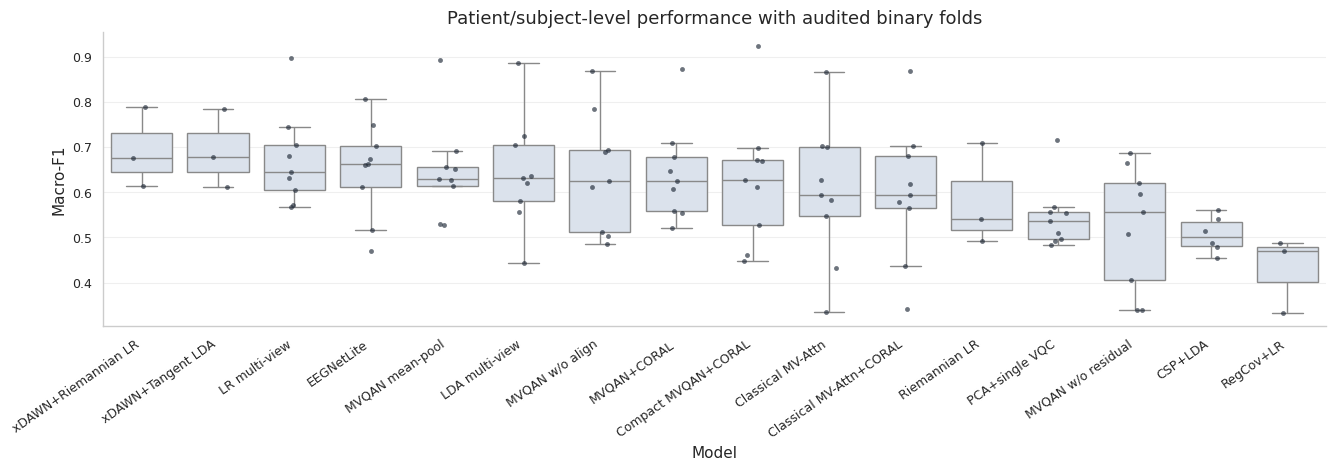

Saved: mvqan_results/fig_main_macro_f1_bar.png and mvqan_results/fig_main_macro_f1_bar.pdf


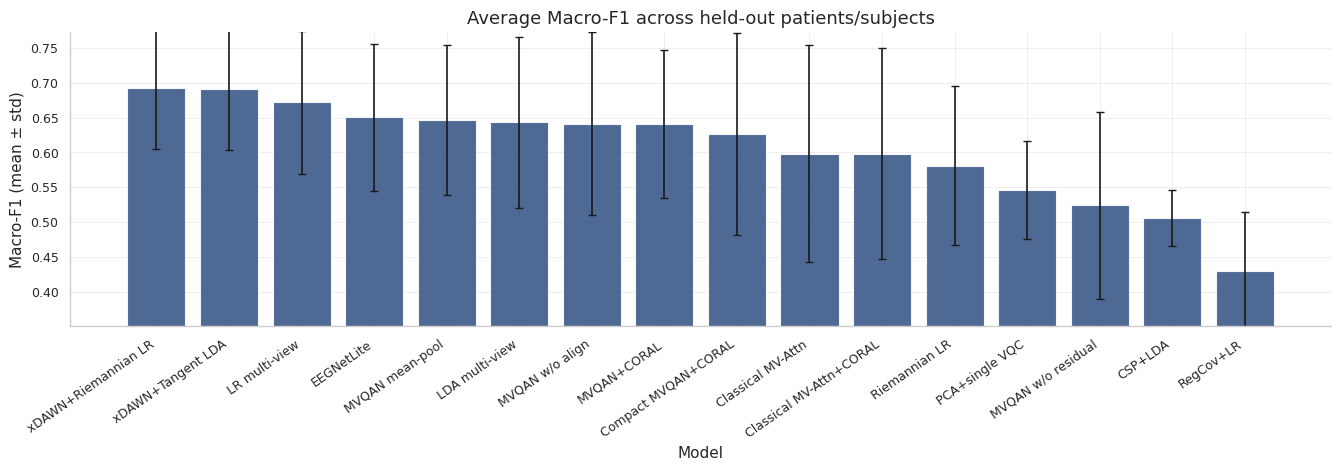

,model,n_folds,macro_f1,balanced_acc,accuracy,roc_auc,pr_auc
11,xDAWN_Riemannian_LR,3,0.693 ± 0.088,0.717 ± 0.100,0.818 ± 0.061,0.833 ± 0.080,0.544 ± 0.172
12,xDAWN_Tangent_LDA,3,0.691 ± 0.087,0.716 ± 0.106,0.819 ± 0.052,0.829 ± 0.080,0.534 ± 0.170
3,EEGNetLite_raw,3,0.680 ± 0.021,0.689 ± 0.040,0.817 ± 0.031,0.811 ± 0.036,0.501 ± 0.044
0,Classical_MVAttention,3,0.677 ± 0.043,0.679 ± 0.060,0.824 ± 0.004,0.792 ± 0.057,0.457 ± 0.081
8,MVQAN_no_alignment,3,0.669 ± 0.038,0.687 ± 0.068,0.808 ± 0.018,0.796 ± 0.046,0.438 ± 0.038
1,Classical_MVAttention_CORAL,3,0.667 ± 0.043,0.682 ± 0.069,0.811 ± 0.025,0.785 ± 0.055,0.433 ± 0.059
6,MVQAN_CORAL,3,0.665 ± 0.052,0.694 ± 0.087,0.800 ± 0.034,0.794 ± 0.050,0.446 ± 0.055
2,Compact_MVQAN_CORAL,3,0.665 ± 0.035,0.696 ± 0.080,0.796 ± 0.048,0.783 ± 0.080,0.452 ± 0.086
7,MVQAN_mean_pool,3,0.657 ± 0.031,0.685 ± 0.064,0.791 ± 0.049,0.792 ± 0.038,0.434 ± 0.047
9,MVQAN_no_alignment_no_residual,3,0.657 ± 0.033,0.687 ± 0.086,0.793 ± 0.026,0.773 ± 0.074,0.404 ± 0.087


Saved: mvqan_results/fig_dataset_wise_loso_macro_f1_boxplots.png and mvqan_results/fig_dataset_wise_loso_macro_f1_boxplots.pdf


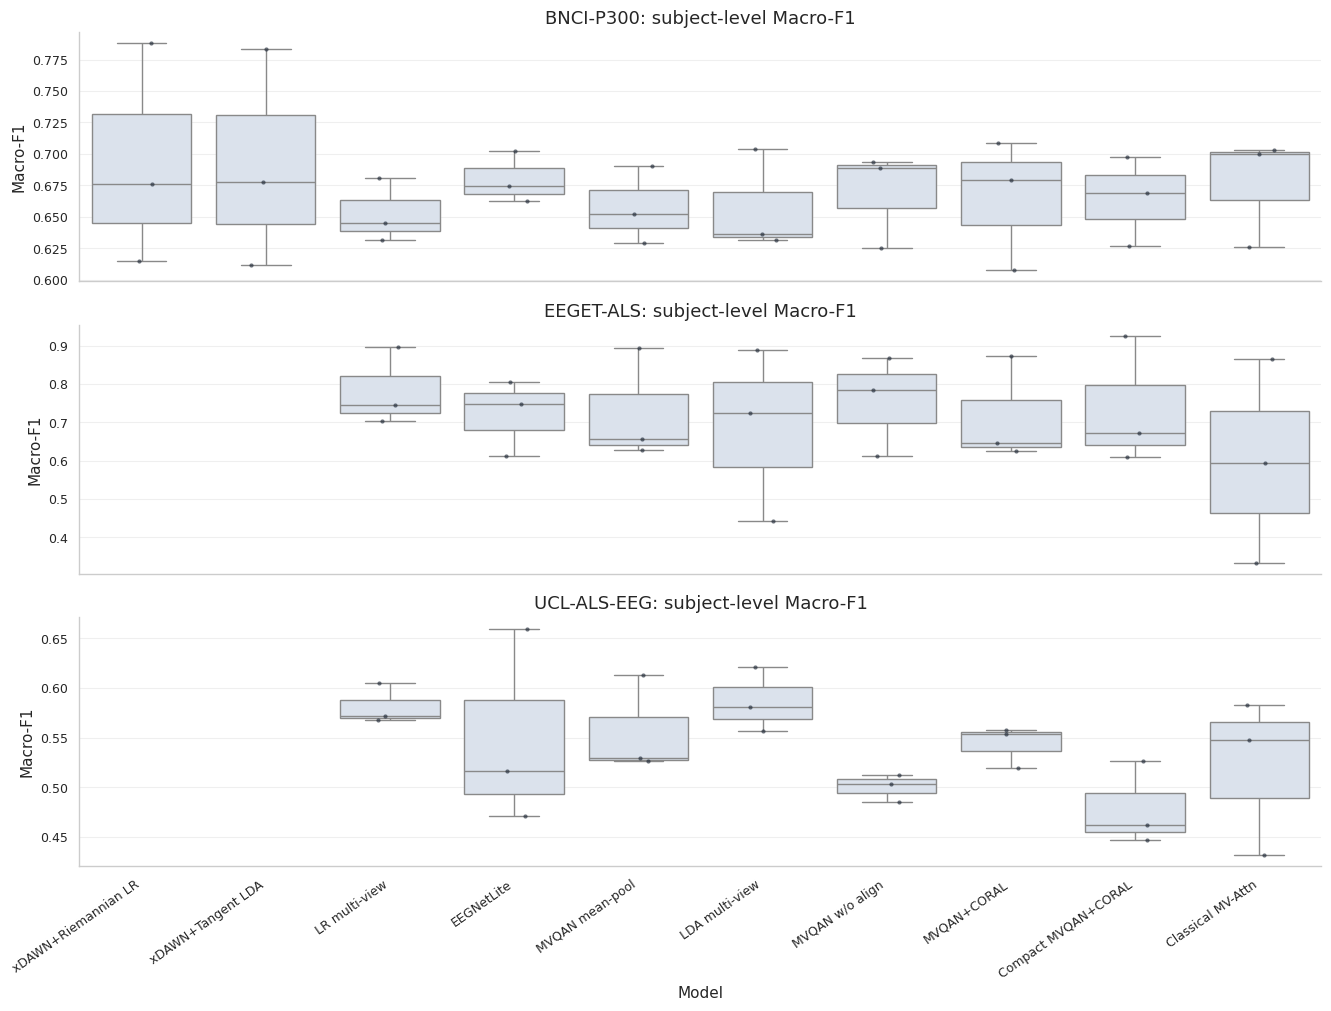

Saved: mvqan_results/fig_parameter_efficiency_macro_f1.png and mvqan_results/fig_parameter_efficiency_macro_f1.pdf


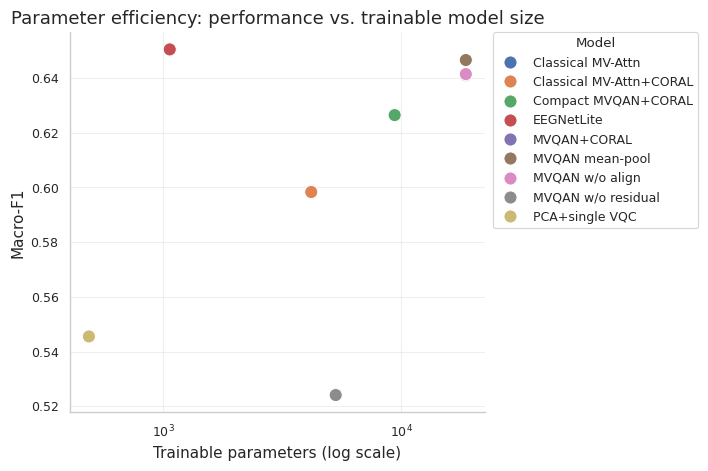

In [ ]:

# ---------------- Paper-quality plotting utilities ----------------
import matplotlib as mpl

MODEL_LABELS = {
    "EEGNetLite_raw": "EEGNetLite",
    "xDAWN_Riemannian_LR": "xDAWN+Riemannian LR",
    "xDAWN_Tangent_LDA": "xDAWN+Tangent LDA",
    "Riemannian_Tangent_LR": "Riemannian LR",
    "CSP_LDA": "CSP+LDA",
    "RegCov_LR": "RegCov+LR",
    "LDA_flat_multiview": "LDA multi-view",
    "LR_flat_multiview": "LR multi-view",
    "Classical_MVAttention": "Classical MV-Attn",
    "Classical_MVAttention_CORAL": "Classical MV-Attn+CORAL",
    "PCA_single_VQC": "PCA+single VQC",
    "Compact_MVQAN_CORAL": "Compact MVQAN+CORAL",
    "MVQAN_no_alignment_no_residual": "MVQAN w/o residual",
    "MVQAN_mean_pool": "MVQAN mean-pool",
    "MVQAN_no_alignment": "MVQAN w/o align",
    "MVQAN_CORAL": "MVQAN+CORAL",
    "MVQAN_MMD": "MVQAN+MMD",
}
METRIC_LABELS = {
    "macro_f1": "Macro-F1",
    "balanced_acc": "Balanced accuracy",
    "accuracy": "Accuracy",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
}

def set_paper_style():
    sns.set_theme(style="whitegrid", context="paper")
    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.titlesize": 13,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

def save_paper_figure(fig, basename):
    png_path = os.path.join(cfg.RESULTS_DIR, basename + ".png")
    pdf_path = os.path.join(cfg.RESULTS_DIR, basename + ".pdf")
    fig.savefig(png_path, dpi=getattr(cfg, "PAPER_DPI", 300), bbox_inches="tight")
    if getattr(cfg, "SAVE_PDF_FIGURES", True):
        fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved:", png_path, "and", pdf_path)

set_paper_style()

if len(results_df) > 0:
    plot_df = results_df.copy()
    plot_df["model_label"] = plot_df["model"].map(MODEL_LABELS).fillna(plot_df["model"])
    order_models = results_df.groupby("model")["macro_f1"].mean().sort_values(ascending=False).index.tolist()
    order_labels = [MODEL_LABELS.get(m, m) for m in order_models]

    # Main boxplot: LOSO macro-F1.
    fig, ax = plt.subplots(figsize=(13.5, 4.8))
    sns.boxplot(data=plot_df, x="model_label", y="macro_f1", order=order_labels, ax=ax, color="#d8e2ef", fliersize=0)
    sns.stripplot(data=plot_df, x="model_label", y="macro_f1", order=order_labels, ax=ax,
                  color="#1f2937", alpha=0.65, size=3.5, jitter=0.12)
    ax.set_xlabel("Model")
    ax.set_ylabel("Macro-F1")
    ax.set_title("Patient/subject-level performance with audited binary folds")
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
    fig.tight_layout()
    save_paper_figure(fig, "fig_main_loso_macro_f1_boxplot")
    plt.show()

    # Compact barplot with confidence variability.
    summary_plot = results_df.groupby("model").agg(
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
        mean_balanced_acc=("balanced_acc", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_pr_auc=("pr_auc", "mean"),
    ).loc[order_models].reset_index()
    summary_plot["model_label"] = summary_plot["model"].map(MODEL_LABELS).fillna(summary_plot["model"])
    fig, ax = plt.subplots(figsize=(13.5, 4.8))
    ax.bar(summary_plot["model_label"], summary_plot["mean_macro_f1"], yerr=summary_plot["std_macro_f1"], capsize=3,
           color="#365486", alpha=0.88)
    ax.set_ylabel("Macro-F1 (mean ± std)")
    ax.set_xlabel("Model")
    ax.set_title("Average Macro-F1 across held-out patients/subjects")
    ax.set_ylim(max(0, summary_plot["mean_macro_f1"].min() - 0.08), min(1.0, summary_plot["mean_macro_f1"].max() + 0.08))
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
    fig.tight_layout()
    save_paper_figure(fig, "fig_main_macro_f1_bar")
    plt.show()

    # Display paper table in notebook.
    if "paper_table" in globals():
        display_cols = ["model", "n_folds", "macro_f1", "balanced_acc", "accuracy", "roc_auc", "pr_auc"]
        display(paper_table[display_cols])
    else:
        rank = results_df.groupby("model")[["macro_f1", "balanced_acc", "accuracy", "roc_auc", "pr_auc"]].mean().sort_values("macro_f1", ascending=False)
        display(rank)


# Dataset-wise boxplots for final Results section.
if len(results_df) > 0 and "dataset" in results_df.columns:
    plot_df = results_df.copy()
    plot_df["model_label"] = plot_df["model"].map(MODEL_LABELS).fillna(plot_df["model"])
    # Use top models by overall macro-F1 to keep the figure readable.
    top_models = results_df.groupby("model")["macro_f1"].mean().sort_values(ascending=False).head(10).index.tolist()
    plot_top = plot_df[plot_df["model"].isin(top_models)].copy()
    order_labels = [MODEL_LABELS.get(m, m) for m in top_models]
    n_ds = plot_top["dataset"].nunique()
    fig, axes = plt.subplots(n_ds, 1, figsize=(13.5, max(4.2, 3.4*n_ds)), sharex=True)
    if n_ds == 1:
        axes = [axes]
    for ax, (ds_name, g) in zip(axes, plot_top.groupby("dataset")):
        sns.boxplot(data=g, x="model_label", y="macro_f1", order=order_labels, ax=ax, color="#d8e2ef", fliersize=0)
        sns.stripplot(data=g, x="model_label", y="macro_f1", order=order_labels, ax=ax, color="#1f2937", alpha=0.65, size=3.0, jitter=0.12)
        ax.set_title(f"{ds_name}: subject-level Macro-F1")
        ax.set_ylabel("Macro-F1")
        ax.set_xlabel("")
    axes[-1].set_xlabel("Model")
    axes[-1].tick_params(axis="x", rotation=35)
    for label in axes[-1].get_xticklabels():
        label.set_horizontalalignment("right")
    fig.tight_layout()
    save_paper_figure(fig, "fig_dataset_wise_loso_macro_f1_boxplots")
    plt.show()


# Parameter-efficiency plot: reviewer-facing answer to advisor's question about fewer parameters and overfitting.
if len(results_df) > 0 and "trainable_params" in results_df.columns:
    eff_df = results_df.dropna(subset=["trainable_params"]).copy()
    if len(eff_df) > 0:
        eff_summary = eff_df.groupby("model").agg(
            macro_f1=("macro_f1", "mean"),
            params=("trainable_params", "mean"),
            overfit_gap=("overfit_gap_macro_f1", "mean") if "overfit_gap_macro_f1" in eff_df.columns else ("macro_f1", "mean"),
        ).reset_index()
        eff_summary["model_label"] = eff_summary["model"].map(MODEL_LABELS).fillna(eff_summary["model"])
        fig, ax = plt.subplots(figsize=(7.2, 4.8))
        sns.scatterplot(data=eff_summary, x="params", y="macro_f1", hue="model_label", s=90, ax=ax)
        ax.set_xscale("log")
        ax.set_xlabel("Trainable parameters (log scale)")
        ax.set_ylabel("Macro-F1")
        ax.set_title("Parameter efficiency: performance vs. trainable model size")
        ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
        fig.tight_layout()
        save_paper_figure(fig, "fig_parameter_efficiency_macro_f1")
        plt.show()


# 18. Visualize MVQAN attention weights

Attention visualization helps explain which structured views the model uses. This is central for the proposal because MVQAN claims to fuse temporal/spatial/frequency/covariance quantum features.

Selected artifact for attention visualization:
   EEGET-ALS | 42 | 2 | MVQAN_CORAL
Saved: mvqan_results/fig_attention_weights_test.png and mvqan_results/fig_attention_weights_test.pdf


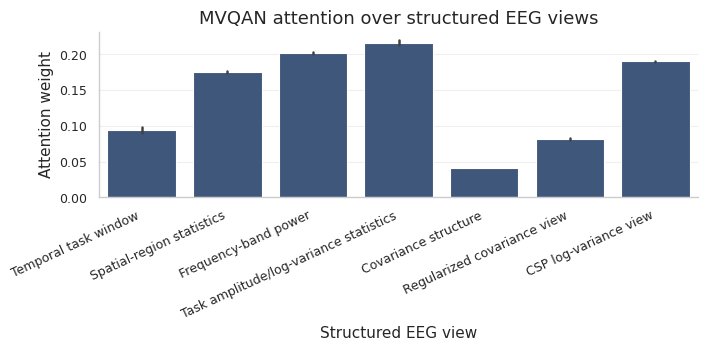

,Temporal task window,Spatial-region statistics,Frequency-band power,Task amplitude/log-variance statistics,Covariance structure,Regularized covariance view,CSP log-variance view
count,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,0.094351,0.175317,0.201688,0.216366,0.040837,0.080998,0.190443
std,0.074522,0.013738,0.028005,0.064790,0.002271,0.025427,0.010709
min,0.044366,0.063459,0.053857,0.075193,0.033101,0.041873,0.153980
25%,0.045556,0.173765,0.205422,0.180403,0.040818,0.077768,0.190202
50%,0.045904,0.175040,0.211198,0.253146,0.041505,0.077935,0.193681
75%,0.189402,0.177794,0.212382,0.254832,0.041658,0.078222,0.194397
max,0.261684,0.221418,0.218252,0.287103,0.048817,0.176011,0.227132


Saved attention descriptive statistics to: mvqan_results/attention_weights_test_descriptive_stats.csv


,Temporal task window,Spatial-region statistics,Frequency-band power,Task amplitude/log-variance statistics,Covariance structure,Regularized covariance view,CSP log-variance view
Class,,,,,,,
0,0.083315,0.176569,0.203826,0.223054,0.041169,0.080042,0.192025
1,0.105387,0.174066,0.199550,0.209679,0.040504,0.081953,0.188862


Saved: mvqan_results/fig_attention_by_class.png and mvqan_results/fig_attention_by_class.pdf


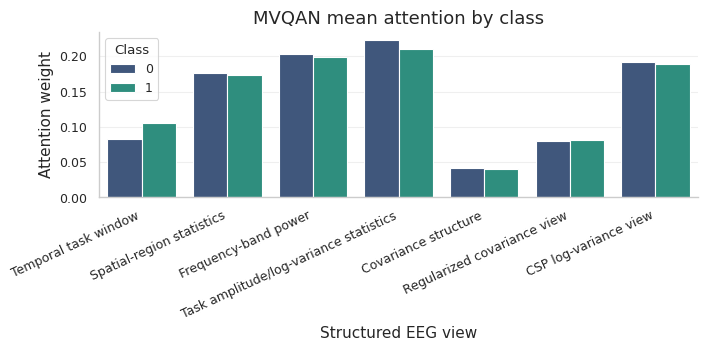

Saved class-wise attention summary to: mvqan_results/attention_by_class.csv


In [ ]:
# ======================================================================================
# MVQAN attention-weight visualization
# Robust replacement cell.
#
# Fixes:
#   1. Does not assume key[2] is the model name.
#   2. Works with artifact keys like:
#        (dataset, seed, model)
#        (dataset, seed, fold, model)
#        (dataset, fold, seed, model)
#   3. Converts GPU tensors to CPU numpy before plotting.
#   4. Handles missing attention or label fields safely.
# ======================================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# --------------------------------------------------------------------------------------
# Helper functions
# --------------------------------------------------------------------------------------

def _key_parts(key):
    """Return artifact key as a list of safe parts."""
    if isinstance(key, tuple):
        return list(key)
    if isinstance(key, list):
        return key
    return [key]


def _key_text(key):
    """Convert artifact key to readable string."""
    return " | ".join(str(x) for x in _key_parts(key))


def _key_has_exact_model(key, model_name):
    """Check whether any string part of the artifact key exactly matches a model name."""
    for part in _key_parts(key):
        if isinstance(part, str) and part == model_name:
            return True
    return False


def _key_contains_mvqan(key):
    """Check whether any string part of the artifact key contains MVQAN."""
    for part in _key_parts(key):
        if isinstance(part, str) and "MVQAN" in part:
            return True
    return False


def _to_numpy(x):
    """Safely convert torch tensors / lists / numpy arrays / pandas objects to CPU numpy arrays."""
    if x is None:
        return None

    try:
        import torch
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
    except Exception:
        pass

    if isinstance(x, pd.DataFrame):
        return x.values

    if isinstance(x, pd.Series):
        return x.values

    return np.asarray(x)


def _extract_attention_from_artifact(art):
    """
    Extract attention, labels, and view names from an artifact dictionary.
    Supports multiple possible field names from different notebook versions.
    """
    if not isinstance(art, dict):
        return None, None, None

    out = art.get("test_out", art.get("out", {}))
    if out is None:
        out = {}

    # Attention may be stored inside out or directly inside art.
    att = None
    attention_field_names = [
        "attention",
        "attention_weights",
        "attention_weights_test",
        "attn",
        "attn_weights",
        "alpha",
        "alpha_test",
    ]

    for name in attention_field_names:
        if isinstance(out, dict) and name in out and out[name] is not None:
            att = out[name]
            break
        if name in art and art[name] is not None:
            att = art[name]
            break

    # Labels may be stored inside out or directly inside art.
    yy = None
    label_field_names = [
        "y",
        "y_test",
        "test_y",
        "labels",
        "labels_test",
    ]

    for name in label_field_names:
        if isinstance(out, dict) and name in out and out[name] is not None:
            yy = out[name]
            break
        if name in art and art[name] is not None:
            yy = art[name]
            break

    # View names may be stored directly inside art.
    view_names = None
    view_field_names = [
        "view_names",
        "views",
        "selected_view_names",
        "feature_view_names",
    ]

    for name in view_field_names:
        if name in art and art[name] is not None:
            view_names = art[name]
            break

    return att, yy, view_names


def _artifact_has_attention(key):
    """Check whether an artifact contains a usable attention object."""
    try:
        art = artifacts[key]
        att, _, _ = _extract_attention_from_artifact(art)
        return att is not None
    except Exception:
        return False


# --------------------------------------------------------------------------------------
# Choose the best available artifact from the main proposed model first
# --------------------------------------------------------------------------------------

if "artifacts" not in globals() or not isinstance(artifacts, dict) or len(artifacts) == 0:
    raise RuntimeError("No artifacts dictionary found. Please run the main experiment cell first.")

main_name = getattr(cfg, "MAIN_MODEL_NAME", "MVQAN_CORAL")

preferred = [
    main_name,
    "MVQAN_CORAL",
    "Compact_MVQAN_CORAL",
    "MVQAN_MMD",
    "MVQAN_no_alignment",
    "MVQAN_mean_pool",
    "MVQAN_no_alignment_no_residual",
]

chosen_key = None

# First: choose the preferred MVQAN model that actually contains attention.
for name in preferred:
    matches = [
        key for key in artifacts.keys()
        if _key_has_exact_model(key, name) and _artifact_has_attention(key)
    ]
    if matches:
        chosen_key = matches[-1]
        break

# Second: choose any MVQAN artifact that contains attention.
if chosen_key is None:
    matches = [
        key for key in artifacts.keys()
        if _key_contains_mvqan(key) and _artifact_has_attention(key)
    ]
    if matches:
        chosen_key = matches[-1]

# Third: choose any MVQAN artifact, even if attention may be missing.
# This allows us to print the available fields for debugging.
if chosen_key is None:
    matches = [
        key for key in artifacts.keys()
        if _key_contains_mvqan(key)
    ]
    if matches:
        chosen_key = matches[-1]


VIEW_LABELS = {
    "temporal_erp": "Temporal ERP window",
    "temporal_task": "Temporal task window",
    "spatial_region": "Spatial-region statistics",
    "frequency_band": "Frequency-band power",
    "erp_stat": "ERP/task amplitude statistics",
    "logvar_stat": "Task amplitude/log-variance statistics",
    "covariance": "Covariance structure",
    "xdawn_tangent": "xDAWN tangent view",
    "riemannian_tangent": "Riemannian tangent view",
    "reg_covariance_tangent": "Regularized covariance view",
    "csp_logvar": "CSP log-variance view",
    "supervised_geometry": "Supervised EEG geometry",
}


# --------------------------------------------------------------------------------------
# Plot attention weights
# --------------------------------------------------------------------------------------

if chosen_key is not None:
    print("Selected artifact for attention visualization:")
    print("  ", _key_text(chosen_key))

    art = artifacts[chosen_key]
    att, yy, view_names = _extract_attention_from_artifact(art)

    if att is None:
        print("No attention matrix saved for chosen model.")
        print("Chosen artifact key:", _key_text(chosen_key))
        print("Available artifact fields:")

        if isinstance(art, dict):
            for k in art.keys():
                print("  ", k)

        raise RuntimeError(
            "Attention matrix was not found. Make sure the MVQAN evaluation code saves "
            "out['attention'] or art['attention_weights_test']."
        )

    att = _to_numpy(att).astype(float)

    # Handle possible attention shapes:
    #   [n_samples, n_views]
    #   [n_views]
    #   [folds, n_samples, n_views]
    if att.ndim == 1:
        att = att.reshape(1, -1)
    elif att.ndim == 3:
        att = att.reshape(-1, att.shape[-1])
    elif att.ndim > 3:
        att = att.reshape(-1, att.shape[-1])

    # Clean NaN / Inf values.
    att = np.nan_to_num(att, nan=0.0, posinf=0.0, neginf=0.0)

    # Normalize each sample's attention weights if not already normalized.
    row_sums = att.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0.0] = 1.0
    att = att / row_sums

    n_views = att.shape[1]

    if view_names is None:
        view_names = [f"view_{i+1}" for i in range(n_views)]
    else:
        view_names = list(view_names)

    if len(view_names) != n_views:
        print(
            f"Warning: len(view_names)={len(view_names)} but attention has {n_views} views. "
            "Using generic view names."
        )
        view_names = [f"view_{i+1}" for i in range(n_views)]

    view_labels = [VIEW_LABELS.get(v, v) for v in view_names]

    att_df = pd.DataFrame(att, columns=view_labels)
    long_att = att_df.melt(var_name="View", value_name="Attention weight")

    # Overall attention plot.
    fig, ax = plt.subplots(figsize=(7.2, 3.6))
    sns.barplot(
        data=long_att,
        x="View",
        y="Attention weight",
        ax=ax,
        color="#365486",
        errorbar="se",
    )
    ax.set_title("MVQAN attention over structured EEG views")
    ax.set_xlabel("Structured EEG view")
    ax.set_ylabel("Attention weight")
    ax.tick_params(axis="x", rotation=25)

    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

    fig.tight_layout()
    save_paper_figure(fig, "fig_attention_weights_test")
    plt.show()

    # Save descriptive statistics.
    att_stats_path = os.path.join(
        cfg.RESULTS_DIR,
        "attention_weights_test_descriptive_stats.csv",
    )
    att_df.describe().to_csv(att_stats_path)
    display(att_df.describe())

    print(f"Saved attention descriptive statistics to: {att_stats_path}")

    # ----------------------------------------------------------------------------------
    # Class-wise attention patterns
    # ----------------------------------------------------------------------------------

    if yy is not None:
        yy = _to_numpy(yy).reshape(-1)

        if len(yy) == len(att_df) and len(np.unique(yy)) >= 2:
            att_class_df = att_df.copy()
            att_class_df["Class"] = yy.astype(int)

            class_summary = att_class_df.groupby("Class")[view_labels].mean()
            class_summary_path = os.path.join(cfg.RESULTS_DIR, "attention_by_class.csv")
            class_summary.to_csv(class_summary_path)

            display(class_summary)

            class_plot = class_summary.T.reset_index().rename(columns={"index": "View"})
            class_plot_long = class_plot.melt(
                id_vars="View",
                var_name="Class",
                value_name="Attention weight",
            )

            fig, ax = plt.subplots(figsize=(7.2, 3.6))
            sns.barplot(
                data=class_plot_long,
                x="View",
                y="Attention weight",
                hue="Class",
                ax=ax,
                palette=["#365486", "#1f9e89"],
            )
            ax.set_title("MVQAN mean attention by class")
            ax.set_xlabel("Structured EEG view")
            ax.set_ylabel("Attention weight")
            ax.tick_params(axis="x", rotation=25)

            for label in ax.get_xticklabels():
                label.set_horizontalalignment("right")

            ax.legend(title="Class")
            fig.tight_layout()
            save_paper_figure(fig, "fig_attention_by_class")
            plt.show()

            print(f"Saved class-wise attention summary to: {class_summary_path}")

        else:
            print(
                "Class-wise attention plot skipped because labels are missing, "
                "only one class is present, or label length does not match attention rows."
            )
            print(f"  attention rows = {len(att_df)}")
            print(f"  label length = {len(yy)}")
            print(f"  unique labels = {np.unique(yy) if len(yy) > 0 else []}")

    else:
        print("Class-wise attention plot skipped because y labels were not found in artifact.")

else:
    print("No MVQAN artifact available for attention visualization.")
    print("Available artifact keys:")
    for key in artifacts.keys():
        print("  ", _key_text(key))

# 19. UMAP/t-SNE feature visualization

This shows whether the learned representation separates classes and/or patients. For the paper, show both class-colored and patient-colored plots before/after alignment when possible.

Saved: mvqan_results/fig_umap_train_source_2.png and mvqan_results/fig_umap_train_source_2.pdf


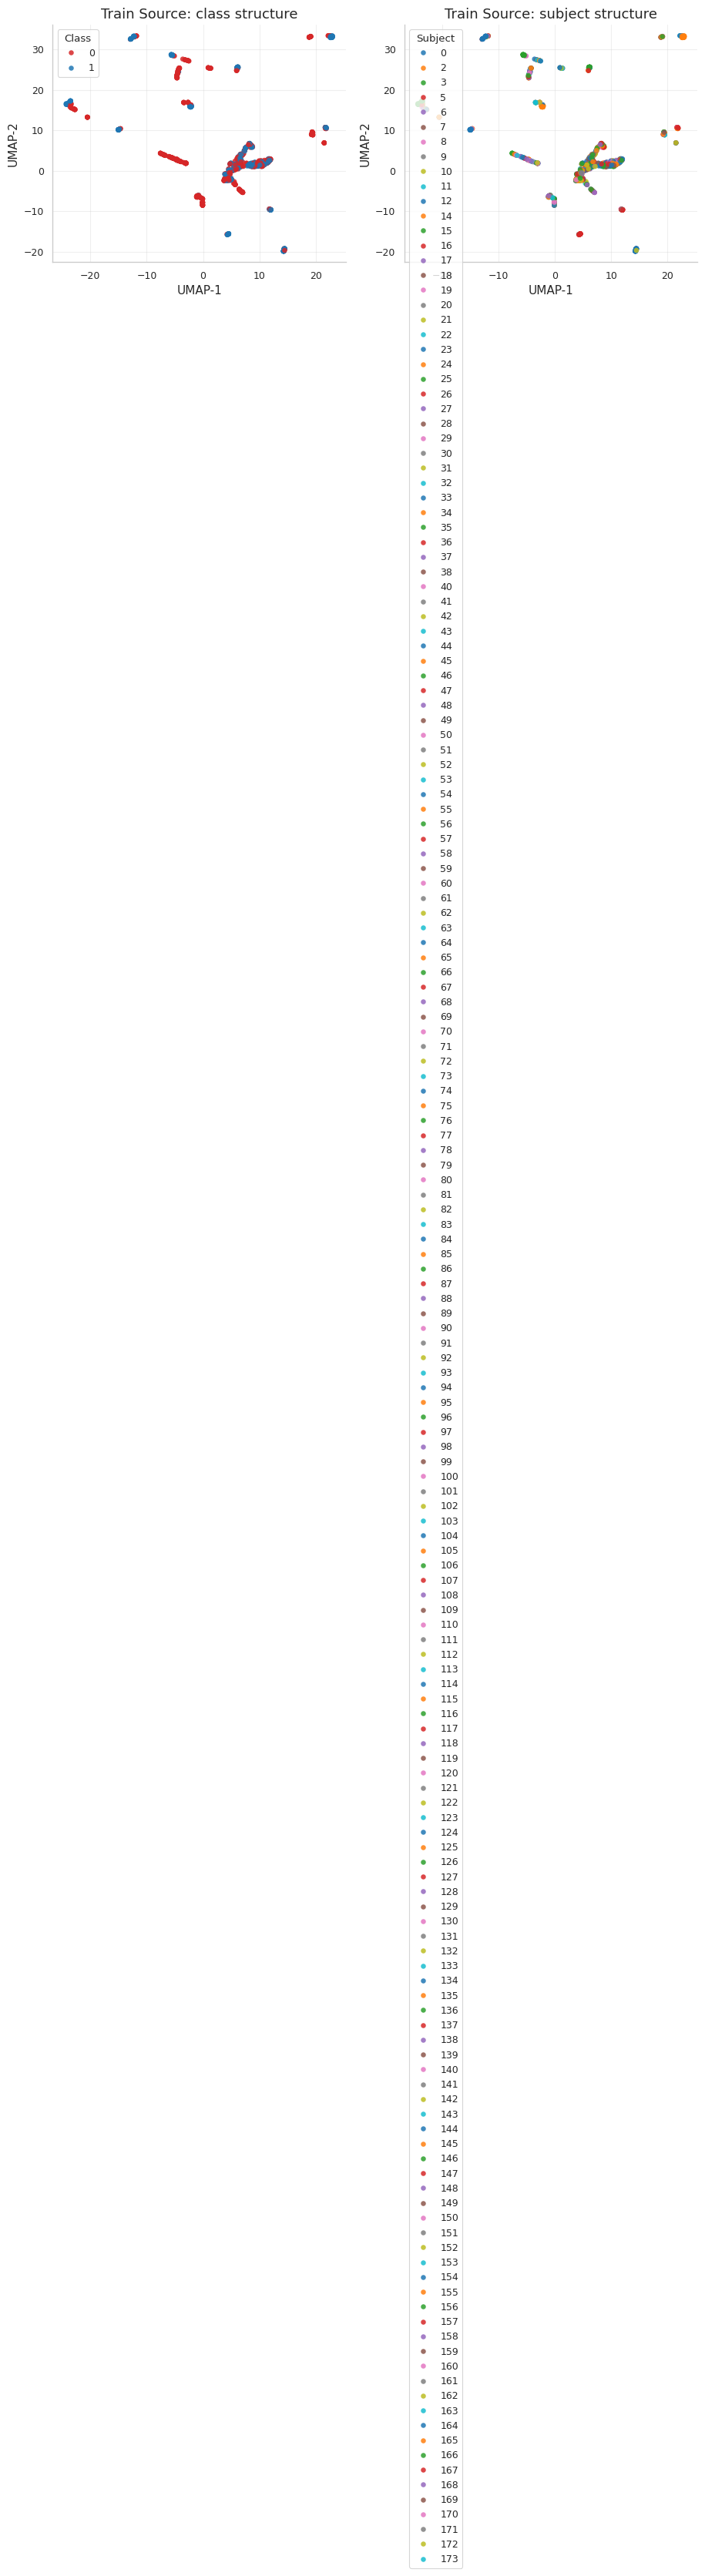

Saved: mvqan_results/fig_umap_test_heldout_2.png and mvqan_results/fig_umap_test_heldout_2.pdf


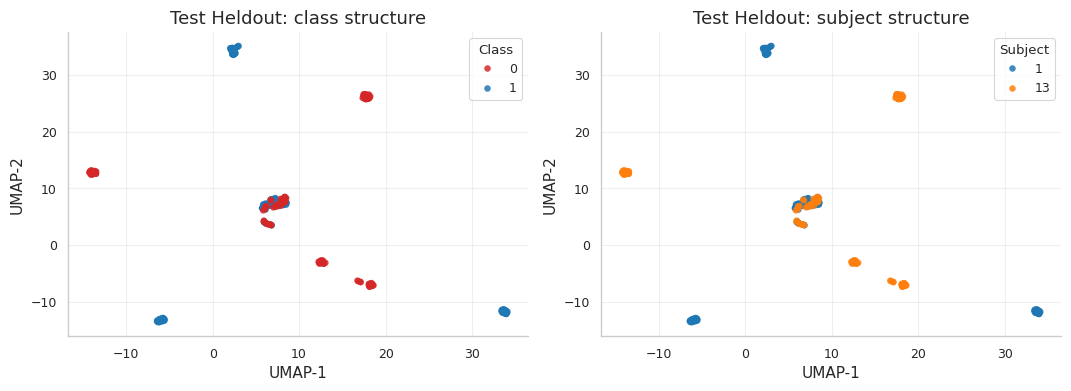

In [ ]:

try:
    import umap
    if chosen_key is not None:
        art = artifacts[chosen_key]
        train_out = art.get("train_out", None)
        test_out = art.get("test_out", art.get("out", None))

        for split_name, out in [("train_source", train_out), ("test_heldout", test_out)]:
            if out is None:
                continue
            Z = out["embeddings"]
            yy = out["y"].astype(int)
            ss = out["subjects"]
            if len(Z) < 5:
                continue
            # Standardize embeddings for visualization only.
            Z_vis = StandardScaler().fit_transform(Z)
            reducer = umap.UMAP(n_neighbors=min(20, max(2, len(Z_vis)//4)), min_dist=0.15, random_state=cfg.SEED)
            Z2 = reducer.fit_transform(Z_vis)
            umap_df = pd.DataFrame({"UMAP-1": Z2[:,0], "UMAP-2": Z2[:,1], "Class": yy, "Subject": ss})
            umap_df.to_csv(os.path.join(cfg.RESULTS_DIR, f"umap_coordinates_{split_name}_{chosen_key[2]}.csv"), index=False)

            fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.0))
            sns.scatterplot(data=umap_df, x="UMAP-1", y="UMAP-2", hue="Class", ax=axes[0], palette=["#d62728", "#1f77b4"], s=22, linewidth=0, alpha=0.85)
            axes[0].set_title(f"{split_name.replace('_', ' ').title()}: class structure")
            axes[0].legend(title="Class", frameon=True)
            sns.scatterplot(data=umap_df, x="UMAP-1", y="UMAP-2", hue="Subject", ax=axes[1], palette="tab10", s=22, linewidth=0, alpha=0.85)
            axes[1].set_title(f"{split_name.replace('_', ' ').title()}: subject structure")
            axes[1].legend(title="Subject", frameon=True, ncol=1)
            for ax in axes:
                ax.set_xlabel("UMAP-1")
                ax.set_ylabel("UMAP-2")
            fig.tight_layout()
            save_paper_figure(fig, f"fig_umap_{split_name}_{chosen_key[2]}")
            plt.show()
except Exception as e:
    print("UMAP visualization failed:", repr(e))


# 20. Class-conditional discrepancy matrix for a fitted representation

This computes a simple class-conditional CORAL discrepancy matrix across subjects for any representation. For final paper, compute this on training/validation/source representations before and after alignment.

,model,class,mean_offdiag_coral
0,MVQAN_no_alignment,0,2.126536
1,MVQAN_no_alignment,1,1.626603
2,MVQAN_CORAL,0,2.508928
3,MVQAN_CORAL,1,0.232915


Saved: mvqan_results/fig_coral_matrix_class_0.png and mvqan_results/fig_coral_matrix_class_0.pdf


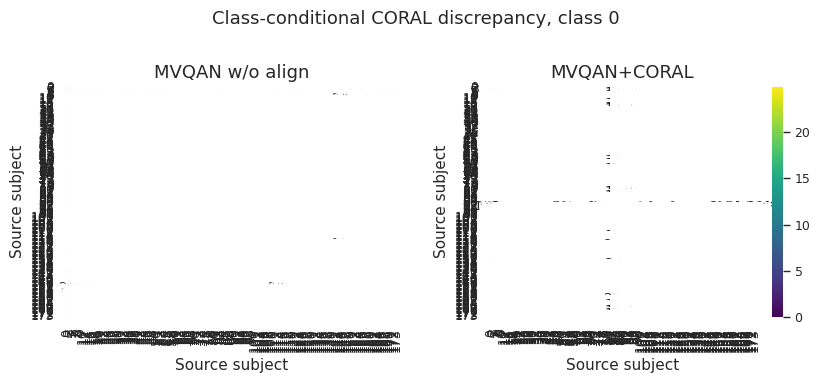

Saved: mvqan_results/fig_coral_matrix_class_1.png and mvqan_results/fig_coral_matrix_class_1.pdf


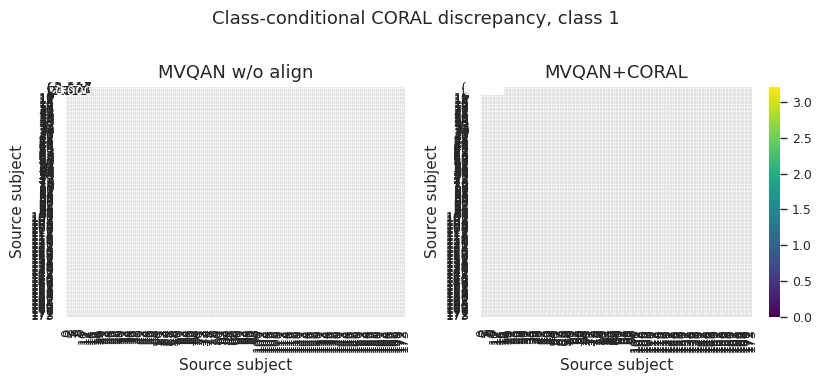

Saved: mvqan_results/fig_alignment_coral_offdiag_summary.png and mvqan_results/fig_alignment_coral_offdiag_summary.pdf


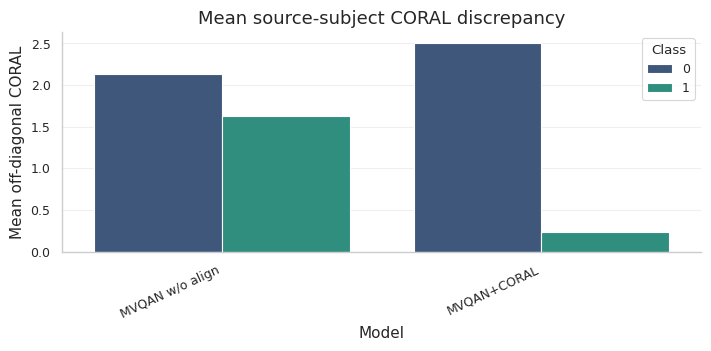

In [ ]:
def coral_discrepancy_numpy(A, B):
    if len(A) < 2 or len(B) < 2:
        return np.nan
    muA, muB = A.mean(axis=0), B.mean(axis=0)
    covA, covB = np.cov(A, rowvar=False), np.cov(B, rowvar=False)
    return float(np.mean((muA-muB)**2) + np.mean((covA-covB)**2))

def compute_coral_matrices_from_artifact(art, split_name="train_source", normalize=True):
    out = art.get("train_out" if split_name == "train_source" else "test_out", None)
    if out is None:
        return {}
    Z = out["embeddings"].astype(np.float64)
    yy = out["y"].astype(int)
    ss = out["subjects"]
    if normalize:
        Z = StandardScaler().fit_transform(Z)
    unique_s = np.unique(ss)
    if len(unique_s) < 2:
        return {}
    matrices = {}
    for cls in np.unique(yy):
        mat = np.zeros((len(unique_s), len(unique_s)), dtype=float)
        for i, s1 in enumerate(unique_s):
            for j, s2 in enumerate(unique_s):
                mat[i,j] = coral_discrepancy_numpy(Z[(ss==s1)&(yy==cls)], Z[(ss==s2)&(yy==cls)])
        matrices[int(cls)] = (mat, unique_s)
    return matrices

def offdiag_mean(mat):
    if mat.shape[0] <= 1:
        return np.nan
    mask = ~np.eye(mat.shape[0], dtype=bool)
    return float(np.nanmean(mat[mask]))

# Plot source-subject matrices for no-alignment vs CORAL/MMD on the same fold using a shared color scale.
if chosen_key is not None:

    # FIX: Handle artifact keys that include the dataset name (length 4) vs old keys (length 3)
    if len(chosen_key) == 4:
        ds_name, seed, fold_id, _ = chosen_key
        keys_same_fold = {k[3]: k for k in artifacts.keys() if len(k) == 4 and k[0] == ds_name and k[1] == seed and k[2] == fold_id}
    else:
        seed, fold_id, _ = chosen_key
        keys_same_fold = {k[2]: k for k in artifacts.keys() if len(k) == 3 and k[0] == seed and k[1] == fold_id}

    model_order = [m for m in ["MVQAN_no_alignment", "MVQAN_CORAL", "MVQAN_MMD"] if m in keys_same_fold]
    matrix_store = {}
    summary_rows = []

    for model_label in model_order:
        mats = compute_coral_matrices_from_artifact(artifacts[keys_same_fold[model_label]], split_name="train_source", normalize=True)
        matrix_store[model_label] = mats
        for cls, (mat, unique_s) in mats.items():
            summary_rows.append({"model": model_label, "class": cls, "mean_offdiag_coral": offdiag_mean(mat)})

    if summary_rows:
        align_summary = pd.DataFrame(summary_rows)
        align_summary.to_csv(os.path.join(cfg.RESULTS_DIR, "alignment_coral_offdiag_summary.csv"), index=False)
        display(align_summary)

        # Heatmaps: one PDF/PNG per class, with rows as models for easier comparison.
        all_classes = sorted(set(cls for mats in matrix_store.values() for cls in mats.keys()))
        for cls in all_classes:
            vmax = 0.0
            for model_label in model_order:
                if cls in matrix_store.get(model_label, {}):
                    vmax = max(vmax, np.nanmax(matrix_store[model_label][cls][0]))
            vmax = max(vmax, 1e-6)
            ncols = len(model_order)
            fig, axes = plt.subplots(1, ncols, figsize=(4.2*ncols, 3.7), squeeze=False)
            for ax, model_label in zip(axes[0], model_order):
                if cls not in matrix_store.get(model_label, {}):
                    ax.axis("off")
                    continue
                mat, unique_s = matrix_store[model_label][cls]
                sns.heatmap(mat, annot=True, fmt=".3f", xticklabels=unique_s, yticklabels=unique_s,
                            cmap="viridis", vmin=0, vmax=vmax, ax=ax, cbar=(model_label == model_order[-1]))
                ax.set_title(MODEL_LABELS.get(model_label, model_label))
                ax.set_xlabel("Source subject")
                ax.set_ylabel("Source subject")
            fig.suptitle(f"Class-conditional CORAL discrepancy, class {cls}", y=1.02)
            fig.tight_layout()
            save_paper_figure(fig, f"fig_coral_matrix_class_{cls}")
            plt.show()

        # Alignment summary barplot.
        align_plot = align_summary.copy()
        align_plot["model_label"] = align_plot["model"].map(MODEL_LABELS).fillna(align_plot["model"])
        fig, ax = plt.subplots(figsize=(7.2, 3.6))
        sns.barplot(data=align_plot, x="model_label", y="mean_offdiag_coral", hue="class", ax=ax, palette=["#365486", "#1f9e89"])
        ax.set_title("Mean source-subject CORAL discrepancy")
        ax.set_xlabel("Model")
        ax.set_ylabel("Mean off-diagonal CORAL")
        ax.tick_params(axis="x", rotation=25)
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")
        ax.legend(title="Class")
        fig.tight_layout()
        save_paper_figure(fig, "fig_alignment_coral_offdiag_summary")
        plt.show()
    else:
        print("No multi-subject source embeddings available for CORAL matrices.")

# 21. Final paper-run checklist

This notebook is now configured for the exact three advisor-prioritized datasets:

1. BNCI-P300 through MOABB.
2. UCL ALS-EEG through the UCL/Figshare download URL.
3. EEGET-ALS through Kaggle slug `patrickiitmz/eeget-als-dataset`.

Run order:

1. Start with `RUN_MODE = "quick"` in the global config cell to verify that all three datasets download and parse.
2. Then use `RUN_MODE = "tune"` to tune only source-validation-supported hyperparameters.
3. Use `RUN_MODE = "paper"` for final full LOSO tables and paper-quality PDF figures.

Kaggle note:

- The notebook first tries `kagglehub.dataset_download`, which may work directly for public datasets.
- If KaggleHub fails, upload your Kaggle API file to Colab:

```python
from google.colab import files
files.upload()  # upload kaggle.json
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
```

Recommended final settings after checking loaders:

```python
RUN_MODE = "paper"
LOSS_TYPE = "focal"
TARGET_CLASS_WEIGHT_MULTIPLIER = 1.25
USE_BALANCED_SAMPLER = True
TUNE_THRESHOLD = True
N_QUBITS_PAPER = 6
VQC_DEPTH_PAPER = 2
QUANTUM_ENCODING = "RY_RZ"
USE_CLASSICAL_RESIDUAL = True
ALIGN_LAMBDA = 0.005  # tune among 0.001, 0.005, 0.01, 0.02
CLASS_SEPARATION_LAMBDA = 0.015
```

Paper claim discipline:

- Use the exact dataset names only after the loader prints that all three exact sources were loaded.
- The default UCL task is left-vs-right MI, excluding rest, to maintain a consistent binary evaluation protocol across BNCI-P300, UCL ALS-EEG, and EEGET-ALS.
- If you later include UCL rest as a third class, update model outputs and metric functions to multiclass.

All results are saved in `cfg.RESULTS_DIR`, including CSV tables, LaTeX tables, parameter-efficiency summaries, overfitting-gap summaries, and PDF/PNG figures.


In [ ]:
import shutil
from google.colab import files
shutil.make_archive('/content/mvqan_results', 'zip', '/content/mvqan_results')
files.download('/content/mvqan_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>